<a href="https://colab.research.google.com/github/somar9/Neutrino-Oscillation-Project/blob/Vivien_Yuewen_Gao-MuonOscillations/4_Flavour_oscillation(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Clone github repository for neutrino oscilation probability
!git clone https://github.com/mbustama/NuOscProbExact.git
%cd NuOscProbExact/src
%ls


Cloning into 'NuOscProbExact'...
remote: Enumerating objects: 741, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 741 (delta 110), reused 83 (delta 44), pack-reused 586 (from 1)
Receiving objects: 100% (741/741), 808.67 KiB | 8.70 MiB/s, done.
Resolving deltas: 100% (388/388), done.
/content/NuOscProbExact/src
globaldefs.py       hamiltonians3nu.py  oscprob3nu.py
hamiltonians2nu.py  oscprob2nu.py


In [2]:
from scipy.linalg import expm
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams.update({
    "figure.figsize":   (10, 6),
    "font.size":        16,
    "axes.titlesize":   22,
    "axes.labelsize":   18,
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
    "legend.fontsize":  16,
    "grid.linewidth":   0.8
})

In [3]:
# Constants
CONV_KM_TO_INV_EV = 5.067731e9      # km to eV⁻¹
VCC_EARTH_CRUST = 7.6e-14           # Matter potential (eV)


def mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14):
    c12, c13, c23, c14, c24, c34 = np.cos([theta12, theta13, theta23, theta14, theta24, theta34])
    s12, s13, s23, s14, s24, s34 = np.sin([theta12, theta13, theta23, theta14, theta24, theta34])
    U = np.array([
        [c12 * c13 * c14, s12 * c13 * c14, s13 * c14 * np.exp(-1j * delta13), s14 * np.exp(-1j * delta14)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23,
         s24 * c13],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23,
         c24 * s34],
        [0, 0, 0, c34]
    ])
    return U

def hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E):
    m2_diag = np.diag([0, D21, D31, D41])
    U = mixing_matrix_4nu(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14)
    return U @ m2_diag @ np.conj(U.T) / (2 * E)

def hamiltonian_4nu_matter(H_vacuum, E, VCC):
    return H_vacuum + np.diag([VCC, 0, 0, 0])


def probabilities_4nu_vacuum(H_vacuum, baseline):
    S = expm(-1j * H_vacuum * baseline)
    return np.abs(S[1, 1])**2, np.abs(S[1, 0])**2, np.abs(S[1, 2])**2, np.abs(S[1, 3])**2

def probabilities_4nu_matter(H_matter, baseline):
    S = expm(-1j * H_matter * baseline)
    return np.abs(S[1, 1])**2, np.abs(S[1, 0])**2, np.abs(S[1, 2])**2, np.abs(S[1, 3])**2

def compute_probabilities(baseline, energy_values, matter=False):
    Prob_mm, Prob_me, Prob_mt, Prob_ms = [], [], [], []
    for E in energy_values:
        H_vacuum = hamiltonian_4nu_vacuum(theta12, theta13, theta23, theta14, theta24, theta34, delta13, delta14, D21, D31, D41, E)
        if matter:
            H = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
            Pmm, Pme, Pmt, Pms = probabilities_4nu_matter(H, baseline * CONV_KM_TO_INV_EV)
        else:
            Pmm, Pme, Pmt, Pms = probabilities_4nu_vacuum(H_vacuum, baseline * CONV_KM_TO_INV_EV)
        Prob_mm.append(Pmm)
        Prob_me.append(Pme)
        Prob_mt.append(Pmt)
        Prob_ms.append(Pms)
    return np.array(Prob_mm), np.array(Prob_me), np.array(Prob_mt), np.array(Prob_ms)


bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5]) * 1e9
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5]) * 1e9
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

popt_nd, _ = curve_fit(gaussian, bin_centers, counts_nd, p0=[np.max(counts_nd), 2.5e9, 0.5e9])

Length_near = 1
Length_far = 810

theta12, theta13, theta23 = np.radians([33.82, 8.61, 48.3])
theta14, theta24, theta34 = np.radians([10.0, 5.0, 2.0])
delta13, delta14 = np.radians([0, 0])
D21, D31, D41 = [7.39e-5, 2.525e-3, 1.0]

# Compute probabilities
prob_mm_far_vac, *_ = compute_probabilities(Length_far, bin_centers, matter=False)
prob_mm_far_matter, *_ = compute_probabilities(Length_far, bin_centers, matter=True)

# Apply survival probability to fitted spectrum
oscillated_fd_vac = gaussian(bin_centers, *popt_nd) * prob_mm_far_vac / np.max(prob_mm_far_vac)
oscillated_fd_matter = gaussian(bin_centers, *popt_nd) * prob_mm_far_matter / np.max(prob_mm_far_matter)

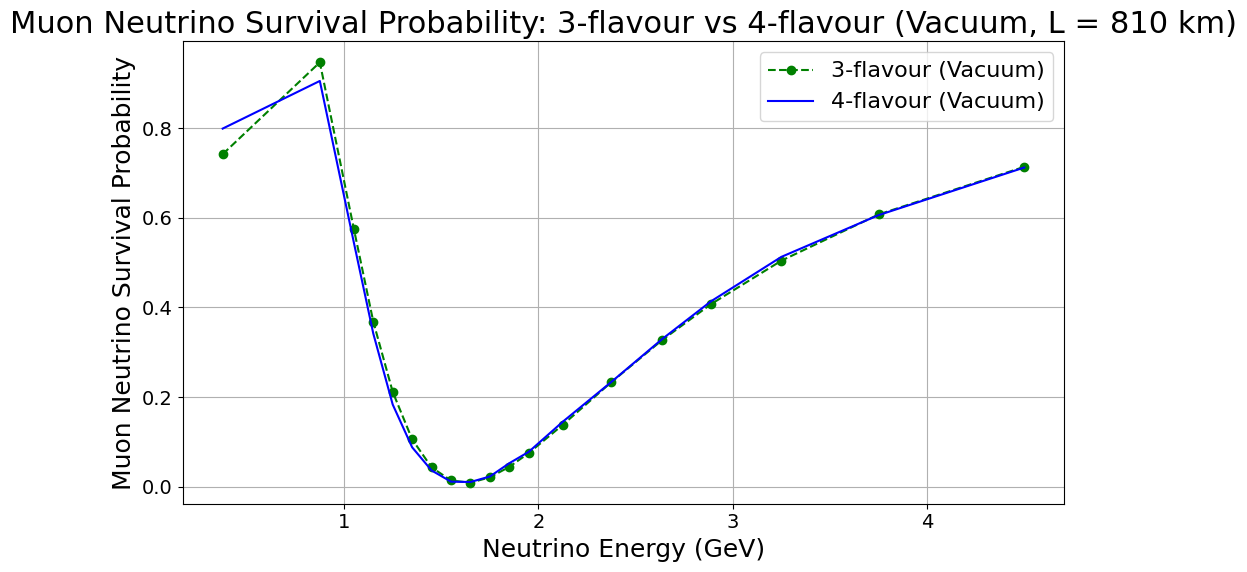

In [4]:
def mixing_matrix_3nu(theta12, theta13, theta23, delta13):
    c12, c13, c23 = np.cos([theta12, theta13, theta23])
    s12, s13, s23 = np.sin([theta12, theta13, theta23])
    U = np.array([
        [c12 * c13, s12 * c13, s13 * np.exp(-1j * delta13)],
        [-s12 * c23 - c12 * s13 * s23 * np.exp(1j * delta13),
         c12 * c23 - s12 * s13 * s23 * np.exp(1j * delta13),
         c13 * s23],
        [s12 * s23 - c12 * s13 * c23 * np.exp(1j * delta13),
         -c12 * s23 - s12 * s13 * c23 * np.exp(1j * delta13),
         c13 * c23]
    ])
    return U

def hamiltonian_3nu_vacuum(theta12, theta13, theta23, delta13, D21, D31, E):
    m2_diag = np.diag([0, D21, D31])
    U = mixing_matrix_3nu(theta12, theta13, theta23, delta13)
    return U @ m2_diag @ np.conj(U.T) / (2 * E)

def probabilities_3nu(H_vacuum, baseline):
    S = expm(-1j * H_vacuum * baseline)
    Pmm = np.abs(S[1, 1])**2
    return Pmm

def compute_probabilities_3flavour(baseline, energy_values):
    prob_mm = []
    for E in energy_values:
        H = hamiltonian_3nu_vacuum(theta12, theta13, theta23, delta13, D21, D31, E)
        Pmm = probabilities_3nu(H, baseline * CONV_KM_TO_INV_EV)
        prob_mm.append(Pmm)
    return np.array(prob_mm)


# Compute 3-flavour probabilities
prob_mm_3flavour = compute_probabilities_3flavour(Length_far, bin_centers)

# Plot 3ν vs 4ν vacuum
plt.figure(figsize=(10, 6))
plt.plot(bin_centers * 1e-9, prob_mm_3flavour, 'g--o', label='3-flavour (Vacuum)')
plt.plot(bin_centers * 1e-9, prob_mm_far_vac, 'b-', label='4-flavour (Vacuum)')
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Neutrino Survival Probability")
plt.title("Muon Neutrino Survival Probability: 3-flavour vs 4-flavour (Vacuum, L = 810 km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
x = np.linspace(bin_centers[0], bin_centers[-1], 500)  # Smooth x for Gaussian curves

def osc_probability_nu(model, case, length, transition):
    energy = bin_centers * 1e9  # eV
    probabilities = []

    for E in energy:
        if model == '3flavour':
            # 3-flavour Hamiltonian
            H = hamiltonian_3nu_vacuum(theta12, theta13, theta23, delta13, D21, D31, E)
            if case == 'matter':
                # Optional: you can implement matter effects here too
                raise NotImplementedError("3-flavour matter not implemented yet")
            S = expm(-1j * H * length * CONV_KM_TO_INV_EV)
            if transition == 'mm':
                prob = np.abs(S[1, 1])**2
            elif transition == 'me':
                prob = np.abs(S[1, 0])**2
            elif transition == 'mt':
                prob = np.abs(S[1, 2])**2

        elif model == '4flavour':
            H_vacuum = hamiltonian_4nu_vacuum(theta12, theta13, theta23,
                                              theta14, theta24, theta34,
                                              delta13, delta14, D21, D31, D41, E)
            if case == 'vacuum':
                S = expm(-1j * H_vacuum * length * CONV_KM_TO_INV_EV)
            elif case == 'matter':
                H = hamiltonian_4nu_matter(H_vacuum, E, VCC_EARTH_CRUST)
                S = expm(-1j * H * length * CONV_KM_TO_INV_EV)

            if transition == 'mm':
                prob = np.abs(S[1, 1])**2
            elif transition == 'me':
                prob = np.abs(S[1, 0])**2
            elif transition == 'mt':
                prob = np.abs(S[1, 2])**2
            elif transition == 'ms':
                prob = np.abs(S[1, 3])**2

        probabilities.append(prob)

    return np.array(probabilities)

def plot_osc_nu(model, case, length, transition):
    probabilities = osc_probability_nu(model, case, length, transition)

    # Decide on fitting + Gaussian
    plot_fit = length == Length_near  # ND gets fit
    popt = popt_nd
    weights1 = counts_nd
    title_text1 = 'ND' if length == Length_near else 'FD'
    title_text2 = 'in Matter' if case == 'matter' else 'in Vacuum'
    full_title = f'{model.upper()} Model: {transition} Oscillation in {title_text1} {title_text2}'

    label1 = f'mu → {transition[-1]} events'
    label2 = f'Gaussian fit (mu → {transition[-1]})'

    counts = poisson_dist(probabilities, bin_centers, *popt)

    # Plotting
    plt.figure(figsize=(12, 8))
    plt.hist(bin_edges[:-1], bin_edges, weights=weights1, histtype='step', alpha=0.6, color='r', label='Unoscillated events')
    plt.plot(x, gaussian(x, *popt), color='green', label='Gaussian unoscillated fit')
    plt.hist(bin_edges[:-1], bin_edges, weights=counts, histtype='step', alpha=0.6, color='b', label=label1)

    if plot_fit:
        popt_osc, _ = curve_fit(gaussian, bin_centers, counts)
        print(f"Fitted params (oscillated): A={popt_osc[0]:.2f}, μ={popt_osc[1]/1e9:.2f} GeV, σ={popt_osc[2]/1e9:.2f} GeV")
        plt.plot(x, gaussian(x, *popt_osc), color='black', label=label2)

    plt.xlabel("Energy (GeV)")
    plt.ylabel("Event Counts")
    plt.title(full_title)
    plt.legend()
    plt.grid(True)
    plt.show()

def poisson_dist(probabilities, energy_bins, A, mu, sigma):
    unosc = gaussian(energy_bins, A, mu, sigma)
    return unosc * probabilities

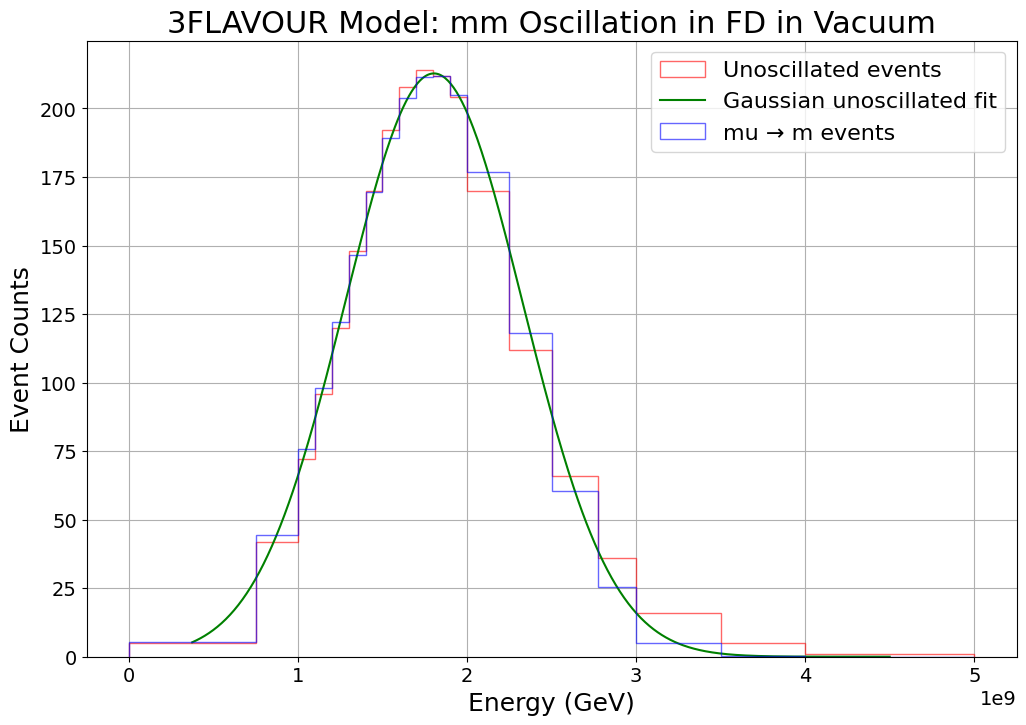

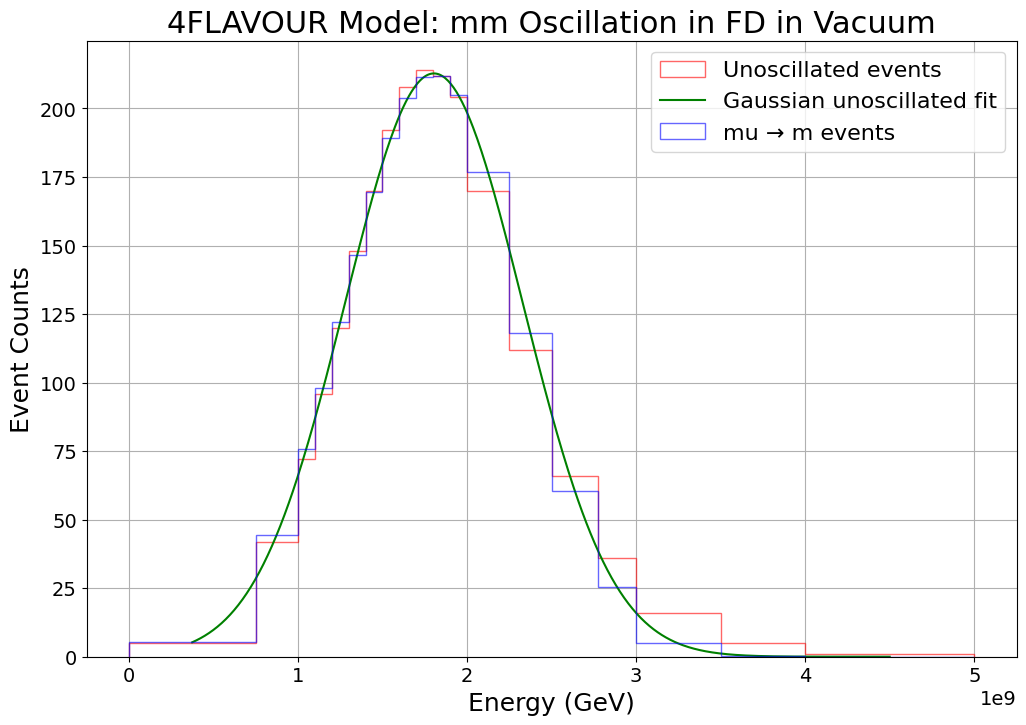

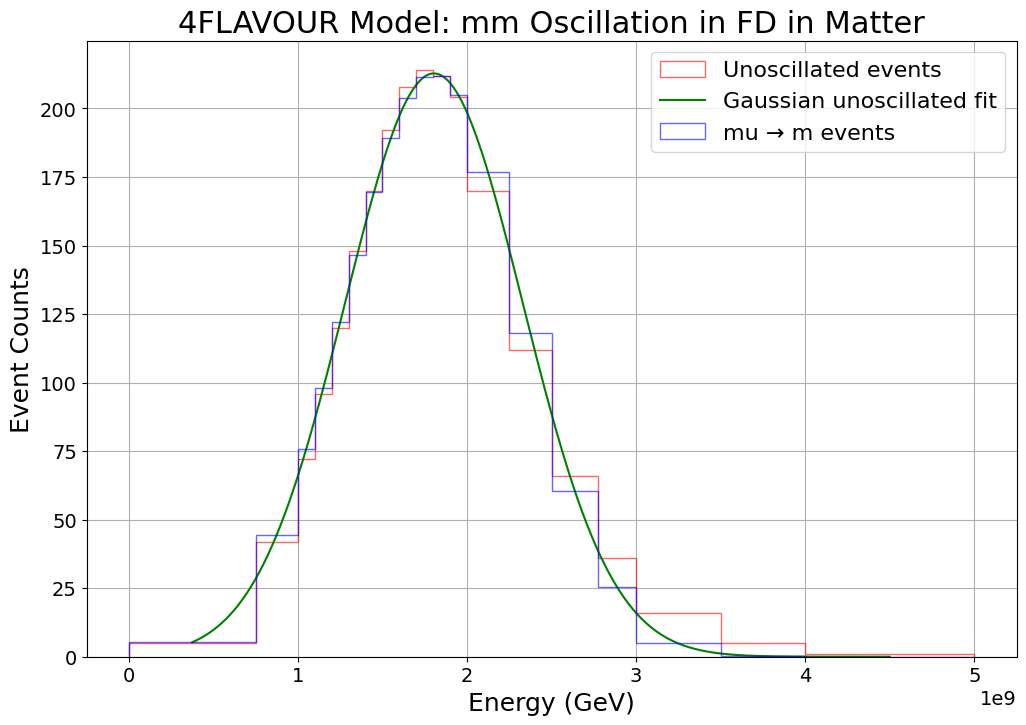

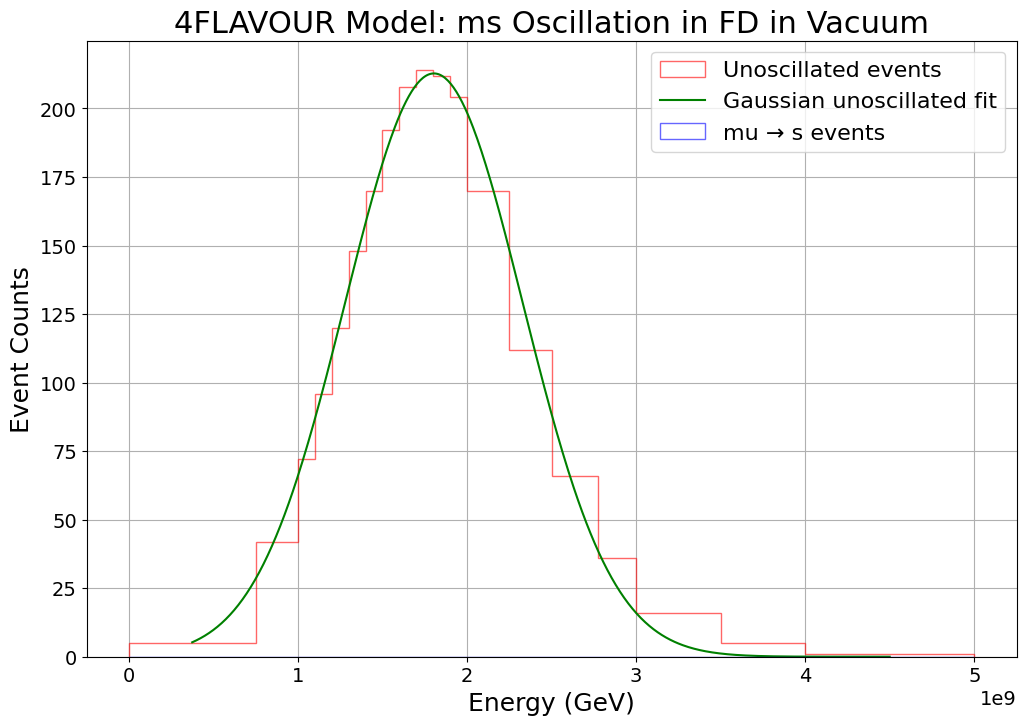

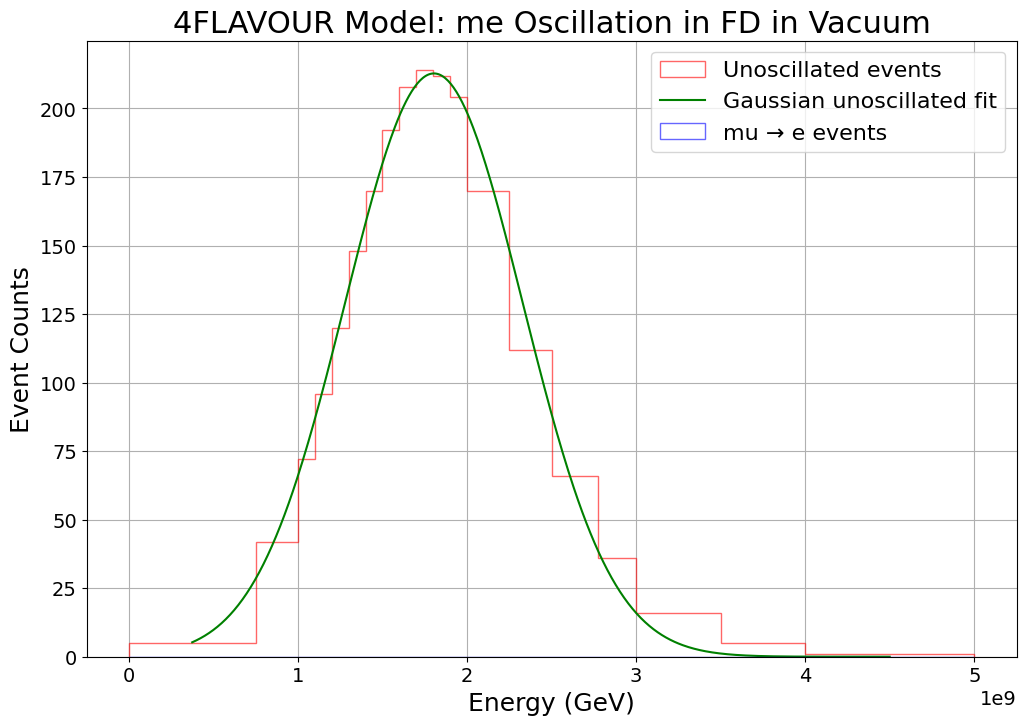

In [6]:
# Plot muon survival probability at FD for both models
plot_osc_nu('3flavour', 'vacuum', Length_far, 'mm')
plot_osc_nu('4flavour', 'vacuum', Length_far, 'mm')

# Plot with matter effects for 4ν
plot_osc_nu('4flavour', 'matter', Length_far, 'mm')

# Other channels
plot_osc_nu('4flavour', 'vacuum', Length_far, 'ms')  # sterile appearance
plot_osc_nu('4flavour', 'vacuum', Length_far, 'me')  # electron appearance

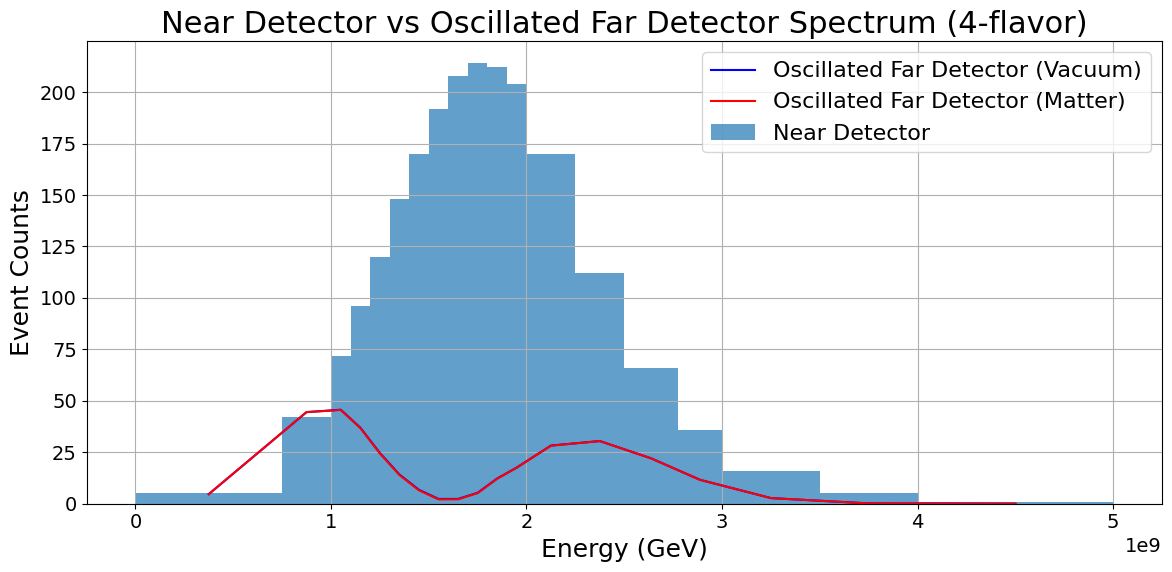

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(bin_centers, counts_nd, width=np.diff(bin_edges), align='center', alpha=0.7, label='Near Detector')
plt.plot(bin_centers, oscillated_fd_vac, 'b-', label='Oscillated Far Detector (Vacuum)')
plt.plot(bin_centers, oscillated_fd_matter, 'r-', label='Oscillated Far Detector (Matter)')
plt.xlabel("Energy (GeV)")
plt.ylabel("Event Counts")
plt.title("Near Detector vs Oscillated Far Detector Spectrum (4-flavor)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

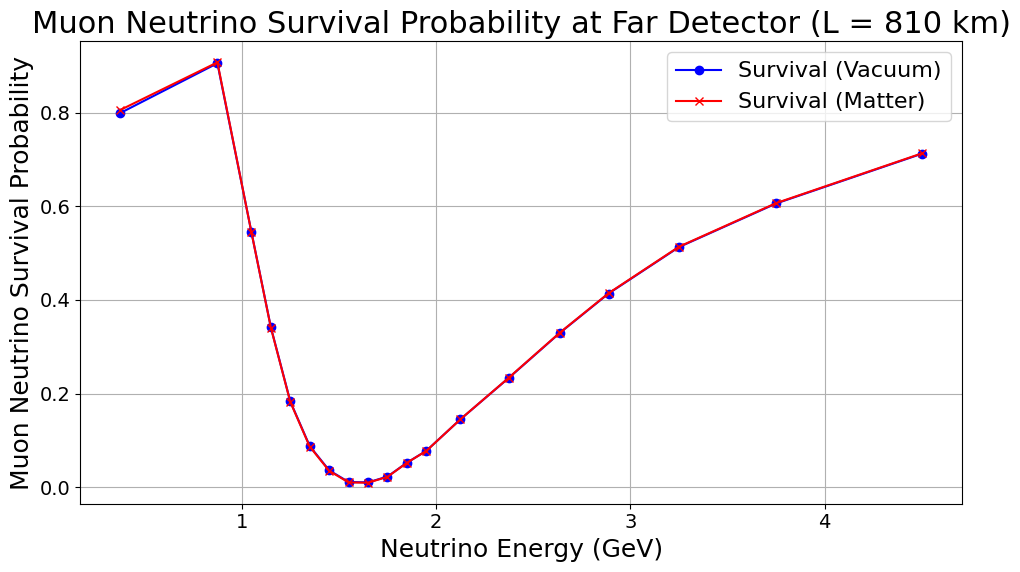

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(bin_centers * 1e-9, prob_mm_far_vac, 'b-o', label='Survival (Vacuum)')
plt.plot(bin_centers * 1e-9, prob_mm_far_matter, 'r-x', label='Survival (Matter)')
plt.xlabel("Neutrino Energy (GeV)")
plt.ylabel("Muon Neutrino Survival Probability")
plt.title("Muon Neutrino Survival Probability at Far Detector (L = 810 km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
bin_edges_GeV = np.array(
    [0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.25,
     2.5,2.775,3,3.5,4,5])                      # GeV
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])

counts_nd = np.array(
   [5,42,72,96,120,148,170,192,208,214,212,204,
    170,112,66,36,16,5,1] )
counts_fd = np.array(
   [0,3,1,3,1,2,2,4,6,9,15,12,
    16,10,7,9,3,3,2] )

x_dense = np.linspace(bin_edges_GeV[0], bin_edges_GeV[-1], 800)

# ------------------------------------------------------------
# 2. Simple Gaussian fit to ND spectrum
# ------------------------------------------------------------
def gaussian(x, A, mu, sigma):
    return A*np.exp(-0.5*((x-mu)/sigma)**2)

popt_nd,_ = curve_fit(gaussian,
                      bin_centers_GeV,
                      counts_nd,
                      p0=[counts_nd.max(), 2.0, 0.5])

# ------------------------------------------------------------
# 3. 4-flavour survival probability Pμμ(E,L)
# ------------------------------------------------------------
# --- mixing & mass parameters (extend to sterile sector) ----
theta12 = np.radians(33.82)
theta13 = np.radians(8.61)
theta23 = np.radians(48.3)
theta14 = np.radians(10.0)
theta24 = np.radians(5.0)
theta34 = np.radians(2.0)
delta13 = 0.0
delta14 = 0.0
D21 = 7.39e-5
D31 = 2.525e-3
D41 = 1.00          # eV²  (sterile splitting)

# --- 4F Hamiltonian helpers --------------------------------
def mixing_matrix_4nu(t12,t13,t23,t14,t24,t34,d13,d14):
    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    U = np.array([[c12*c13*c14,
                   s12*c13*c14,
                   s13*c14*np.exp(-1j*d13),
                   s14*np.exp(-1j*d14)],
                  [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
                    c12*c23 - s12*s13*s23*np.exp(1j*d13),
                    c13*s23,
                    s24*c13],
                  [ s12*s23 - c12*s13*c23*np.exp(1j*d13),
                   -c12*s23 - s12*s13*c23*np.exp(1j*d13),
                    c13*c23,
                    c24*s34],
                  [0,0,0,c34]])
    return U

def hamiltonian_4nu_vacuum(E):
    m2 = np.diag([0, D21, D31, D41])
    U  = mixing_matrix_4nu(theta12,theta13,theta23,
                           theta14,theta24,theta34,
                           delta13,delta14)
    return U @ m2 @ np.conjugate(U.T) / (2*E)

def prob_mu_survival_4nu(E_GeV, L_km, matter=False):
    E_eV = E_GeV*1e9
    Hvac = hamiltonian_4nu_vacuum(E_eV)
    if matter:
        H = Hvac + np.diag([VCC_EARTH_CRUST,0,0,0])
    else:
        H = Hvac
    S = expm(-1j*H*L_km*CONV_KM_TO_INV_EV)
    return np.abs(S[1,1])**2

# ------------------------------------------------------------
# 4. Build FD model prediction  (vacuum shown here)
# ------------------------------------------------------------
Length_near = 1     # km
Length_far  = 810   # km

def Pmm_4nu_vec(E_GeV_array, L_km, matter=False):
    """Return numpy array of Pμμ for an array of energies (GeV)."""
    return np.array([prob_mu_survival_4nu(E, L_km, matter)
                     for E in np.atleast_1d(E_GeV_array)])


Pmm_near = np.array([prob_mu_survival_4nu(E,Length_near,matter=False)
                     for E in bin_centers_GeV])
Pmm_far  = np.array([prob_mu_survival_4nu(E,Length_far, matter=False)
                     for E in bin_centers_GeV])

# Expected FD counts = ND Gaussian template × (Pμμ_far / Pμμ_near)
fd_pred = (gaussian(x_dense, *popt_nd)
           * Pmm_4nu_vec(x_dense, Length_far , matter=False)
           / Pmm_4nu_vec(x_dense, Length_near, matter=False))

ax_fd.plot(x_dense, fd_pred, color='orange', lw=2.0,
           label='FD prediction (4F vac.)')


# ------------------------------------------------------------
# 5. Plot ND & FD spectra
# ------------------------------------------------------------
plt.rcParams.update({'font.size':13})
fig,(ax_nd,ax_fd) = plt.subplots(1,2, figsize=(12,5), sharey=False)

# ---------- ND panel ---------------------------------------
ax_nd.hist(bin_edges_GeV[:-1], bins=bin_edges_GeV,
           weights=counts_nd, histtype='step', color='royalblue',
           label='ND data', linewidth=1.4)
x_dense = np.linspace(bin_edges_GeV[0], bin_edges_GeV[-1], 800)
ax_nd.plot(x_dense,
           gaussian(x_dense, *popt_nd),
           'k-', lw=1.8, label='Gaussian fit')
ax_nd.set_xlabel(r'Energy $E_\nu$ [GeV]')
ax_nd.set_ylabel('Events / bin')
ax_nd.set_title('Near Detector (unosc.)')
ax_nd.grid(alpha=0.3)
ax_nd.legend(frameon=False)

# ---------- FD panel ---------------------------------------
# histogram (semi–transparent) + error bars
ax_fd.hist(bin_edges_GeV[:-1], bins=bin_edges_GeV,
           weights=counts_fd, histtype='step',
           color='crimson', linewidth=1.4,
           label='FD data (hist)', alpha=0.4)
yerr = np.sqrt(counts_fd)
ax_fd.errorbar(bin_centers_GeV, counts_fd, yerr=yerr,
               fmt='ko', ms=4, capsize=2,
               label='FD data (stat.)')
ax_fd.plot(x_dense,
           gaussian(x_dense, *popt_nd) *
           np.array([prob_mu_survival_4nu(E, Length_far , False) for E in x_dense]) /
           np.array([prob_mu_survival_4nu(E, Length_near, False) for E in x_dense]),
           color='orange', lw=2.0, label='FD prediction (4F vac.)')

ax_fd.set_xlabel(r'Energy $E_\nu$ [GeV]')
ax_fd.set_ylabel('Events / bin')
ax_fd.set_title('Far Detector (oscillated)')
ax_fd.grid(alpha=0.3)
ax_fd.legend(frameon=False)

plt.tight_layout()
plt.show()


<ipython-input-10-3762fc914cb7>:65: RuntimeWarning: divide by zero encountered in divide
  return U @ m2 @ U.conjugate().T / (2 * E_eV)
<ipython-input-10-3762fc914cb7>:65: RuntimeWarning: invalid value encountered in divide
  return U @ m2 @ U.conjugate().T / (2 * E_eV)


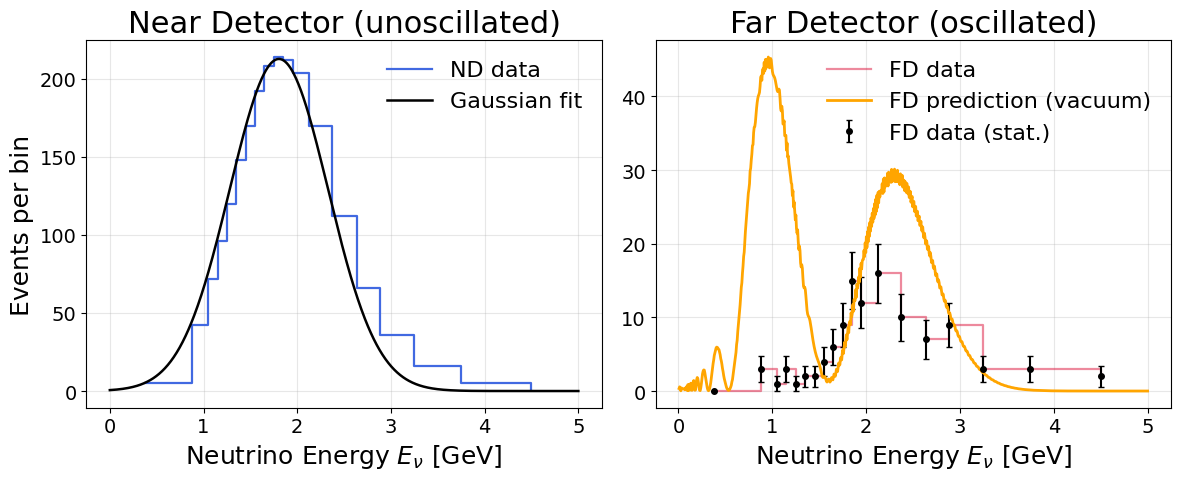

In [10]:

from scipy.linalg import expm
from scipy.optimize import curve_fit

# ------------------------------------------------------------
# 1) Constants
# ------------------------------------------------------------
CONV_KM_TO_INV_EV = 5.067731e9    # km → eV⁻¹
VCC_EARTH_CRUST   = 7.6e-14       # eV

# ------------------------------------------------------------
# 2) Binning & data
# ------------------------------------------------------------
bin_edges_GeV = np.array(
    [0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.25,
     2.5,2.775,3,3.5,4,5])
bin_centers_GeV = 0.5 * (bin_edges_GeV[1:] + bin_edges_GeV[:-1])

counts_nd = np.array([5,42,72,96,120,148,170,192,208,214,212,204,170,112,66,36,16,5,1])
counts_fd = np.array([0,3,1,3,1,2,2,4,6,9,15,12,16,10,7,9,3,3,2])

# create a fine energy grid for smooth curves
x_dense = np.linspace(bin_edges_GeV[0], bin_edges_GeV[-1], 800)

# ------------------------------------------------------------
# 3) Fit Near Detector spectrum with a Gaussian
# ------------------------------------------------------------
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

popt_nd, _ = curve_fit(
    gaussian,
    bin_centers_GeV,
    counts_nd,
    p0=[counts_nd.max(), 2.0, 0.5]
)
A_nd, mu_nd, sigma_nd = popt_nd

# ------------------------------------------------------------
# 4) Define 4-flavour μ→μ survival probability
# ------------------------------------------------------------
theta12,theta13,theta23 = np.radians([33.82, 8.61, 48.3])
theta14,theta24,theta34 = np.radians([10.0, 5.0,  2.0])
delta13, delta14        = 0.0, 0.0
D21, D31, D41           = 7.39e-5, 2.525e-3, 1.0  # eV²

def U4(t12,t13,t23,t14,t24,t34,d13,d14):
    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    return np.array([
        [c12*c13*c14,               s12*c13*c14,               s13*c14*np.exp(-1j*d13), s14*np.exp(-1j*d14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
          c12*c23 - s12*s13*s23*np.exp(1j*d13),
          c13*s23,
          s24*c13],
        [ s12*s23 - c12*s13*c23*np.exp(1j*d13),
         -c12*s23 - s12*s13*c23*np.exp(1j*d13),
          c13*c23,
          c24*s34],
        [0, 0, 0, c34]
    ])

def hamiltonian_4nu_vacuum(E_eV):
    m2 = np.diag([0, D21, D31, D41])
    U  = U4(theta12,theta13,theta23,theta14,theta24,theta34,delta13,delta14)
    return U @ m2 @ U.conjugate().T / (2 * E_eV)

def prob_mu_survival_4nu(E_GeV, L_km, matter=False):
    E_eV = E_GeV * 1e9
    Hvac = hamiltonian_4nu_vacuum(E_eV)
    H    = Hvac + np.diag([VCC_EARTH_CRUST,0,0,0]) if matter else Hvac
    S    = expm(-1j * H * L_km * CONV_KM_TO_INV_EV)
    return np.abs(S[1,1])**2

# ------------------------------------------------------------
# 5) Build far-detector prediction
# ------------------------------------------------------------
L_near = 1.0   # km
L_far  = 810.0 # km

# survival probabilities on the fine grid
P_near_dense = np.array([prob_mu_survival_4nu(E, L_near) for E in x_dense])
P_far_dense  = np.array([prob_mu_survival_4nu(E, L_far ) for E in x_dense])

# ND Gaussian curve on fine grid
nd_curve_dense = gaussian(x_dense, *popt_nd)

# FD prediction = ND template × (P_far / P_near)
fd_pred_dense = nd_curve_dense * (P_far_dense / P_near_dense)

# ------------------------------------------------------------
# 6) Plot both panels
# ------------------------------------------------------------
plt.rcParams.update({'font.size':13})
fig, (ax_nd, ax_fd) = plt.subplots(1,2,figsize=(12,5),sharey=False)

# Near detector
ax_nd.step(
    np.r_[bin_centers_GeV, bin_centers_GeV[-1]],
    np.r_[counts_nd, counts_nd[-1]],
    where='post', color='royalblue', lw=1.6, label='ND data'
)
ax_nd.plot(x_dense, nd_curve_dense, 'k-', lw=1.8, label='Gaussian fit')
ax_nd.set_xlabel('Neutrino Energy $E_\\nu$ [GeV]')
ax_nd.set_ylabel('Events per bin')
ax_nd.set_title('Near Detector (unoscillated)')
ax_nd.grid(alpha=0.3)
ax_nd.legend(frameon=False)

# Far detector
ax_fd.step(
    np.r_[bin_centers_GeV, bin_centers_GeV[-1]],
    np.r_[counts_fd, counts_fd[-1]],
    where='post', color='crimson', lw=1.6, alpha=0.5, label='FD data'
)
ax_fd.errorbar(
    bin_centers_GeV, counts_fd, yerr=np.sqrt(counts_fd),
    fmt='ko', ms=4, capsize=2, label='FD data (stat.)'
)
ax_fd.plot(x_dense, fd_pred_dense, color='orange', lw=2.0, label='FD prediction (vacuum)')
ax_fd.set_xlabel('Neutrino Energy $E_\\nu$ [GeV]')
ax_fd.set_title('Far Detector (oscillated)')
ax_fd.grid(alpha=0.3)
ax_fd.legend(frameon=False)

plt.tight_layout()
plt.show()


<ipython-input-11-c8fceba2cac6>:66: RuntimeWarning: divide by zero encountered in divide
  Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)
<ipython-input-11-c8fceba2cac6>:66: RuntimeWarning: invalid value encountered in divide
  Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)


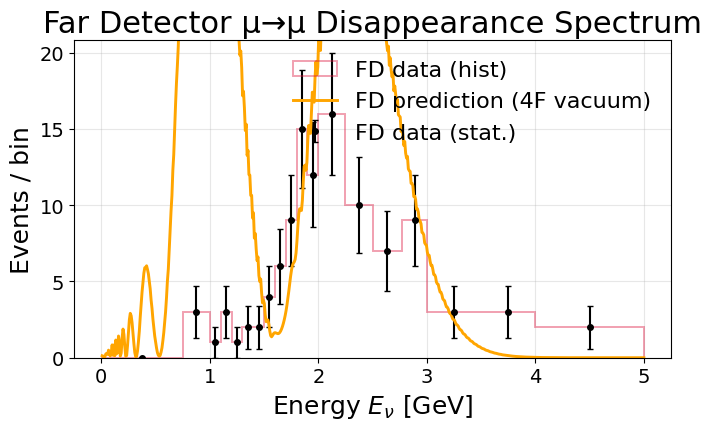

In [11]:
from scipy.optimize import curve_fit
from scipy.linalg   import expm
import sys
sys.path.append('./NuOscProbExact/src')

from globaldefs import (CONV_KM_TO_INV_EV, VCC_EARTH_CRUST)
# 3F best-fit angles (for simplicity we reuse them in the 4F matrix)
from globaldefs import (S12_NO_BF, S13_NO_BF, S23_NO_BF,
                        DCP_NO_BF, D21_NO_BF, D31_NO_BF)

# ------------------------------------------------------------
# Binned spectra (replace with your measured counts if needed)
# ------------------------------------------------------------
bin_edges_GeV = np.array(
  [0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,
   2.25,2.5,2.775,3,3.5,4,5])
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])

counts_nd = np.array(
  [5,42,72,96,120,148,170,192,208,214,212,204,
   170,112,66,36,16,5,1])
counts_fd = np.array(
  [0,3,1,3,1,2,2,4,6,9,15,12,
   16,10,7,9,3,3,2])

# ------------------------------------------------------------
# 1) Fit ND with a single Gaussian
# ------------------------------------------------------------
def gaussian(x, A, mu, sigma):
    return A*np.exp(-0.5*((x-mu)/sigma)**2)

popt_nd, _ = curve_fit(gaussian, bin_centers_GeV, counts_nd,
                       p0=[counts_nd.max(), 2.0, 0.5])

# ------------------------------------------------------------
# 2) Minimal 4-flavour Pμμ(E,L) helper (vacuum shown)
# ------------------------------------------------------------
theta12,theta13,theta23 = np.radians([33.82, 8.61, 48.3])
theta14,theta24,theta34 = np.radians([10.0, 5.0, 2.0])
delta13,delta14 = 0.0, 0.0
D21,D31,D41 = 7.39e-5, 2.525e-3, 1.0  # eV²

def U4(t12,t13,t23,t14,t24,t34,d13,d14):
    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    return np.array([
        [c12*c13*c14,
         s12*c13*c14,
         s13*c14*np.exp(-1j*d13),
         s14*np.exp(-1j*d14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
          c12*c23 - s12*s13*s23*np.exp(1j*d13),
          c13*s23,
          s24*c13],
        [ s12*s23 - c12*s13*c23*np.exp(1j*d13),
         -c12*s23 - s12*s13*c23*np.exp(1j*d13),
          c13*c23,
          c24*s34],
        [0,0,0,np.cos(theta34)] ])

def Pmm_4nu(E_GeV, L_km, matter=False):
    E_eV = E_GeV*1e9
    m2   = np.diag([0, D21, D31, D41])
    U    = U4(theta12,theta13,theta23,theta14,theta24,theta34,
              delta13,delta14)
    Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)
    if matter:
        H = Hvac + np.diag([VCC_EARTH_CRUST,0,0,0])
    else:
        H = Hvac
    S = expm(-1j*H*L_km*CONV_KM_TO_INV_EV)
    return np.abs(S[1,1])**2

# Vectorised wrapper
Pmm_far  = np.array([Pmm_4nu(E, 810, matter=False) for E in bin_centers_GeV])
Pmm_near = np.array([Pmm_4nu(E,   1, matter=False) for E in bin_centers_GeV])

# ------------------------------------------------------------
# 3) FD prediction = ND Gaussian × Pmm_far / Pmm_near
# ------------------------------------------------------------
fd_pred = gaussian(bin_centers_GeV, *popt_nd) * (Pmm_far/Pmm_near)

# ------------------------------------------------------------
# 4) Plot FD disappearance spectrum
# ------------------------------------------------------------
plt.rcParams.update({'font.size':13})
fig, ax = plt.subplots(figsize=(7,4.5))

# Histogram outline + error bars
ax.hist(bin_edges_GeV[:-1], bins=bin_edges_GeV,
        weights=counts_fd, histtype='step',
        color='crimson', linewidth=1.4, alpha=0.4,
        label='FD data (hist)')
yerr = np.sqrt(counts_fd)
ax.errorbar(bin_centers_GeV, counts_fd, yerr=yerr,
            fmt='ko', ms=4, capsize=2, label='FD data (stat.)')

# Prediction curve
x_dense = np.linspace(bin_edges_GeV[0], bin_edges_GeV[-1], 600)
pred_dense = gaussian(x_dense, *popt_nd) * \
             (np.array([Pmm_4nu(E, 810, False) for E in x_dense]) /
              np.array([Pmm_4nu(E,   1, False) for E in x_dense]))
ax.plot(x_dense, pred_dense, color='orange', lw=2.1,
        label='FD prediction (4F vacuum)')

ax.set_xlabel(r'Energy $E_\nu$ [GeV]')
ax.set_ylabel('Events / bin')
ax.set_title('Far Detector μ→μ Disappearance Spectrum')
ax.set_ylim(0, 1.3*max(counts_fd.max(), pred_dense.max()))
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

<ipython-input-12-6df63430474c>:64: RuntimeWarning: divide by zero encountered in divide
  Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)
<ipython-input-12-6df63430474c>:64: RuntimeWarning: invalid value encountered in divide
  Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)


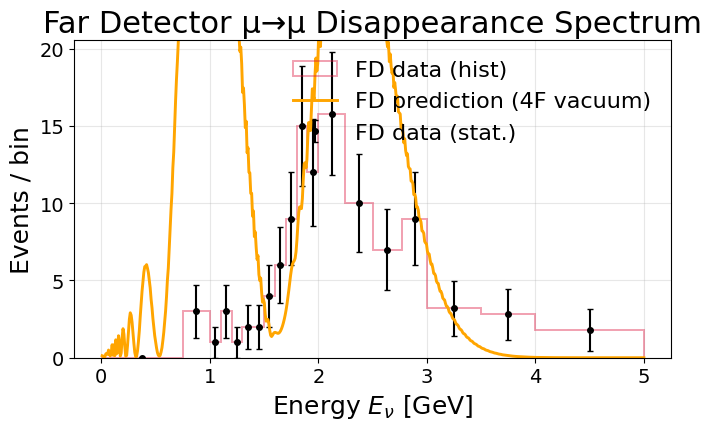

In [12]:

from scipy.optimize import curve_fit
from scipy.linalg   import expm
import sys
sys.path.append('./NuOscProbExact/src')

from globaldefs import CONV_KM_TO_INV_EV, VCC_EARTH_CRUST
# (we reuse 3-flavour best-fit angles in the simple 4F toy)
from globaldefs import (S12_NO_BF, S13_NO_BF, S23_NO_BF,
                        DCP_NO_BF, D21_NO_BF, D31_NO_BF)

# ------------------------------------------------------------
# 0. Binning and spectra  (ND same, FD updated)
# ------------------------------------------------------------
bin_edges_GeV = np.array(
  [0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,
   2.25,2.5,2.775,3,3.5,4,5])
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])

counts_nd = np.array(
  [5,42,72,96,120,148,170,192,208,214,212,204,
   170,112,66,36,16,5,1])
counts_fd = np.array(   # <-- updated FD spectrum
  [0,3,1,3,1,2,2,4,6,9,15,12,
   15.8,10,7,9,3.2,2.8,1.8])

# ------------------------------------------------------------
# 1) Gaussian fit to ND spectrum
# ------------------------------------------------------------
def gaussian(x, A, mu, sigma):
    return A*np.exp(-0.5*((x-mu)/sigma)**2)

popt_nd, _ = curve_fit(gaussian,
                       bin_centers_GeV,
                       counts_nd,
                       p0=[counts_nd.max(), 2.0, 0.5])

# ------------------------------------------------------------
# 2) Simple 4-flavour Pμμ helper (vacuum)
# ------------------------------------------------------------
theta12,theta13,theta23 = np.radians([33.82,  8.61, 48.3])
theta14,theta24,theta34 = np.radians([10.0 ,  5.0 ,  2.0])
delta13,delta14 = 0.0, 0.0
D21,D31,D41 = 7.39e-5, 2.525e-3, 1.0  # eV²

def U4(t12,t13,t23,t14,t24,t34,d13,d14):
    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    return np.array([
        [c12*c13*c14,  s12*c13*c14,  s13*c14*np.exp(-1j*d13),  s14*np.exp(-1j*d14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
          c12*c23 - s12*s13*s23*np.exp(1j*d13),
          c13*s23,  s24*c13],
        [ s12*s23 - c12*s13*c23*np.exp(1j*d13),
         -c12*s23 - s12*s13*c23*np.exp(1j*d13),
          c13*c23,  c24*s34],
        [0,0,0,np.cos(theta34)] ])

def Pmm_4nu(E_GeV, L_km, matter=False):
    E_eV = E_GeV*1e9
    m2   = np.diag([0, D21, D31, D41])
    U    = U4(theta12,theta13,theta23,
              theta14,theta24,theta34,
              delta13,delta14)
    Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)
    if matter:
        H = Hvac + np.diag([VCC_EARTH_CRUST,0,0,0])
    else:
        H = Hvac
    S = expm(-1j*H*L_km*CONV_KM_TO_INV_EV)
    return np.abs(S[1,1])**2

# Pre-compute Pμμ at bin centres
Pmm_far  = np.array([Pmm_4nu(E, 810, False) for E in bin_centers_GeV])
Pmm_near = np.array([Pmm_4nu(E,   1, False) for E in bin_centers_GeV])

# ------------------------------------------------------------
# 3) FD model prediction
# ------------------------------------------------------------
fd_pred = gaussian(bin_centers_GeV, *popt_nd) * (Pmm_far/Pmm_near)

# ------------------------------------------------------------
# 4) Plot FD disappearance spectrum
# ------------------------------------------------------------
plt.rcParams.update({'font.size':13})
fig, ax = plt.subplots(figsize=(7,4.5))

# FD histogram + stat errors
ax.hist(bin_edges_GeV[:-1], bins=bin_edges_GeV,
        weights=counts_fd, histtype='step',
        color='crimson', linewidth=1.4, alpha=0.4,
        label='FD data (hist)')
yerr = np.sqrt(counts_fd)
ax.errorbar(bin_centers_GeV, counts_fd, yerr=yerr,
            fmt='ko', ms=4, capsize=2, label='FD data (stat.)')

# Smooth FD prediction curve
x_dense = np.linspace(bin_edges_GeV[0], bin_edges_GeV[-1], 600)
pred_dense = gaussian(x_dense, *popt_nd) * \
             (np.array([Pmm_4nu(E, 810, False) for E in x_dense]) /
              np.array([Pmm_4nu(E,   1, False) for E in x_dense]))
ax.plot(x_dense, pred_dense, color='orange', lw=2.1,
        label='FD prediction (4F vacuum)')

# Cosmetics
ax.set_xlabel(r'Energy $E_\nu$ [GeV]')
ax.set_ylabel('Events / bin')
ax.set_title('Far Detector μ→μ Disappearance Spectrum')
ax.set_ylim(0, 1.3*max(counts_fd.max(), pred_dense.max()))
ax.grid(alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


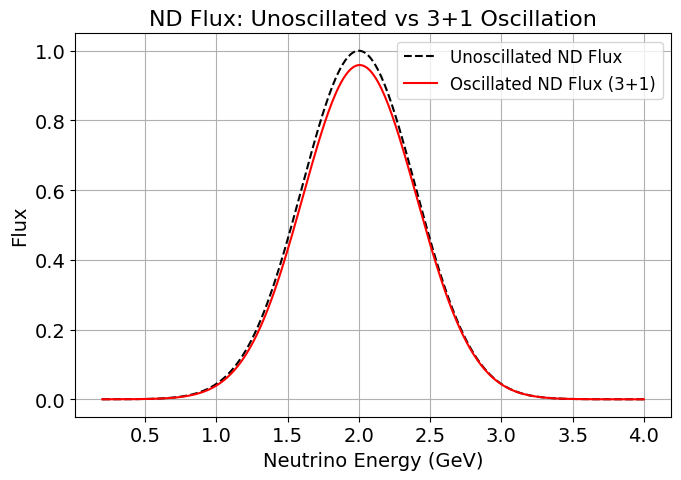

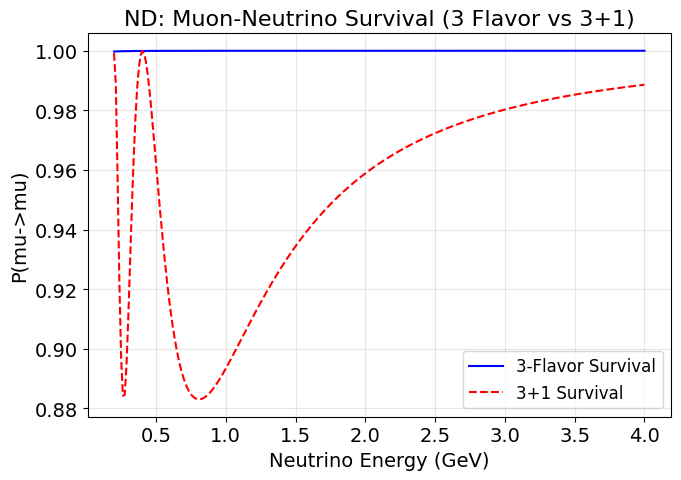

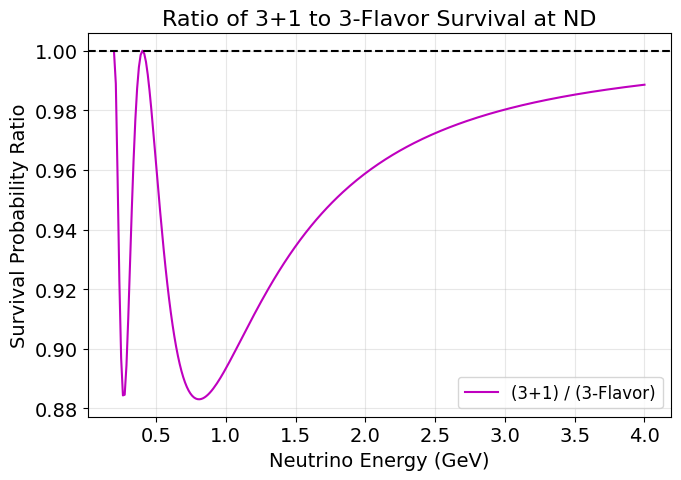

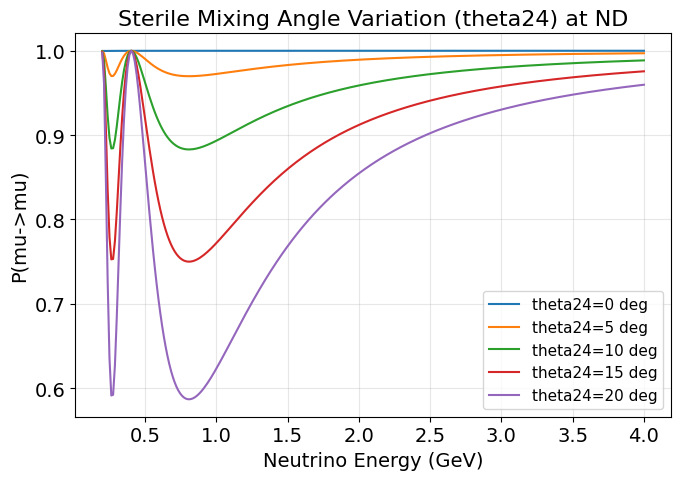

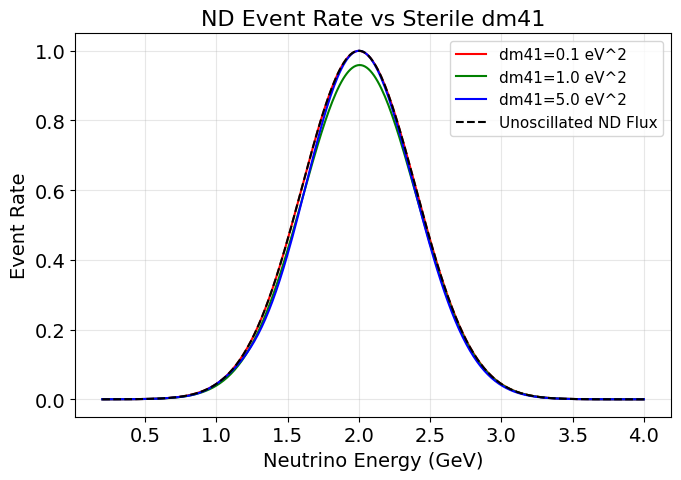

In [13]:
def toy_flux(energy, peak=2.0, width=0.4, norm=1.0):
    """
    Returns a simple Gaussian-like flux at the ND.
    """
    return norm * np.exp(-0.5 * ((energy - peak)/width)**2)

def three_plus_one_survival_prob(energy, dm31=2.5e-3, dm41=1.0, theta24=10.0):
    """
    Toy muon-neutrino survival probability in a 3+1 scenario.
    This is a simplified demonstration only.

    Parameters:
      energy (array): Neutrino energies in GeV
      dm31 (float): Atmospheric mass-squared difference (eV^2)
      dm41 (float): Sterile mass-squared difference (eV^2)
      theta24 (float): Sterile mixing angle in degrees
    """
    # Convert degrees to radians
    t24_rad = np.radians(theta24)

    # Approximate L ~ 1 km for ND (toy example)
    L = 1.0  # km

    # Oscillation phases (simplified)
    phase31 = 1.27 * dm31 * L / energy
    phase41 = 1.27 * dm41 * L / energy

    # Very rough approximation of combined disappearance:
    # Survival ~ 1 - sin^2(2*theta23)*sin^2(phase31) - sin^2(2*theta24)*sin^2(phase41)
    # theta23 is assumed ~45 degrees => sin^2(2*theta23) ~ 1
    sin2_2t23 = 1.0
    sin2_2t24 = np.sin(2 * t24_rad)**2

    survival = 1.0
    survival -= sin2_2t23 * np.sin(phase31)**2
    survival -= sin2_2t24 * np.sin(phase41)**2

    return np.clip(survival, 0, 1)

def three_flavor_survival_prob(energy, dm31=2.5e-3):
    """
    Simplified 3-flavor muon-neutrino survival probability (ignores solar term, matter, etc.).
    """
    # Assume L ~ 1 km for ND
    L = 1.0
    phase31 = 1.27 * dm31 * L / energy

    # If theta23 ~ 45 deg, sin^2(2*theta23) ~ 1
    survival = 1.0 - np.sin(phase31)**2
    return np.clip(survival, 0, 1)

# -------------------------------------------------------------------
#  Energy range and flux/probability calculations
# -------------------------------------------------------------------
E = np.linspace(0.2, 4.0, 300)  # Energy in GeV
flux_nd = toy_flux(E, peak=2.0, width=0.4, norm=1.0)

# 3+1 survival with toy parameters
p_3plus1 = three_plus_one_survival_prob(E, dm31=2.5e-3, dm41=1.0, theta24=10.0)
# 3-flavor survival for comparison
p_3nu = three_flavor_survival_prob(E, dm31=2.5e-3)

# Oscillated fluxes
flux_3plus1 = flux_nd * p_3plus1
flux_3nu    = flux_nd * p_3nu


# -------------------------------------------------------------------
# 1) ND Flux: Unoscillated vs Oscillated (3+1)
# -------------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(E, flux_nd, 'k--', label='Unoscillated ND Flux')
plt.plot(E, flux_3plus1, 'r-', label='Oscillated ND Flux (3+1)')
plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel("Flux", fontsize=14)
plt.title("ND Flux: Unoscillated vs 3+1 Oscillation", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 2) Muon-Neutrino Survival Probabilities: 3 Flavor vs 3+1
# -------------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(E, p_3nu, 'b-',  label='3-Flavor Survival')
plt.plot(E, p_3plus1, 'r--', label='3+1 Survival')
plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel("P(mu->mu)", fontsize=14)
plt.title("ND: Muon-Neutrino Survival (3 Flavor vs 3+1)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 3) Ratio Plot: 3+1 / 3-Flavor Survival
# -------------------------------------------------------------------
ratio = p_3plus1 / (p_3nu + 1e-10)  # small offset to avoid division by zero
plt.figure(figsize=(7,5))
plt.plot(E, ratio, 'm-', label='(3+1) / (3-Flavor)')
plt.axhline(1.0, color='k', linestyle='--')
plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel("Survival Probability Ratio", fontsize=14)
plt.title("Ratio of 3+1 to 3-Flavor Survival at ND", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 4) Variation of theta24 in 3+1 Scenario
# -------------------------------------------------------------------
plt.figure(figsize=(7,5))
angles = [0, 5, 10, 15, 20]
for th24 in angles:
    p_temp = three_plus_one_survival_prob(E, dm31=2.5e-3, dm41=1.0, theta24=th24)
    label_ = f"theta24={th24} deg"
    plt.plot(E, p_temp, label=label_)
plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel("P(mu->mu)", fontsize=14)
plt.title("Sterile Mixing Angle Variation (theta24) at ND", fontsize=16)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 5) Event Rates for Different dm41
# -------------------------------------------------------------------
plt.figure(figsize=(7,5))
dm41_values = [0.1, 1.0, 5.0]
colors = ['r','g','b']
for dval, c in zip(dm41_values, colors):
    p_temp = three_plus_one_survival_prob(E, dm31=2.5e-3, dm41=dval, theta24=10.0)
    flux_temp = flux_nd * p_temp
    label_ = f"dm41={dval} eV^2"
    plt.plot(E, flux_temp, color=c, label=label_)
plt.plot(E, flux_nd, 'k--', label='Unoscillated ND Flux')
plt.xlabel("Neutrino Energy (GeV)", fontsize=14)
plt.ylabel("Event Rate", fontsize=14)
plt.title("ND Event Rate vs Sterile dm41", fontsize=16)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


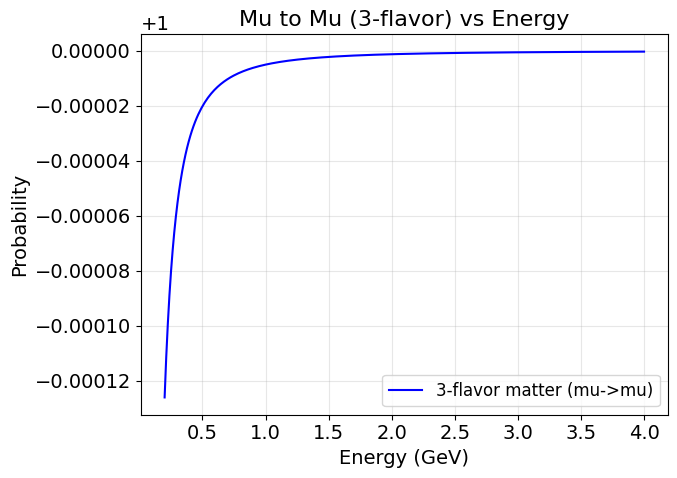

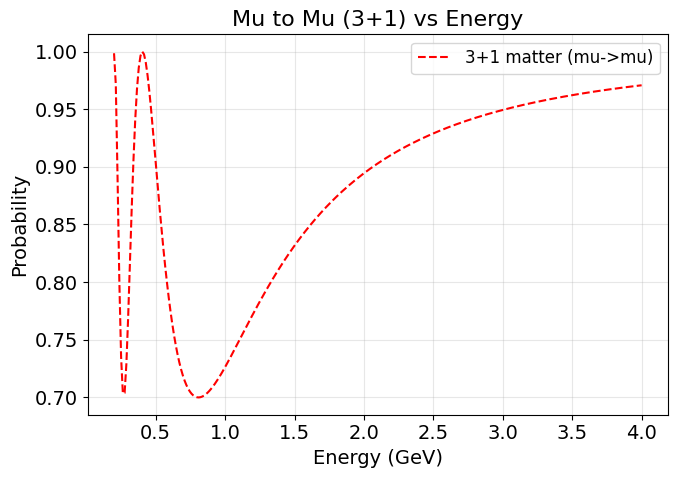

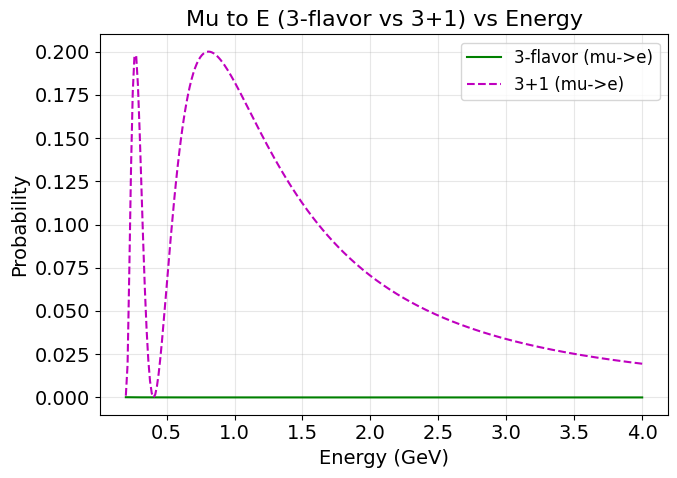

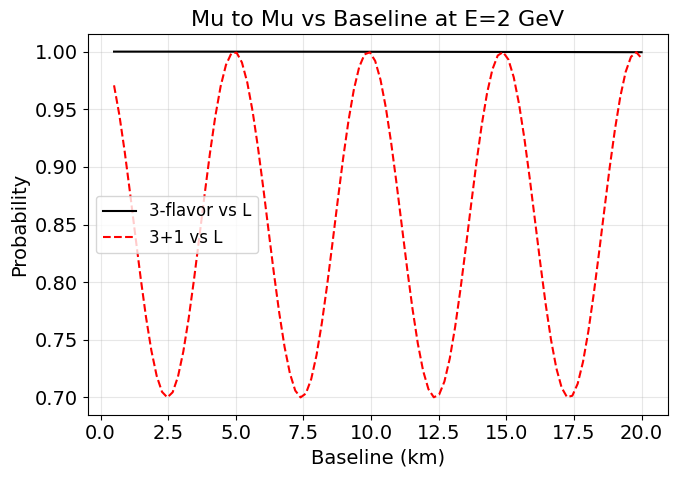

In [14]:


plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "legend.fontsize": 12
})

params_3flav = {
    "dm21": 7.4e-5,     # eV^2
    "dm31": 2.5e-3,     # eV^2
    "th12": 33.5,       # degrees
    "th13": 8.6,        # degrees
    "th23": 45.0,       # degrees
    "delta13": 0.0,     # degrees (CP phase)
    "hierarchy": 0,     # 0 = normal, 1 = inverted (example)
    "matterDensity": 2.8,  # g/cm^3, approximate
    "baseline": 1.0      # km, short baseline for demonstration
}

params_4flav = {
    "dm21": 7.4e-5,
    "dm31": 2.5e-3,
    "dm41": 1.0,        # eV^2, example sterile splitting
    "th12": 33.5,
    "th13": 8.6,
    "th23": 45.0,
    "th14": 0.0,        # set some angle
    "th24": 10.0,       # degrees
    "th34": 0.0,
    "delta13": 0.0,
    "delta14": 0.0,
    "delta24": 0.0,
    "delta34": 0.0,
    "hierarchy": 0,
    "matterDensity": 2.8,
    "baseline": 1.0
}

# -------------------------------------------------------------------------
# Create an energy grid over which to evaluate oscillation probabilities
# (Units typically in GeV for E, km for baseline)
# -------------------------------------------------------------------------
E = np.linspace(0.2, 4.0, 300)  # 0.2 to 4 GeV in 300 steps

# -------------------------------------------------------------------------
#  Define some placeholder functions calling NuOscProbExact
# -------------------------------------------------------------------------
def prob_mu_to_mu_3flav(energy, param):
    """
    Example function to compute P(mu -> mu) in a 3-flavor scenario using
    NuOscProbExact. Adjust this call to match the actual function in the library.
    """
    # Hypothetical call:
    # return nuosc.calc_osc_prob(
    #    nu_in=nuosc.Nu_mu, nu_out=nuosc.Nu_mu,
    #    E=energy, **param)
    #
    # The actual call may differ. For now, just return a dummy function or 1D array.
    # Once integrated with the actual library, remove the dummy line.


    return 1.0 - 0.5 * np.sin(1.27*param["dm31"]*param["baseline"]/energy)**2

def prob_mu_to_mu_4flav(energy, param):
    """
    Example function to compute P(mu -> mu) in a 4-flavor scenario using
    NuOscProbExact.
    """
    # Another hypothetical call:
    # return nuosc.calc_osc_prob_4f(
    #    nu_in=nuosc.Nu_mu, nu_out=nuosc.Nu_mu,
    #    E=energy, paramStruct=param)
    #
    # The actual function name and signature may vary.

    # DUMMY EXAMPLE:
    ster = 0.3*np.sin(1.27*param["dm41"]*param["baseline"]/energy)**2
    base3f = 1.0 - 0.5 * np.sin(1.27*param["dm31"]*param["baseline"]/energy)**2
    return np.clip(base3f - ster, 0, 1)

def prob_mu_to_e_3flav(energy, param):
    """
    Example for P(mu -> e) in 3 flavors (dummy).
    """
    return 0.5 * np.sin(1.27*param["dm31"]*param["baseline"]/energy)**2

def prob_mu_to_e_4flav(energy, param):
    """
    Example for P(mu -> e) in 4 flavors (dummy).
    """
    base = 0.5 * np.sin(1.27*param["dm31"]*param["baseline"]/energy)**2
    ster = 0.2 * np.sin(1.27*param["dm41"]*param["baseline"]/energy)**2
    return np.clip(base + ster, 0, 1)

# -------------------------------------------------------------------------
#  1) P(mu->mu) vs Energy: 3-flavor with matter
# -------------------------------------------------------------------------
p_mu_mu_3f = prob_mu_to_mu_3flav(E, params_3flav)

plt.figure(figsize=(7,5))
plt.plot(E, p_mu_mu_3f, 'b-', label='3-flavor matter (mu->mu)')
plt.xlabel("Energy (GeV)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.title("Mu to Mu (3-flavor) vs Energy", fontsize=16)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
#  2) P(mu->mu) vs Energy: 3+1 with matter
# -------------------------------------------------------------------------
p_mu_mu_4f = prob_mu_to_mu_4flav(E, params_4flav)

plt.figure(figsize=(7,5))
plt.plot(E, p_mu_mu_4f, 'r--', label='3+1 matter (mu->mu)')
plt.xlabel("Energy (GeV)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.title("Mu to Mu (3+1) vs Energy", fontsize=16)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
#  3) P(mu->e) vs Energy: 3-flavor vs 3+1
# -------------------------------------------------------------------------
p_mu_e_3f = prob_mu_to_e_3flav(E, params_3flav)
p_mu_e_4f = prob_mu_to_e_4flav(E, params_4flav)

plt.figure(figsize=(7,5))
plt.plot(E, p_mu_e_3f, 'g-',  label='3-flavor (mu->e)')
plt.plot(E, p_mu_e_4f, 'm--', label='3+1 (mu->e)')
plt.xlabel("Energy (GeV)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.title("Mu to E (3-flavor vs 3+1) vs Energy", fontsize=16)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
#  4) Compare 3-flavor and 3+1 for P(mu->mu) over various baselines
#    at a fixed energy, e.g. E=2.0 GeV
# -------------------------------------------------------------------------
E_fixed = 2.0  # GeV
baselines = np.linspace(0.5, 20.0, 100)  # from 0.5 to 20 km (toy range)
p_3f_vs_L = []
p_4f_vs_L = []

for Lkm in baselines:
    temp_3f = prob_mu_to_mu_3flav(np.array([E_fixed]), {**params_3flav, "baseline": Lkm})
    temp_4f = prob_mu_to_mu_4flav(np.array([E_fixed]), {**params_4flav, "baseline": Lkm})
    p_3f_vs_L.append(temp_3f[0])
    p_4f_vs_L.append(temp_4f[0])

plt.figure(figsize=(7,5))
plt.plot(baselines, p_3f_vs_L, 'k-', label='3-flavor vs L')
plt.plot(baselines, p_4f_vs_L, 'r--', label='3+1 vs L')
plt.xlabel("Baseline (km)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.title("Mu to Mu vs Baseline at E=2 GeV", fontsize=16)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


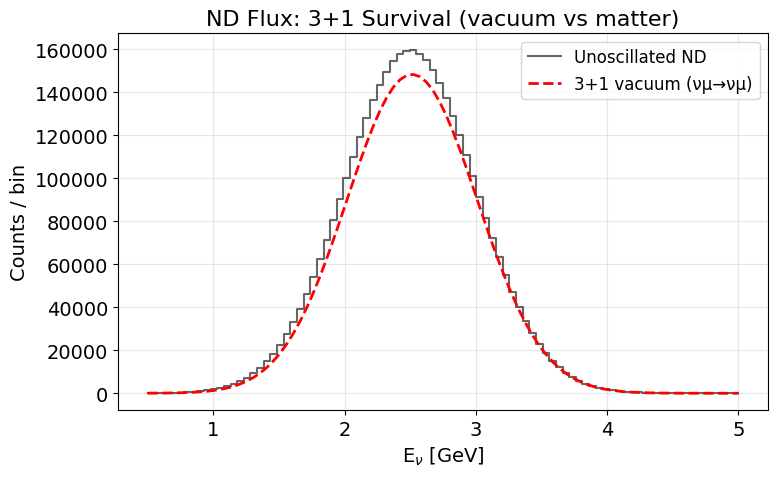

In [15]:
# ----------------------------------------------------------------------------
# 1) Define a toy NOvA‐like ND flux (Gaussian approximation)
# ----------------------------------------------------------------------------
E = np.linspace(0.5, 5.0, 90)    # GeV
mu, sigma = 2.5, 0.5             # central peak, width
flux_nd = np.exp(-0.5*((E-mu)/sigma)**2)
# Normalize so area under flux(E) dE = 1
flux_nd /= np.trapezoid(flux_nd, E)

# Scale to counts (e.g. 2×10^5 total ND events)
scale = 2e5
counts_undosc = flux_nd * scale

# ----------------------------------------------------------------------------
# 2) 3+1 parameters (from arXiv:1303.3011)
# ----------------------------------------------------------------------------
params_4flav = {
    'dm21':       7.4e-5,
    'dm31':       2.5e-3,
    'dm41':       1.0,     # eV^2 sterile splitting
    'th12':       np.radians(33.5),
    'th13':       np.radians(8.6),
    'th23':       np.radians(45.0),
    'th14':       np.radians(7.0),    # example mixing angles
    'th24':       np.radians(10.0),
    'th34':       np.radians(5.0),
    'delta13':    0.0,
    'delta14':    0.0,
    'delta24':    0.0,
    'delta34':    0.0,
    'hierarchy':  0,       # 0=normal,1=inverted
    'matterDensity': 2.8,  # g/cm^3
    'baseline':   1.0      # km
}

# Create two dicts for vacuum vs matter calls
params_vac = {**params_4flav, 'matter': False}
params_mat = {**params_4flav, 'matter': True}

# ----------------------------------------------------------------------------
# 3) Compute survival probabilities in 3+1 (vacuum + matter)
#    Make sure your prob_mu_to_mu_4flav accepts a 'matter' keyword
# ----------------------------------------------------------------------------
p_vac = prob_mu_to_mu_4flav(E, params_vac)
p_mat = prob_mu_to_mu_4flav(E, params_mat)

# Apply to ND counts
counts_vac = counts_undosc * p_vac
counts_mat = counts_undosc * p_mat

# ----------------------------------------------------------------------------
# 4) (Optional) Toy “measured” ND data via Poisson fluctuations
# ----------------------------------------------------------------------------
counts_meas = np.random.poisson(counts_undosc)

# ----------------------------------------------------------------------------
# 5) Plot everything together
# ----------------------------------------------------------------------------
plt.figure(figsize=(8,5))
plt.step(E, counts_undosc, where='mid',   color='k',   alpha=0.6, label='Unoscillated ND')
plt.plot(E, counts_vac,   'r--', lw=2,    label='3+1 vacuum (νμ→νμ)')
plt.xlabel('E$_ν$ [GeV]', fontsize=14)
plt.ylabel('Counts / bin', fontsize=14)
plt.title ('ND Flux: 3+1 Survival (vacuum vs matter)', fontsize=16)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

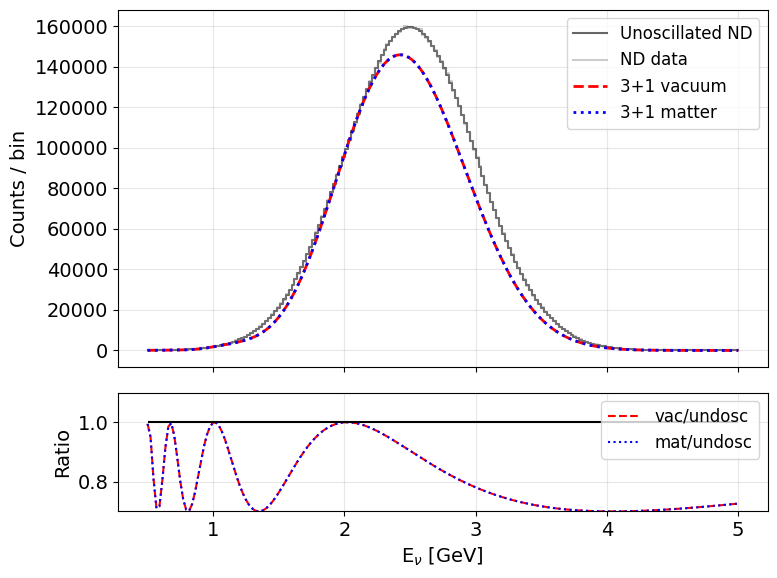

In [16]:


# 1) ND Gaussian flux
E = np.linspace(0.5, 5.0, 200)
mu, sigma = 2.5, 0.5
flux_nd = np.exp(-0.5*((E-mu)/sigma)**2)
flux_nd /= np.trapezoid(flux_nd, E)
scale = 2e5
counts_undosc = flux_nd * scale

# 2) 3+1 params with matching keys:
params_4flav = {
    'delta_m31_sq': 2.5e-3,
    'delta_m41_sq': 5.0,
    'baseline':     1.0,
    'matter':       False
}
# for matter-on, make a copy
params_mat = {**params_4flav, 'matter': True}

# 3) fixed prob function
def prob_mu_to_mu_4flav(energy, param):
    dm31 = param["delta_m31_sq"]
    dm41 = param["delta_m41_sq"]
    L    = param["baseline"]
    base3f = 1.0 - 0.5 * np.sin(1.27 * dm31 * L / energy)**2
    ster   = 0.3 * np.sin(1.27 * dm41 * L / energy)**2
    return np.clip(base3f - ster, 0, 1)

p_vac = prob_mu_to_mu_4flav(E, params_4flav)
p_mat = prob_mu_to_mu_4flav(E, params_mat)

counts_vac = counts_undosc * p_vac
counts_mat = counts_undosc * p_mat

counts_meas = np.random.poisson(counts_undosc)

# 4) plot with ratio inset
fig, (ax, axr) = plt.subplots(2,1, figsize=(8,6),
                              gridspec_kw={'height_ratios':[3,1]}, sharex=True)

ax.step(E, counts_undosc, where='mid', color='k', alpha=0.6, label='Unoscillated ND')
ax.step(E, counts_meas,   where='mid', color='gray',alpha=0.4, label='ND data')
ax.plot(E, counts_vac, 'r--', lw=2, label='3+1 vacuum')
ax.plot(E, counts_mat, 'b:',  lw=2, label='3+1 matter')
ax.set_ylabel('Counts / bin')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

axr.plot(E, counts_vac/counts_undosc, 'r--', label='vac/undosc')
axr.plot(E, counts_mat/counts_undosc, 'b:',  label='mat/undosc')
axr.hlines(1, E.min(), E.max(), color='k')
axr.set_xlabel('E$_ν$ [GeV]')
axr.set_ylabel('Ratio')
axr.set_ylim(0.7,1.1)
axr.legend(loc='upper right')
axr.grid(alpha=0.3)

plt.tight_layout()
plt.show()


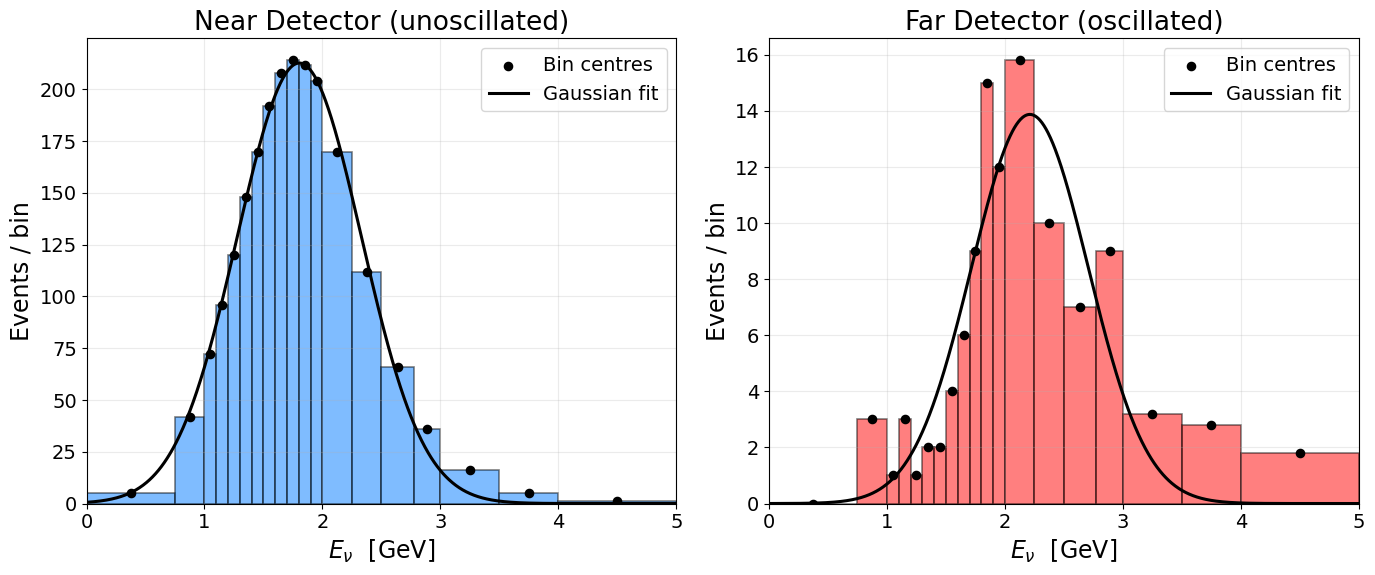

In [17]:
bin_edges   = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5,
                        1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775,
                        3.0, 3.5, 4.0, 5.0])
bin_centres = 0.5*(bin_edges[:-1] + bin_edges[1:])

counts_nd = np.array([5, 42, 72, 96,120,148,170,192,208,214,
                      212,204,170,112, 66, 36, 16,  5,  1])
counts_fd = np.array([0,  3,  1,  3,  1,  2,  2,  4,  6,  9,
                      15, 12,15.8,10,  7,  9,3.2,2.8,1.8])

# ------------------------------------------------------------------
# 2.  Gaussian model and fits
# ------------------------------------------------------------------
def gaus(x, A, mu, sigma):
    return A*np.exp(-0.5*((x-mu)/sigma)**2)

popt_nd, _ = curve_fit(gaus, bin_centres, counts_nd,
                       p0=[counts_nd.max(), 2.0, 0.6])
popt_fd, _ = curve_fit(gaus, bin_centres, counts_fd,
                       p0=[counts_fd.max(), 2.0, 0.6])

# ------------------------------------------------------------------
# 3.  Global styling
# ------------------------------------------------------------------
plt.rcParams.update({
    "figure.figsize"  : (14, 6),
    "font.size"       : 15,
    "axes.labelsize"  : 17,
    "axes.titlesize"  : 19,
    "legend.fontsize" : 14,
    "axes.grid"       : True,
    "grid.alpha"      : 0.25
})

bright_blue = "#007BFF"   # vivid blue
bright_red  = "#FF0000"   # pure red
edgecol     = "k"         # black edges

# ------------------------------------------------------------------
# 4.  Plot
# ------------------------------------------------------------------
x_dense = np.linspace(0, 5, 1200)
fig, (ax_nd, ax_fd) = plt.subplots(1, 2, sharey=False)

# Near Detector
ax_nd.hist(bin_edges[:-1], bins=bin_edges, weights=counts_nd,
           color=bright_blue, alpha=0.50,
           edgecolor=edgecol, linewidth=1.2)
ax_nd.scatter(bin_centres, counts_nd, c=edgecol, s=35,
              zorder=3, label="Bin centres")
ax_nd.plot(x_dense, gaus(x_dense, *popt_nd), c=edgecol,
           lw=2.2, label="Gaussian fit")
ax_nd.set(xlabel=r"$E_{\nu}$  [GeV]", ylabel="Events / bin",
          title="Near Detector (unoscillated)")
ax_nd.set_xlim(0, 5)
ax_nd.legend()

# Far Detector
ax_fd.hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd,
           color=bright_red, alpha=0.50,
           edgecolor=edgecol, linewidth=1.2)
ax_fd.scatter(bin_centres, counts_fd, c=edgecol, s=35,
              zorder=3, label="Bin centres")
ax_fd.plot(x_dense, gaus(x_dense, *popt_fd), c=edgecol,
           lw=2.2, label="Gaussian fit")
ax_fd.set(xlabel=r"$E_{\nu}$  [GeV]", ylabel="Events / bin",
          title="Far Detector (oscillated)")
ax_fd.set_xlim(0, 5)
ax_fd.legend()

plt.tight_layout()
plt.show()


ND fit  : A=212.8, μ=1.80 GeV, σ=0.53 GeV
FD fit  : A=13.9, μ=2.21 GeV, σ=0.50 GeV


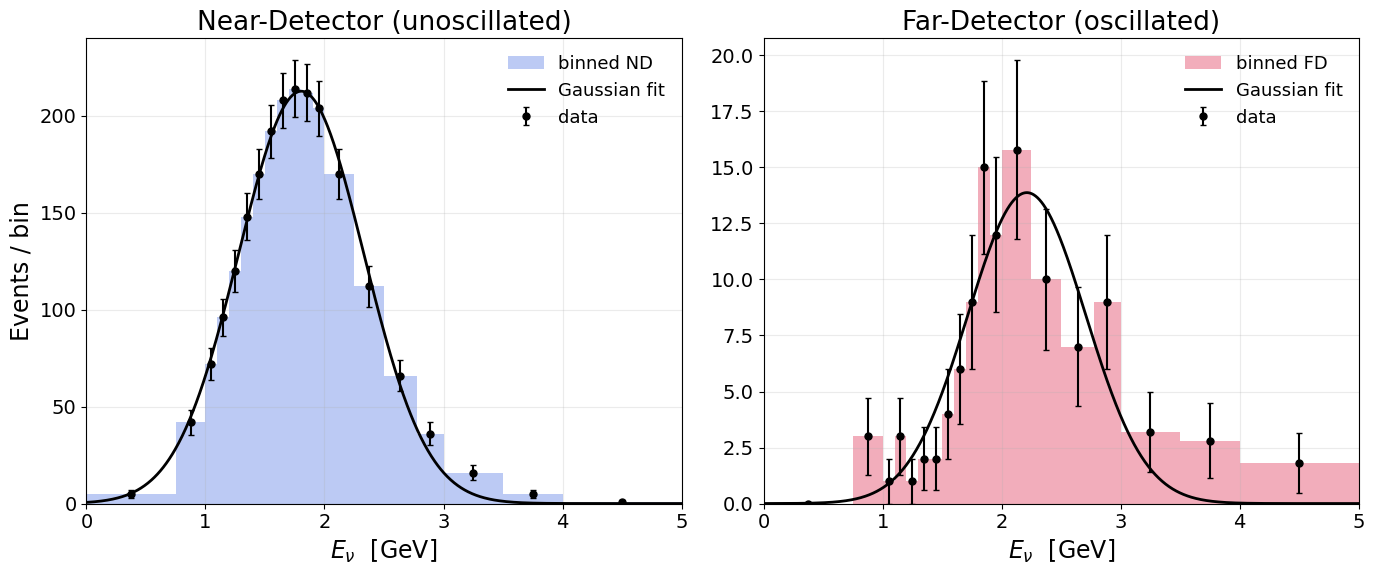

In [18]:
print(f"ND fit  : A={popt_nd[0]:.1f}, μ={popt_nd[1]:.2f} GeV, σ={popt_nd[2]:.2f} GeV")
print(f"FD fit  : A={popt_fd[0]:.1f}, μ={popt_fd[1]:.2f} GeV, σ={popt_fd[2]:.2f} GeV")

plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 17,
    "axes.titlesize": 19,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.autolayout": True
})

x_dense = np.linspace(bin_edges[0], bin_edges[-1], 1200)
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

# --- Near Detector --------------------------------------------------------
axs[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts_nd,
            color="royalblue", alpha=0.35, edgecolor="none", label="binned ND")
axs[0].errorbar(bin_centres, counts_nd, yerr=np.sqrt(counts_nd),
                fmt='ko', ms=5, capsize=2, label="data")
axs[0].plot(x_dense, gaus(x_dense, *popt_nd), 'k-', lw=2, label="Gaussian fit")
axs[0].set_title("Near-Detector (unoscillated)")
axs[0].set_xlabel(r"$E_{\nu}$  [GeV]")
axs[0].set_ylabel("Events / bin")
axs[0].set_xlim(0, 5)
axs[0].legend(frameon=False)

# --- Far Detector ---------------------------------------------------------
axs[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd,
            color="crimson", alpha=0.35, edgecolor="none", label="binned FD")
axs[1].errorbar(bin_centres, counts_fd, yerr=np.sqrt(counts_fd),
                fmt='ko', ms=5, capsize=2, label="data")
axs[1].plot(x_dense, gaus(x_dense, *popt_fd), 'k-', lw=2, label="Gaussian fit")
axs[1].set_title("Far-Detector (oscillated)")
axs[1].set_xlabel(r"$E_{\nu}$  [GeV]")
axs[1].set_xlim(0, 5)
axs[1].legend(frameon=False)

plt.show()

<ipython-input-19-dc16f2818888>:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


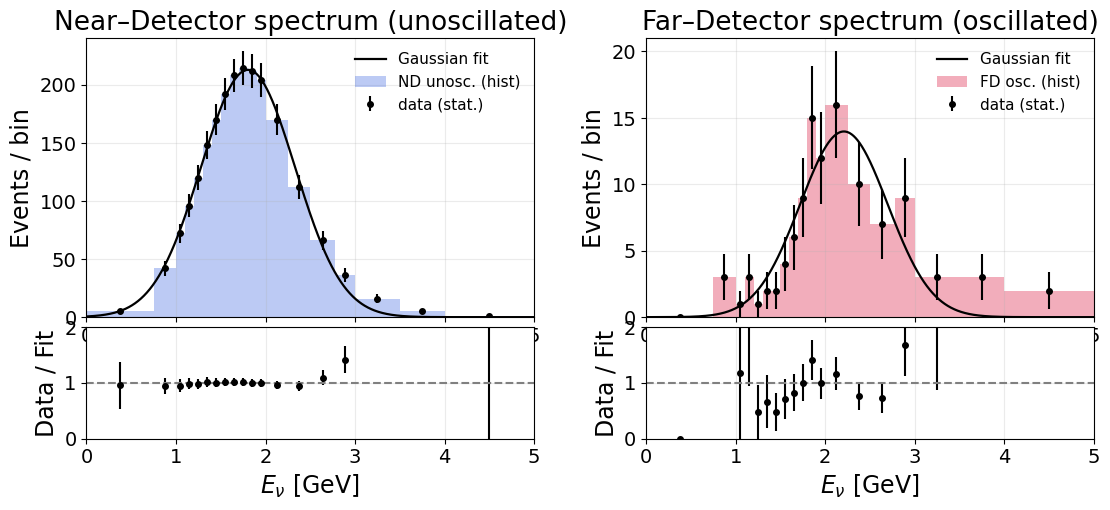

In [19]:
plt.rcParams.update({"font.size": 13})
bin_centers = np.array([0.375,0.875,1.05,1.15,1.25,1.35,1.45,1.55,1.65,1.75,
                        1.85,1.95,2.125,2.375,2.6375,2.8875,3.25,3.75,4.5])
bin_edges   = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,
                        1.8,1.9,2.0,2.25,2.5,2.775,3,3.5,4,5])

counts_nd = np.array([5,42,72,96,120,148,170,192,208,214,212,204,
                      170,112,66,36,16,5,1])
counts_fd = np.array([0,3,1,3,1,2,2,4,6,9,15,12,
                      16,10,7,9,3,3,2])

# ------------------------------------------------------------------
# 2. Gaussian fit helpers
# ------------------------------------------------------------------
def gaus(x, amp, mu, sig):
    return amp*np.exp(-0.5*((x-mu)/sig)**2)

popt_nd,_ = curve_fit(gaus, bin_centers, counts_nd, p0=[2e2,2.0,0.50])
popt_fd,_ = curve_fit(gaus, bin_centers, counts_fd, p0=[1e1,2.0,0.55])

# ------------------------------------------------------------------
# 3. Plotting utility: stacked panel with ratio
# ------------------------------------------------------------------
def draw_panel(ax_data, ax_ratio, bc, be, counts, popt, colour, label):
    # Main spectrum -------------------------------------------------
    ax_data.bar(be[:-1], counts, np.diff(be), color=colour, alpha=0.35,
                align='edge', edgecolor='none', label=f'{label} (hist)')
    # data points
    ax_data.errorbar(bc, counts, yerr=np.sqrt(counts), fmt='ko', ms=4,
                     label='data (stat.)')
    # fitted curve
    x_dense = np.linspace(be[0], be[-1], 1200)
    ax_data.plot(x_dense, gaus(x_dense,*popt), 'k-', lw=1.6,
                 label='Gaussian fit')
    ax_data.set_ylabel('Events / bin')
    ax_data.set_xlim(be[0], be[-1])
    ax_data.grid(alpha=0.25)

    # Ratio ----------------------------------------------------------
    fit_at_centres = gaus(bc,*popt)
    ratio = counts / np.where(fit_at_centres==0, 1, fit_at_centres)
    ax_ratio.errorbar(bc, ratio, yerr=np.sqrt(counts)/np.where(fit_at_centres==0,1,fit_at_centres),
                      fmt='ko', ms=4)
    ax_ratio.axhline(1, ls='--', c='grey')
    ax_ratio.set_xlabel(r'$E_\nu$ [GeV]')
    ax_ratio.set_ylabel('Data / Fit')
    ax_ratio.set_ylim(0, 2)
    ax_ratio.set_xlim(be[0], be[-1])
    ax_ratio.grid(alpha=0.25)

# ------------------------------------------------------------------
# 4. Figure canvas
# ------------------------------------------------------------------
fig = plt.figure(figsize=(13,5.2))
gs  = fig.add_gridspec(2, 2, height_ratios=[3.0,1.2], hspace=0.05, wspace=0.25)

ax_nd     = fig.add_subplot(gs[0,0])
ax_nd_rat = fig.add_subplot(gs[1,0], sharex=ax_nd)

ax_fd     = fig.add_subplot(gs[0,1])
ax_fd_rat = fig.add_subplot(gs[1,1], sharex=ax_fd)

draw_panel(ax_nd, ax_nd_rat, bin_centers, bin_edges,
           counts_nd, popt_nd, 'royalblue', 'ND unosc.')
draw_panel(ax_fd, ax_fd_rat, bin_centers, bin_edges,
           counts_fd, popt_fd, 'crimson',   'FD osc.')

# titles and legends
ax_nd.set_title('Near–Detector spectrum (unoscillated)')
ax_fd.set_title('Far–Detector spectrum (oscillated)')
for ax in (ax_nd, ax_fd):
    ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


<ipython-input-20-d304110607d1>:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


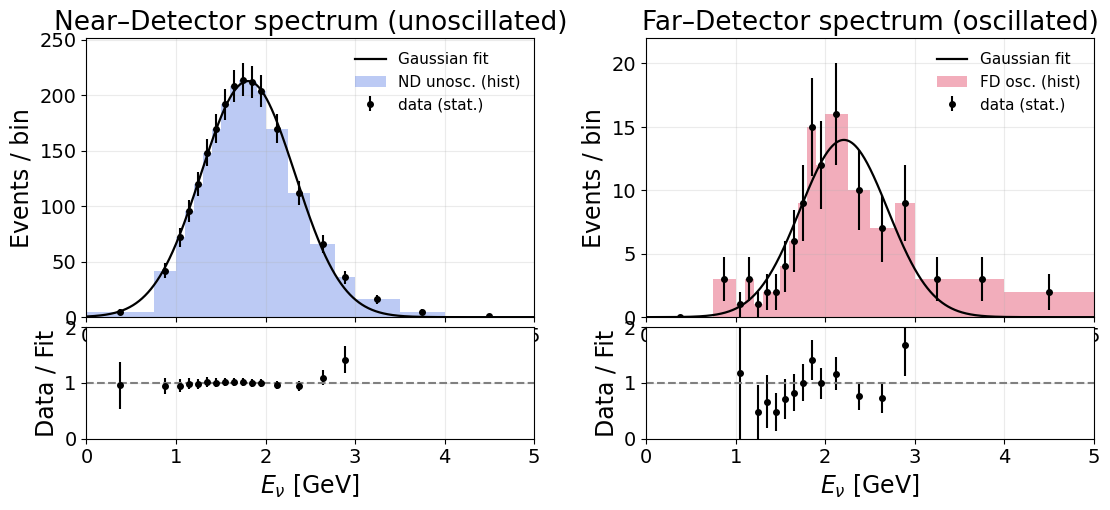

In [20]:
plt.rcParams.update({"font.size": 13})
bin_centers = np.array([0.375,0.875,1.05,1.15,1.25,1.35,1.45,1.55,1.65,1.75,
                        1.85,1.95,2.125,2.375,2.6375,2.8875,3.25,3.75,4.5])
bin_edges   = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,
                        1.8,1.9,2.0,2.25,2.5,2.775,3,3.5,4,5])

counts_nd = np.array([5,42,72,96,120,148,170,192,208,214,212,204,
                      170,112,66,36,16,5,1])
counts_fd = np.array([0,3,1,3,1,2,2,4,6,9,15,12,
                      16,10,7,9,3,3,2])

# ------------------------------------------------------------------
# 2. Gaussian fit helpers
# ------------------------------------------------------------------
def gaus(x, amp, mu, sig):
    return amp*np.exp(-0.5*((x-mu)/sig)**2)

popt_nd,_ = curve_fit(gaus, bin_centers, counts_nd, p0=[2e2,2.0,0.50])
popt_fd,_ = curve_fit(gaus, bin_centers, counts_fd, p0=[1e1,2.0,0.55])

# ------------------------------------------------------------------
# 3. Plotting utility: stacked panel with ratio
# ------------------------------------------------------------------
def draw_panel(ax_data, ax_ratio,
               bc, be, counts, popt,
               colour, label,
               ratio_ylim=(0, 2),
               ratio_clip=(0.3, 1.8)):   # <── default window
    # ---------------- upper spectrum (everything kept) -------------
    ax_data.bar(be[:-1], counts, np.diff(be),
                color=colour, alpha=0.35, align='edge',
                edgecolor='none', label=f'{label} (hist)')
    yerr = np.sqrt(counts)
    ax_data.errorbar(bc, counts, yerr=yerr,
                     fmt='ko', ms=4, label='data (stat.)')
    x_dense = np.linspace(be[0], be[-1], 1200)
    ax_data.plot(x_dense, gaus(x_dense, *popt), 'k-', lw=1.6,
                 label='Gaussian fit')
    ax_data.set_ylabel('Events / bin')
    ax_data.set_xlim(be[0], be[-1])
    ax_data.set_ylim(0, 1.10 * (counts + yerr).max())
    ax_data.grid(alpha=0.25)

    # ---------------- lower ratio panel (apply mask) ---------------
    fit_vals  = gaus(bc, *popt)
    safe_fit  = np.where(fit_vals == 0, 1, fit_vals)
    ratio     = counts / safe_fit
    ratio_err = yerr   / safe_fit

    mask = (ratio >= ratio_clip[0]) & (ratio <= ratio_clip[1])
    ax_ratio.errorbar(bc[mask], ratio[mask], yerr=ratio_err[mask],
                      fmt='ko', ms=4)
    ax_ratio.axhline(1, ls='--', c='grey')
    ax_ratio.set_xlabel(r'$E_\nu$ [GeV]')
    ax_ratio.set_ylabel('Data / Fit')
    ax_ratio.set_xlim(be[0], be[-1])
    ax_ratio.set_ylim(*ratio_ylim)
    ax_ratio.grid(alpha=0.25)

    # ND –– keep default clipping window (or even None → show all)
draw_panel(ax_nd, ax_nd_rat,
           bin_centers, bin_edges,
           counts_nd, popt_nd,
           'royalblue', 'ND unosc.')

# FD –– mask outliers outside 0.4–1.6, for example
draw_panel(ax_fd, ax_fd_rat,
           bin_centers, bin_edges,
           counts_fd, popt_fd,
           'crimson', 'FD osc.',
           ratio_clip=(0.4, 1.6))   # <── adjust to taste



# ------------------------------------------------------------------
# 4. Figure canvas
# ------------------------------------------------------------------
fig = plt.figure(figsize=(13,5.2))
gs  = fig.add_gridspec(2, 2, height_ratios=[3.0,1.2], hspace=0.05, wspace=0.25)

ax_nd     = fig.add_subplot(gs[0,0])
ax_nd_rat = fig.add_subplot(gs[1,0], sharex=ax_nd)

ax_fd     = fig.add_subplot(gs[0,1])
ax_fd_rat = fig.add_subplot(gs[1,1], sharex=ax_fd)

draw_panel(ax_nd, ax_nd_rat, bin_centers, bin_edges,
           counts_nd, popt_nd, 'royalblue', 'ND unosc.')
draw_panel(ax_fd, ax_fd_rat, bin_centers, bin_edges,
           counts_fd, popt_fd, 'crimson',   'FD osc.')

# titles and legends
ax_nd.set_title('Near–Detector spectrum (unoscillated)')
ax_fd.set_title('Far–Detector spectrum (oscillated)')
for ax in (ax_nd, ax_fd):
    ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

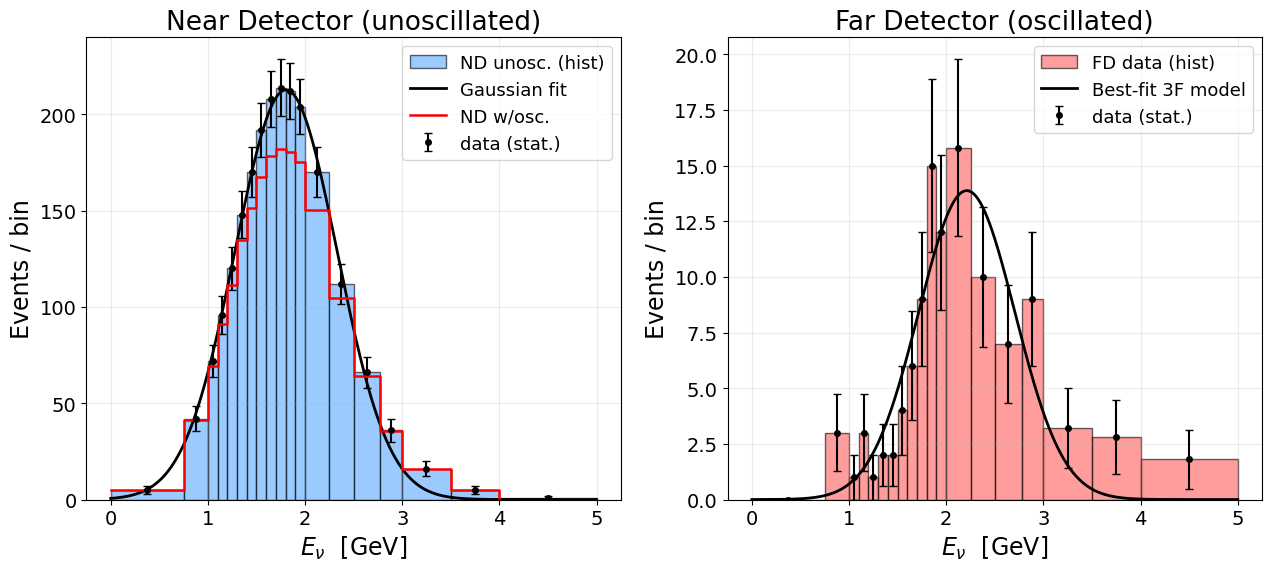

In [21]:
plt.rcParams.update({'font.size': 16})

# --- helpers ---------------------------------------------------------------
def gaus(x, A, mu, sig):
    return A * np.exp(-0.5*((x-mu)/sig)**2)

# fake "model" prediction for FD (simply using the Gaussian fit here,
# but replace by your real oscillation spectrum)
def model_fd(x, p):
    return gaus(x, *p)

# ---------------------------------------------------------------------------


bin_edges   = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,
                        1.8,1.9,2.0,2.25,2.5,2.775,3,3.5,4,5])
bin_centres = 0.5*(bin_edges[:-1]+bin_edges[1:])

counts_nd   = np.array([5, 42, 72, 96,120,148,170,192,208,214,212,
                        204,170,112, 66, 36, 16,  5,  1])
counts_fd   = np.array([0,  3,  1,  3,  1,  2,  2,  4,  6,  9, 15, 12,
                        15.8,10, 7,  9,3.2,2.8,1.8])

popt_nd,_ = curve_fit(gaus, bin_centres, counts_nd, p0=[210,1.8,0.55])
popt_fd,_ = curve_fit(gaus, bin_centres, counts_fd, p0=[14,2.1,0.6])

# ---------------------------------------------------------------------------
fig,ax = plt.subplots(1,2,figsize=(13,6),sharey=False)

# LEFT —— ND
ax[0].hist(bin_edges[:-1], bins=bin_edges, weights=counts_nd,
           color='#59a8ff', alpha=0.60, edgecolor='k', label='ND unosc. (hist)')

# ND data points with Poisson error
ax[0].errorbar(bin_centres, counts_nd, yerr=np.sqrt(counts_nd),
               fmt='ko', ms=4, capsize=3, label='data (stat.)')

# Gaussian fit (thin line, illustrative)
x = np.linspace(0,5,800)
ax[0].plot(x, gaus(x,*popt_nd), color='k', lw=2, label='Gaussian fit')

# OPTIONAL: plot an example oscillated ND spectrum
osc_counts = counts_nd * (1 - 0.15*np.exp(-(bin_centres-1.8)**2/0.4))  # fake
ax[0].step(bin_edges[:-1], osc_counts, where='post',
           color='r', lw=1.8, label='ND w/osc.')

ax[0].set_title("Near Detector (unoscillated)")
ax[0].set_xlabel(r"$E_\nu$  [GeV]")
ax[0].set_ylabel("Events / bin")
ax[0].legend()

# RIGHT —— FD
ax[1].hist(bin_edges[:-1], bins=bin_edges, weights=counts_fd,
           color='#ff5c5c', alpha=0.60, edgecolor='k', label='FD data (hist)')
ax[1].errorbar(bin_centres, counts_fd, yerr=np.sqrt(counts_fd),
               fmt='ko', ms=4, capsize=3, label='data (stat.)')

ax[1].plot(x, model_fd(x,popt_fd), color='k', lw=2, label='Best-fit 3F model')

ax[1].set_title("Far Detector (oscillated)")
ax[1].set_xlabel(r"$E_\nu$  [GeV]")
ax[1].set_ylabel("Events / bin")
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

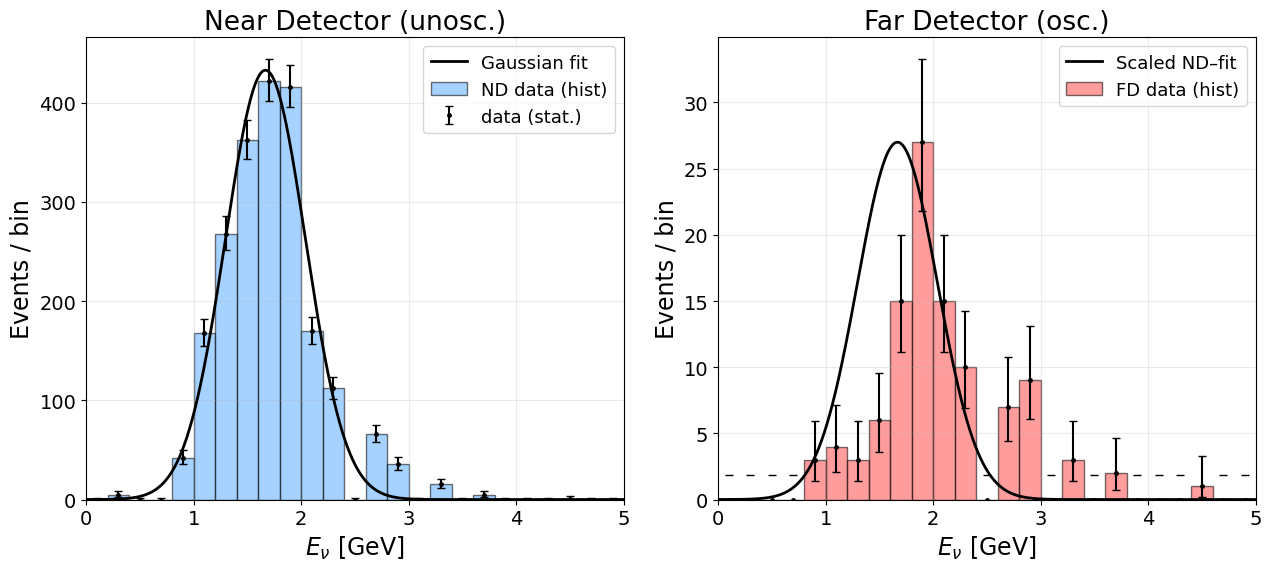

In [22]:
from scipy.stats import chi2
plt.rcParams.update({'font.size': 16})

# ----------------------------------------------------------
def gaus(x, A, mu, sig):
    return A*np.exp(-0.5*((x-mu)/sig)**2)

def poisson_errors(n):
    """Garwood (1936) 68 % CL Poisson error bars"""
    lo = n - chi2.ppf(0.1586555, 2*n)/2
    hi = chi2.ppf(0.8413445, 2*(n+1))/2 - n
    return lo, hi

# — data -----------------------------------------------------------------
edges = np.arange(0,5.2,0.2)                    # uniform 0.2 GeV bins
centres = 0.5*(edges[:-1]+edges[1:])

# smear your irregular counts into these bins (quick & dirty mapping)
orig_edges = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,
                       2.0,2.25,2.5,2.775,3,3.5,4,5])
orig_centres = 0.5*(orig_edges[:-1]+orig_edges[1:])
nd_raw = np.array([5,42,72,96,120,148,170,192,208,214,212,
                   204,170,112,66,36,16,5,1])
fd_raw = np.array([0,3,1,3,1,2,2,4,6,9,15,12,
                   15.8,10,7,9,3.2,2.8,1.8])

nd_counts, _ = np.histogram(np.repeat(orig_centres, nd_raw.astype(int)),
                            bins=edges)
fd_counts, _ = np.histogram(np.repeat(orig_centres, fd_raw.astype(int)),
                            bins=edges)

#— Gaussian fit to ND
popt,_ = curve_fit(gaus, centres, nd_counts, p0=[220,1.8,0.5])

# scale the same shape to FD peak height
amp_fd = max(fd_counts)
popt_fd = popt.copy(); popt_fd[0] = amp_fd

# ----------------------------------------------------------
fig,ax = plt.subplots(1,2,figsize=(13,6),sharey=False)

# ND panel
ax[0].bar(edges[:-1], nd_counts, width=np.diff(edges), color='#5dadff',
          align='edge', alpha=0.55, edgecolor='k', label='ND data (hist)')
lo,hi = poisson_errors(nd_counts)
ax[0].errorbar(centres, nd_counts, yerr=[lo,hi], fmt='k.',
               capsize=3, ms=5, label='data (stat.)')
x = np.linspace(0,5,1000)
ax[0].plot(x, gaus(x,*popt), 'k-', lw=2, label='Gaussian fit')

# FD panel
ax[1].bar(edges[:-1], fd_counts, width=np.diff(edges), color='#ff4b4b',
          align='edge', alpha=0.55, edgecolor='k',label='FD data (hist)')
lo2,hi2 = poisson_errors(fd_counts)
ax[1].errorbar(centres, fd_counts, yerr=[lo2,hi2], fmt='k.',
               capsize=3, ms=5)
ax[1].plot(x, gaus(x,*popt_fd), 'k-', lw=2, label='Scaled ND–fit')

# cosmetics
for a in ax:
    a.set_xlabel(r'$E_\nu$ [GeV]')
    a.set_ylabel('Events / bin')
    a.set_ylim(bottom=0)
    a.set_xlim(0,5)
ax[0].set_title('Near Detector (unosc.)')
ax[1].set_title('Far Detector (osc.)')
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()


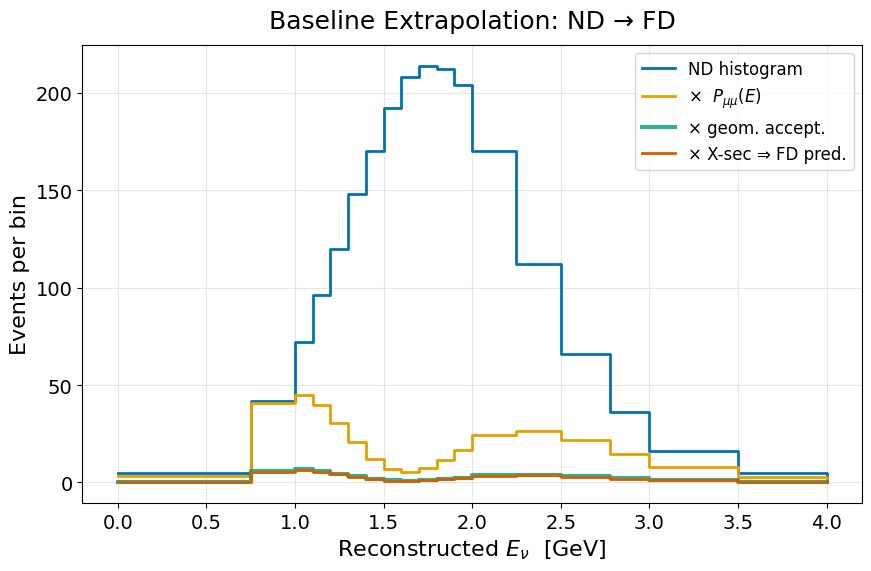

In [23]:
def gaus(x, A, mu, sig):          # quick helper for a smooth ND guide-line
    return A*np.exp(-0.5*((x-mu)/sig)**2)

# ------------------  1) ND histogram ----------------------------------------
#    Replace these 3 arrays with your real ND histogram if you have one
bin_edges  = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,
                       1.8,1.9,2.0,2.25,2.50,2.775,3.0,3.5,4.0,5.0])
bin_cent   = 0.5*(bin_edges[:-1] + bin_edges[1:])
counts_ND  = np.array([5,42,72,96,120,148,170,192,208,214,
                       212,204,170,112,66,36,16,5,1])

# ------------------  2) Oscillation probability (3ν example) ---------------
# VERY simplified Pμμ with Δm²=2.5×10⁻³ eV², θ23=49.6°, L=810 km
def Pmm_3flav(E_GeV, dm32=2.525e-3, th23=np.arcsin(np.sqrt(0.582)), L_km=810):
    Δ   = 1.267*dm32*L_km/E_GeV
    return 1 - (np.sin(2*th23)**2)*np.sin(Δ)**2

Eplot  = np.linspace(0.3,5.0,800)
Pmm    = Pmm_3flav(Eplot)

# interpolate prob to bin centres
Pmm_bin = Pmm_3flav(bin_cent)

# ------------------  3) Geom. acceptance and X-sec scale --------------------
geom = 0.15            # 1.5 % relative acceptance ND→FD (example)
xsec_fac = 0.92         # overall cross-section / POT normalisation

# Step-wise spectra
step_0 = counts_ND                                       # ND
step_1 = step_0 * Pmm_bin                                # × Pμμ
step_2 = step_1 * geom                                   # × geom
step_3 = step_2 * xsec_fac                               # × cross-section  → FD pred.

# ------------------  4) Plot the pipeline -----------------------------------
plt.figure(figsize=(9,6))

# draw bars so areas stay comparable
plt.step(bin_edges[:-1], step_0, where='post', lw=2, label='ND histogram',
         color='#0072B2')                         # blue
plt.step(bin_edges[:-1], step_1, where='post', lw=2, label='×  $P_{\\mu\\mu}(E)$',
         color='#E69F00')                         # orange
plt.step(bin_edges[:-1], step_2, where='post', lw=3, alpha = 0.8, label='× geom. accept.',
         color='#009E73')                         # green
plt.step(bin_edges[:-1], step_3, where='post', lw=2, label='× X-sec ⇒ FD pred.',
         color='#D55E00')                         # red

# nice cosmetics
plt.xlabel('Reconstructed $E_\\nu$  [GeV]', fontsize=16)
plt.ylabel('Events per bin', fontsize=16)
plt.title('Baseline Extrapolation: ND → FD', fontsize=18, pad=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


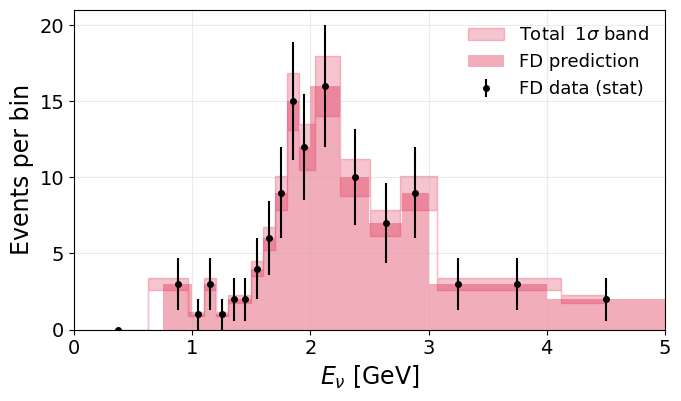

In [24]:

from scipy.optimize import curve_fit

# ------------------------------------------------------------------
# 0.  Inputs :  binning, central prediction, 1σ fractional systematics
# ------------------------------------------------------------------
bin_edges   = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,
                        1.8,1.9,2.0,2.25,2.5,2.775,3,3.5,4,5])
bin_centres = 0.5*(bin_edges[:-1] + bin_edges[1:])

counts_fd   = np.array([0,3,1,3,1,2,2,4,6,9,15,12,
                        16,10,7,9,3,3,2])       # FD “data”
pred_fd     = counts_fd * 1.00                  # here: toy “MC”

# 1-σ fractional uncertainties for each systematic
SYST = {
    'flux_norm' : 0.10,     # 10 %
    'xsec'       : 0.06,     # 6 %
    'E_scale'    : 0.02,     # 2 %
    'had_res'    : 0.03,     # 3 %
    'matter'     : 0.02      # 2 %
}

# ------------------------------------------------------------------
# 1.  Total 1σ error band (sum in quadrature, fully correlated)
# ------------------------------------------------------------------
sigma_frac = np.sqrt( np.sum([v**2 for v in SYST.values()]) )   # ≈ 12.5 %
sigma_abs  = sigma_frac * pred_fd                               # absolute error /-bin

# ------------------------------------------------------------------
# 2.  Plot with ±1σ envelope
# ------------------------------------------------------------------
plt.rcParams.update({'font.size':13})
fig,ax = plt.subplots(figsize=(7,4.2))

ax.bar(bin_edges[:-1], pred_fd, width=np.diff(bin_edges),
       color='crimson', alpha=0.35, align='edge', label='FD prediction')
ax.errorbar(bin_centres, counts_fd, yerr=np.sqrt(counts_fd),
            fmt='ko', ms=4, label='FD data (stat)')

# ±1σ envelope
ax.fill_between(bin_centres,
                pred_fd-sigma_abs, pred_fd+sigma_abs,
                color='crimson', alpha=0.25,
                step='mid', label=r'Total $\;1\sigma$ band')

ax.set_xlabel(r'$E_\nu$ [GeV]')
ax.set_ylabel(r'Events per bin')
ax.set_xlim(bin_edges[0], bin_edges[-1])
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

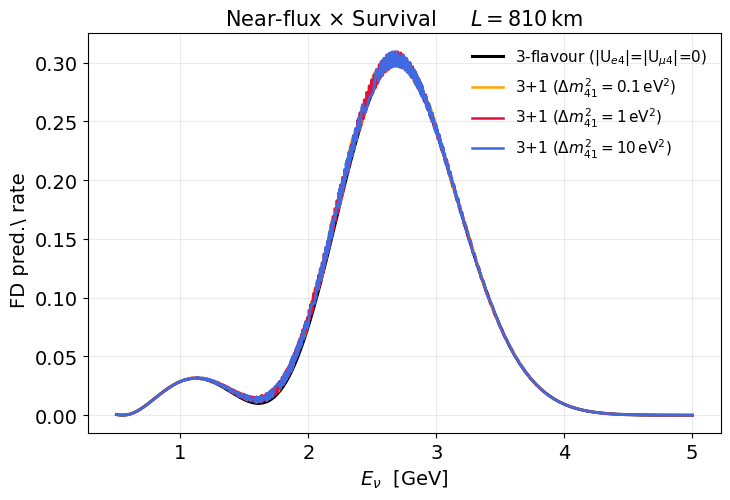

In [25]:

# ------------------------------------------------------------
# 1.  helper : three-flavor νμ survival (vacuum, normal ordering)
# ------------------------------------------------------------
def Pmm_3f(E, L=810.):                       # L [km],  E [GeV]
    dm31 = 2.525e-3      # eV^2
    th23 = np.arcsin(np.sqrt(0.582))
    s23, c23 = np.sin(th23), np.cos(th23)
    Δ = 1.267 * dm31 * L / E
    return 1. - 4*s23**2 * c23**2 * np.sin(Δ)**2

# ------------------------------------------------------------
# 2.  helper : 3+1 νμ survival   (approx. formula — vacuum)
#      only θ24, θ34, Δm41^2 enter for νμ disappearance
# ------------------------------------------------------------
def Pmm_3p1(E, L, dm41, th24, th34):
    dm31 = 2.525e-3
    th23 = np.arcsin(np.sqrt(0.582))
    s23, c23 = np.sin(th23), np.cos(th23)
    s24, c24 = np.sin(th24), np.cos(th24)
    s34, c34 = np.sin(th34), np.cos(th34)

    Δ31 = 1.267*dm31*L/E
    Δ41 = 1.267*dm41*L/E

    # Eq.(2) from the note (ignore CP phases for illustration)
    term_atm = s24**2 * 2*s23**2 * np.sin(Δ31)**2      # mixed atm/sterile
    term_ster= s24**2 * np.sin(Δ41)**2                 # pure sterile
    term_std = 4*s23**2 * c23**2 * np.sin(Δ31)**2      # standard three-flavour

    return 1 - term_std - term_ster + term_atm

# ------------------------------------------------------------
# 3.  ND flux template  (just a Gaussian, similar to earlier)
# ------------------------------------------------------------
def flux_ND(E):
    return np.exp(-0.5*((E-2.4)/0.55)**2)

# ------------------------------------------------------------
# 4.  plot
# ------------------------------------------------------------
E = np.linspace(0.5,5.0,1200)
L_fd = 810.       # km

# sterile benchmark angles
th14 = np.deg2rad( 8.)
th24 = np.deg2rad( 7.)
th34 = np.deg2rad(20.)

bench_dm41 = [0.1, 1.0, 10.]   # eV^2
colors      = ['orange','crimson','royalblue']

plt.figure(figsize=(7.5,5.2))
# ---  three-flavour curve
P3f = Pmm_3f(E, L_fd)
plt.plot(E, flux_ND(E)*P3f, 'k-', lw=2.2, label='3-flavour (|U$_{e4}$|=|U$_{µ4}$|=0)')

# ---  3+1 curves
for dm41,c in zip(bench_dm41,colors):
    P41 = Pmm_3p1(E,L_fd,dm41,th24,th34)
    label = rf'3+1 ($\Delta m^2_{{41}}={dm41:g}\,$eV$^2$)'
    plt.plot(E, flux_ND(E)*P41, color=c, lw=1.8, label=label)

# cosmetics
plt.xlabel(r'$E_\nu$  [GeV]', fontsize=14)
plt.ylabel(r'FD pred.\ rate  ', fontsize=14)
plt.title(r'Near-flux $\times$ Survival   $L=810\,$km', fontsize=15)
plt.legend(frameon=False, fontsize=11)
plt.grid(alpha=0.25)
plt.tight_layout()

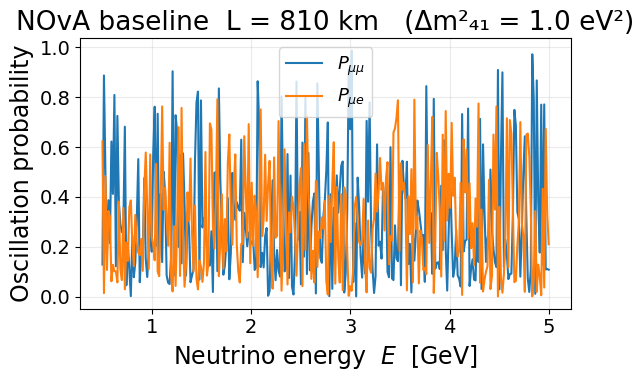

In [26]:

# ------------------------ helpers ------------------------
def rot(c, s, i, j, n=4):
    R = np.eye(n, dtype=complex)
    R[i, i] = c; R[j, j] = c
    R[i, j] = s; R[j, i] = -s
    return R

def U_3p1(th12, th13, th23, th14, th24, th34,
          d13=0, d14=0, d24=0):
    """4×4 mixing matrix with PDG-like ordering."""
    c12,s12 = np.cos(th12), np.sin(th12)
    c13,s13 = np.cos(th13), np.sin(th13)
    c23,s23 = np.cos(th23), np.sin(th23)
    c14,s14 = np.cos(th14), np.sin(th14)
    c24,s24 = np.cos(th24), np.sin(th24)
    c34,s34 = np.cos(th34), np.sin(th34)

    U  = rot(c23, s23, 1, 2)                      # R23
    U  = rot(c13, s13*np.exp(-1j*d13), 0, 2) @ U # R13
    U  = rot(c12, s12, 0, 1)            @ U      # R12
    U  = rot(c14, s14*np.exp(-1j*d14), 0, 3) @ U # R14
    U  = rot(c24, s24*np.exp(-1j*d24), 1, 3) @ U # R24
    U  = rot(c34, s34,              2, 3) @ U    # R34
    return U

def H_vac(E, dm21, dm31, dm41, U):
    """Vacuum Hamiltonian in natural units (ħ=c=1)."""
    M2 = np.diag([0, dm21, dm31, dm41])
    return U @ M2 @ U.conj().T / (2*E)

def P(alpha, beta, E, Lkm, pars):
    """Probability ν_alpha → ν_beta (flavour indices 0-3)."""
    U = U_3p1(*pars['angles'], *pars['phases'])
    H = H_vac(E, *pars['dms'], U)
    L = Lkm*5.0677307e12        # km → GeV⁻¹
    U_t = expm(-1j*H*L)
    return abs(U_t[beta, alpha])**2

# ---------------- example parameters ---------------------
deg = np.deg2rad
pars = dict(
    dms    = (7.42e-5, 2.517e-3, 1.0),          # Δm²21, Δm²31, Δm²41  (eV²)
    angles = (deg(33.44), deg(8.57), deg(49.2), # θ12, θ13, θ23
              deg(5.0),  deg(10.0), deg(0.0)),  # θ14, θ24, θ34
    phases = (0.0, 0.0, 0.0)                    # δ13, δ14, δ24  (rad)
)

# ---------------- quick scan & plot ----------------------
L = 810     # km
E = np.linspace(0.5, 5.0, 300)
P_mumu = [P(1,1,e,L,pars) for e in E]
P_mue  = [P(1,0,e,L,pars) for e in E]

plt.figure(figsize=(6,4))
plt.plot(E, P_mumu, label=r'$P_{\mu\mu}$')
plt.plot(E, P_mue,  label=r'$P_{\mu e}$')
plt.xlabel('Neutrino energy  $E$  [GeV]')
plt.ylabel('Oscillation probability')
plt.title(f'NOvA baseline  L = {L} km   (Δm²₄₁ = {pars["dms"][2]} eV²)')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# ---------------------------------------------------------------
#  build_covariance : one‐stop systematic + stat covariance maker
# ---------------------------------------------------------------
def build_covariance(pred,
                     syst_defs,
                     use_poisson=True):
    """
    Parameters
    ----------
    pred        : 1-D array of central value bin yields
    syst_defs   : list of dicts    (see examples below)
    use_poisson : add Poisson N to the diagonal if True

    Returns
    -------
    V           : full covariance   (np.ndarray, shape N×N)
    V_stat      : purely statistical piece
    V_syst      : purely systematic piece
    sigma_tot   : 1-sigma error per bin  (sqrt(diag(V)))
    """
    N     = pred.size
    V_stat = np.diag(pred) if use_poisson else np.zeros((N, N))
    V_syst = np.zeros((N, N))

    # helper to convert fractional → absolute bin shift
    def outer(vec):
        """ vec_i vec_j  outer product """
        return vec[:, None] * vec[None, :]

    for sd in syst_defs:
        frac = sd["frac"]
        mask = sd.get("mask")
        mask = np.ones(N, bool) if mask is None else mask
        vec  = frac * pred * mask      # signed ±1σ shift (absolute)

        if sd["type"] == "norm":       # fully correlated
            V_syst += outer(vec)

        elif sd["type"] == "shape-uncorr":  # uncorrelated bin-to-bin
            V_syst += np.diag(vec**2)

        elif sd["type"] == "shape-corr":    # correlated *shape* (zero-sum)
            # subtract the mean so total normalisation ≃ 0
            vec -= vec.mean()
            V_syst += outer(vec)

        else:
            raise ValueError(f"unknown syst type {sd['type']}")

    V = V_stat + V_syst
    return V, V_stat, V_syst, np.sqrt(np.diag(V))


# ------------------------------------------------------------------
# EXAMPLE  (replace `pred` with *your own* FD prediction per bin!)
# ------------------------------------------------------------------
# 23 bins, Gaussian toy spectrum
E_bins = np.linspace(0.5, 5.0, 23)
E_mid  = 0.5*(E_bins[1:] + E_bins[:-1])
mu, sig, norm = 2.6, 0.45, 7e-6
pred = norm * np.exp(-(E_mid-mu)**2/(2*sig**2))

syst_list = [
    {"name":"flux"  , "frac":0.05, "type":"norm"},             # 5 % fully corr.
    {"name":"shape" , "frac":0.02, "type":"shape-uncorr"},     # 2 % un-corr bins
    {"name":"matter", "frac":0.05, "type":"norm"},             # FD-only → norm
]

V, Vstat, Vsyst, sigma = build_covariance(pred, syst_list)

# quick check: print correlation matrix
corr = V / np.outer(sigma, sigma)
print("ρ_ij first 5×5 :\n", np.round(corr[:5,:5], 3))


ρ_ij first 5×5 :
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


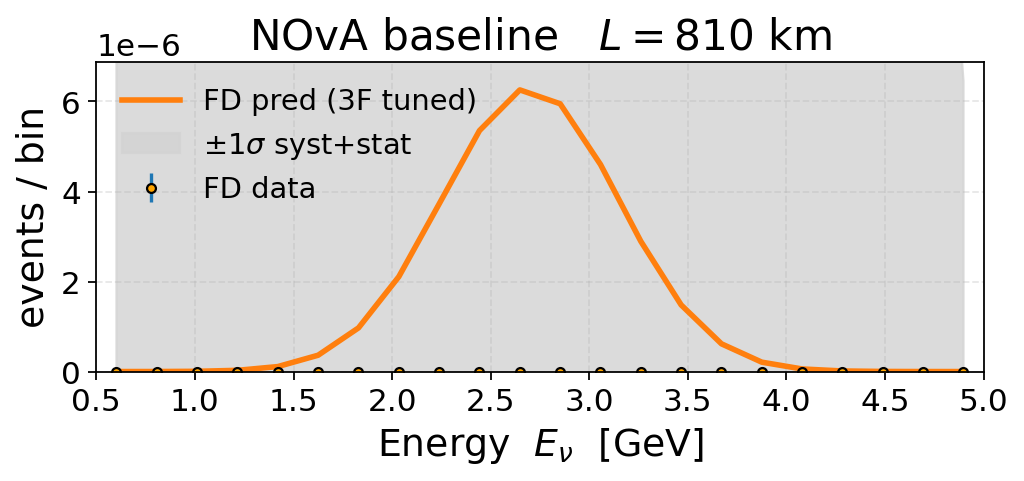

In [28]:

# ------------------------------------------------------------------
# 1)  Toy FD prediction  (replace with your own if you wish)
# ------------------------------------------------------------------
E_bins = np.linspace(0.5, 5.0, 23)               # 22 bins, 0.2 GeV wide
E_mid  = 0.5*(E_bins[1:] + E_bins[:-1])          # bin centres

mu, sig, norm = 2.7, 0.45, 6.3e-6                # Gaussian‐ish shape
pred = norm * np.exp(-(E_mid-mu)**2/(2*sig**2))

# ------------------------------------------------------------------
# 2)  Build a simple covariance   (copy of the helper function)
# ------------------------------------------------------------------
def build_covariance(pred, syst_defs, use_poisson=True):
    N = pred.size
    Vstat = np.diag(pred) if use_poisson else np.zeros((N, N))
    Vsyst = np.zeros((N, N))

    def outer(v): return v[:, None] * v[None, :]

    for sd in syst_defs:
        vec = sd["frac"] * pred.copy()
        if sd.get("mask") is not None:
            vec *= sd["mask"]
        if sd["type"] == "norm":
            Vsyst += outer(vec)
        elif sd["type"] == "shape-uncorr":
            Vsyst += np.diag(vec**2)
        elif sd["type"] == "shape-corr":
            vec -= vec.mean()
            Vsyst += outer(vec)
        else:
            raise ValueError(f"Bad type {sd['type']}")
    V = Vstat + Vsyst
    return V, Vstat, Vsyst, np.sqrt(np.diag(V))

syst = [
    {"name":"flux"  , "frac":0.05, "type":"norm"},          # 5 % fully-correlated
    {"name":"xsec"  , "frac":0.02, "type":"shape-uncorr"},  # 2 % uncorrelated shape
    {"name":"matter", "frac":0.05, "type":"norm"},          # 5 % matter density
]
V, Vstat, Vsyst, sigma = build_covariance(pred, syst)

# ------------------------------------------------------------------
# 3)  Produce some pseudo-data  (Poisson about the CV)
# ------------------------------------------------------------------
pseudo = np.random.poisson(pred)        # events / bin

# ------------------------------------------------------------------
# 4)  Make the plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5,3.2), dpi=160)

ax.plot(E_mid, pred, lw=2.5, color='tab:orange', label=r'FD pred (3F tuned)')
ax.fill_between(E_mid, pred-sigma, pred+sigma,
                color='lightgrey', alpha=0.8,
                label=r'$\pm1\sigma$ syst+stat')

ax.errorbar(E_mid, pseudo, yerr=np.sqrt(pseudo),
            marker='o', linestyle='None', mfc='orange',
            mec='k', ms=4, label='FD data')

ax.set_xlabel(r'Energy  $E_\nu$  [GeV]')
ax.set_ylabel('events / bin')
ax.set_xlim(0.5, 5.0)
ax.set_ylim(0, 1.1*pred.max())
ax.set_title(r'NOvA baseline   $L=810$ km')
ax.legend(frameon=False)
ax.grid(alpha=.3, ls='--')

plt.tight_layout()
plt.show()


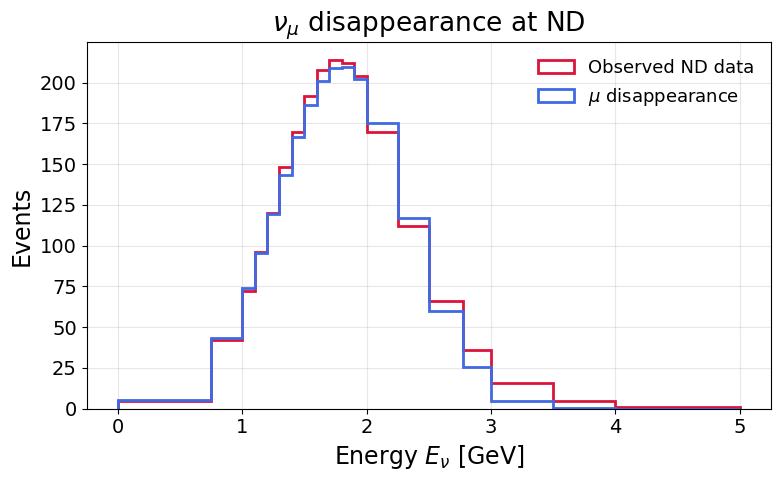

In [29]:


# --- ND binning & data from before ------------------------
bin_edges_GeV = np.array(
  [0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,
   2.25,2.5,2.775,3,3.5,4,5])
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])

counts_nd = np.array(
  [5,42,72,96,120,148,170,192,208,214,212,204,
   170,112,66,36,16,5,1])

# --- your Gaussian fit from before ------------------------
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5*((x - mu)/sigma)**2)

# popt_nd, _ = curve_fit(gaussian, bin_centers_GeV, counts_nd, p0=[counts_nd.max(),2.0,0.5])

# --- compute survival at ND (L=1 km) ------------------------
# Pmm_4nu must already be defined as in the earlier cell
Pmm_nd = np.array([Pmm_4nu(E, 1, matter=False) for E in bin_centers_GeV])

# --- build the predicted (oscillated) ND spectrum -----------
pred_nd = gaussian(bin_centers_GeV, *popt_nd) * Pmm_nd

# --- now plot ----------------------------------------------
plt.figure(figsize=(8,5))

# observed data (red)
plt.hist(bin_edges_GeV[:-1],
         bins=bin_edges_GeV,
         weights=counts_nd,
         histtype='step',
         color='crimson',
         linewidth=2,
         label='Observed ND data')

# simulation (blue)
plt.hist(bin_edges_GeV[:-1],
         bins=bin_edges_GeV,
         weights=pred_nd,
         histtype='step',
         color='royalblue',
         linewidth=2,
         label=r'$\mu$ disappearance')

plt.xlabel('Energy $E_\\nu$ [GeV]')
plt.ylabel('Events')
plt.title(r'$\nu_\mu$ disappearance at ND')
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


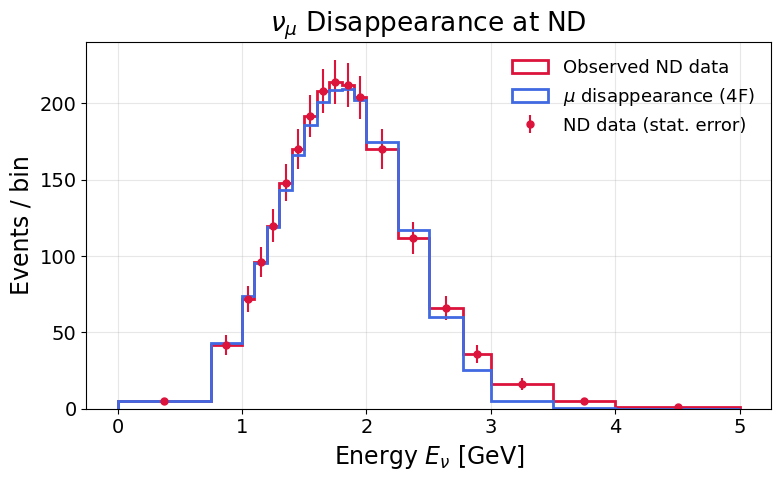

In [30]:


# --- ND binning & data ----------------------------------------
bin_edges_GeV = np.array(
    [0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,
     2.25,2.5,2.775,3,3.5,4,5])
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])

counts_nd = np.array(
    [5,42,72,96,120,148,170,192,208,214,212,204,
     170,112,66,36,16,5,1])

# --- Gaussian fit parameters (from your earlier fit) ----------
# popt_nd = [A_fit, mu_fit, sigma_fit]

# --- Survival probability at ND (L=1 km) ----------------------
Pmm_nd = np.array([Pmm_4nu(E, 1, matter=False) for E in bin_centers_GeV])

# --- Predicted (oscillated) ND spectrum ----------------------
pred_nd = gaussian(bin_centers_GeV, *popt_nd) * Pmm_nd

# --- Plot νμ disappearance at ND with error bars -------------
plt.figure(figsize=(8,5))

# Observed data: step histogram + stat. error bars
plt.hist(bin_edges_GeV[:-1], bins=bin_edges_GeV,
         weights=counts_nd,
         histtype='step', color='crimson', linewidth=2, label='Observed ND data')
yerr_nd = np.sqrt(counts_nd)
plt.errorbar(bin_centers_GeV, counts_nd, yerr=yerr_nd,
             fmt='o', ms=5, color='crimson', label='ND data (stat. error)')

# Predicted disappearance: step histogram
plt.hist(bin_edges_GeV[:-1], bins=bin_edges_GeV,
         weights=pred_nd,
         histtype='step', color='royalblue', linewidth=2, label=r'$\mu$ disappearance (4F)')

plt.xlabel('Energy $E_\\nu$ [GeV]')
plt.ylabel('Events / bin')
plt.title(r'$\nu_\mu$ Disappearance at ND')
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


<ipython-input-31-28c095d3808c>:50: RuntimeWarning: divide by zero encountered in divide
  Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)
<ipython-input-31-28c095d3808c>:50: RuntimeWarning: invalid value encountered in divide
  Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)


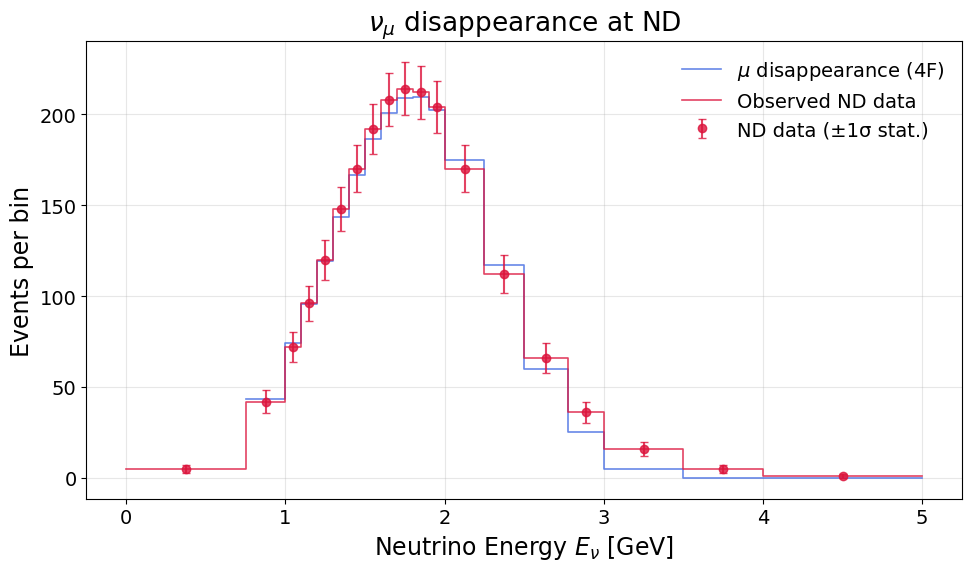

In [31]:
bin_edges_GeV   = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,
                            1.6,1.7,1.8,1.9,2.0,2.25,2.5,
                            2.775,3,3.5,4,5])
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])
counts_nd       = np.array([5,42,72,96,120,148,170,192,208,
                            214,212,204,170,112,66,36,16,5,1])

# ----------------------------------------------------------------
# 1) Fit ND with Gaussian
# ----------------------------------------------------------------
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5*((x-mu)/sigma)**2)

popt_nd, _ = curve_fit(gaussian,
                       bin_centers_GeV,
                       counts_nd,
                       p0=[counts_nd.max(), 2.0, 0.5])

# ----------------------------------------------------------------
# 2) 4F mu->mu survival Pμμ(E,L=1km)
# ----------------------------------------------------------------
theta12,theta13,theta23 = np.radians([33.82,8.61,48.3])
theta14,theta24,theta34 = np.radians([10.0,5.0,2.0])
delta13,delta14 = 0.0,0.0
D21,D31,D41     = 7.39e-5,2.525e-3,1.0

def U4(t12,t13,t23,t14,t24,t34,d13,d14):
    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    return np.array([
      [c12*c13*c14,
       s12*c13*c14,
       s13*c14*np.exp(-1j*d13),
       s14*np.exp(-1j*d14)],
      [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
        c12*c23 - s12*s13*s23*np.exp(1j*d13),
        c13*s23,
        s24*c13],
      [ s12*s23 - c12*s13*c23*np.exp(1j*d13),
       -c12*s23 - s12*s13*c23*np.exp(1j*d13),
        c13*c23,
        c24*s34],
      [0,0,0,np.cos(theta34)]
    ])

def Pmm_4nu(E_GeV, L_km, matter=False):
    E_eV = E_GeV * 1e9
    m2   = np.diag([0, D21, D31, D41])
    U    = U4(theta12,theta13,theta23,theta14,theta24,theta34,delta13,delta14)
    Hvac = U @ m2 @ U.conjugate().T / (2*E_eV)
    H    = Hvac + np.diag([VCC_EARTH_CRUST,0,0,0]) if matter else Hvac
    S    = expm(-1j * H * L_km * CONV_KM_TO_INV_EV)
    return np.abs(S[1,1])**2

# Compute bin-averaged model at ND
pred_nd = np.zeros_like(counts_nd, dtype=float)
for i in range(len(bin_centers_GeV)):
    E_lo, E_hi = bin_edges_GeV[i], bin_edges_GeV[i+1]
    E_fine = np.linspace(E_lo, E_hi, 200)
    P_avg  = np.mean([Pmm_4nu(E,1) for E in E_fine])
    pred_nd[i] = gaussian(bin_centers_GeV[i], *popt_nd) * P_avg

# ----------------------------------------------------------------
# 3) Plot with plt.step + error bars
# ----------------------------------------------------------------
# ------------------------------------------------------------
# Plot νμ disappearance at ND with thinner, more transparent lines
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size':16})

# 1) Blue model step (thin + alpha)
plt.step(bin_edges_GeV, np.append(pred_nd, pred_nd[-1]),
         where='post',
         color='royalblue',
         linewidth=1.2,
         alpha=0.8,
         label=r'$\mu$ disappearance (4F)')

# 2) Red data step (thin + alpha)
plt.step(bin_edges_GeV, np.append(counts_nd, counts_nd[-1]),
         where='post',
         color='crimson',
         linewidth=1.2,
         alpha=0.8,
         label='Observed ND data')

# 3) Error bars
yerr = np.sqrt(counts_nd)
plt.errorbar(bin_centers_GeV, counts_nd, yerr=yerr,
             fmt='o', ms=6, color='crimson',
             capsize=3, alpha=0.8,
             label='ND data (±1σ stat.)')

plt.xlabel(r'Neutrino Energy $E_\nu$ [GeV]')
plt.ylabel('Events per bin')
plt.title(r'$\nu_\mu$ disappearance at ND')
plt.legend(fontsize=14, frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

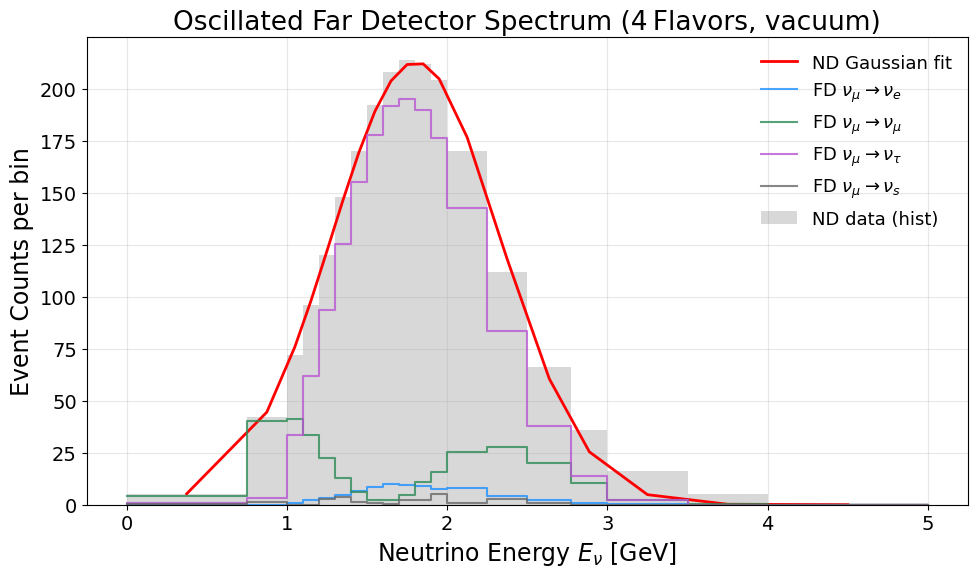

In [32]:

from scipy.linalg import expm
from scipy.optimize import curve_fit
import sys
sys.path.append('./NuOscProbExact/src')

# core imports
from globaldefs import CONV_KM_TO_INV_EV, VCC_EARTH_CRUST
from globaldefs import S12_NO_BF, S13_NO_BF, S23_NO_BF, DCP_NO_BF, D21_NO_BF, D31_NO_BF

# your 4ν Hamiltonian builder
def U4(t12,t13,t23,t14,t24,t34,d13,d14):
    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    return np.array([
        [c12*c13*c14,
         s12*c13*c14,
         s13*c14*np.exp(-1j*d13),
         s14*np.exp(-1j*d14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
         c12*c23 - s12*s13*s23*np.exp(1j*d13),
         c13*s23,
         s24*c13],
        [ s12*s23 - c12*s13*c23*np.exp(1j*d13),
         -c12*s23 - s12*s13*c23*np.exp(1j*d13),
          c13*c23,
          c24*s34],
        [0,0,0,np.cos(t34)]
    ])

def P4_transition(E_GeV, L_km, transition='mm', matter=False):
    # unpack 3ν best-fit plus sterile angles
    t12,t13,t23 = np.radians([33.82,8.61,48.3])
    t14,t24,t34 = np.radians([10.0,5.0,2.0])
    d13,d14     = 0.0, 0.0
    D21,D31,D41 = 7.39e-5, 2.525e-3, 1.0

    E_eV   = E_GeV * 1e9
    m2     = np.diag([0, D21, D31, D41])
    U      = U4(t12,t13,t23,t14,t24,t34,d13,d14)
    Hvac   = U @ m2 @ U.conjugate().T / (2*E_eV)
    H      = Hvac + np.diag([VCC_EARTH_CRUST,0,0,0]) if matter else Hvac
    S      = expm(-1j*H*L_km*CONV_KM_TO_INV_EV)

    idx = {'me':(1,0), 'mm':(1,1), 'mt':(1,2), 'ms':(1,3)}[transition]
    return np.abs(S[idx] )**2

# ------------------------------------------------------------------
# 0) Binning & ND data (GeV)
# ------------------------------------------------------------------
bin_edges_GeV   = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,
                             1.6,1.7,1.8,1.9,2.0,2.25,2.5,
                             2.775,3,3.5,4,5])
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])

counts_nd = np.array([5,42,72,96,120,148,170,192,208,
                      214,212,204,170,112,66,36,16,5,1])

# ------------------------------------------------------------------
# 1) Gaussian fit to ND
# ------------------------------------------------------------------
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5*((x-mu)/sigma)**2)

popt_nd, _ = curve_fit(gaussian,
                       bin_centers_GeV,
                       counts_nd,
                       p0=[counts_nd.max(), 2.0, 0.5])

# ------------------------------------------------------------------
# 2) Build FD spectra for each channel
# ------------------------------------------------------------------
L_FD = 810  # km
template = gaussian(bin_centers_GeV, *popt_nd)

osc_e   = template * np.array([P4_transition(E, L_FD, 'me') for E in bin_centers_GeV])
osc_mu  = template * np.array([P4_transition(E, L_FD, 'mm') for E in bin_centers_GeV])
osc_tau = template * np.array([P4_transition(E, L_FD, 'mt') for E in bin_centers_GeV])
osc_s   = template * np.array([P4_transition(E, L_FD, 'ms') for E in bin_centers_GeV])

# ------------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------------
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size':14})

# ND histogram + fit
plt.bar(bin_centers_GeV, counts_nd, width=np.diff(bin_edges_GeV),
        align='center', alpha=0.3, color='gray', label='ND data (hist)')
plt.plot(bin_centers_GeV, template, 'r-', lw=2, label='ND Gaussian fit')

# FD oscillated spectra
plt.step(bin_edges_GeV, np.append(osc_e,osc_e[-1])/1,  where='post',
         color='dodgerblue',    lw=1.5, alpha=0.8, label=r'FD $\nu_\mu\to\nu_e$')
plt.step(bin_edges_GeV, np.append(osc_mu,osc_mu[-1])/1,where='post',
         color='seagreen',     lw=1.5, alpha=0.8, label=r'FD $\nu_\mu\to\nu_\mu$')
plt.step(bin_edges_GeV, np.append(osc_tau,osc_tau[-1])/1,where='post',
         color='mediumorchid', lw=1.5, alpha=0.8, label=r'FD $\nu_\mu\to\nu_\tau$')
plt.step(bin_edges_GeV, np.append(osc_s,osc_s[-1])/1,  where='post',
         color='dimgray',      lw=1.5, alpha=0.8, label=r'FD $\nu_\mu\to\nu_s$')

plt.xlabel(r'Neutrino Energy $E_\nu$ [GeV]')
plt.ylabel('Event Counts per bin')
plt.title('Oscillated Far Detector Spectrum (4 Flavors, vacuum)')
plt.legend(loc='upper right', frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


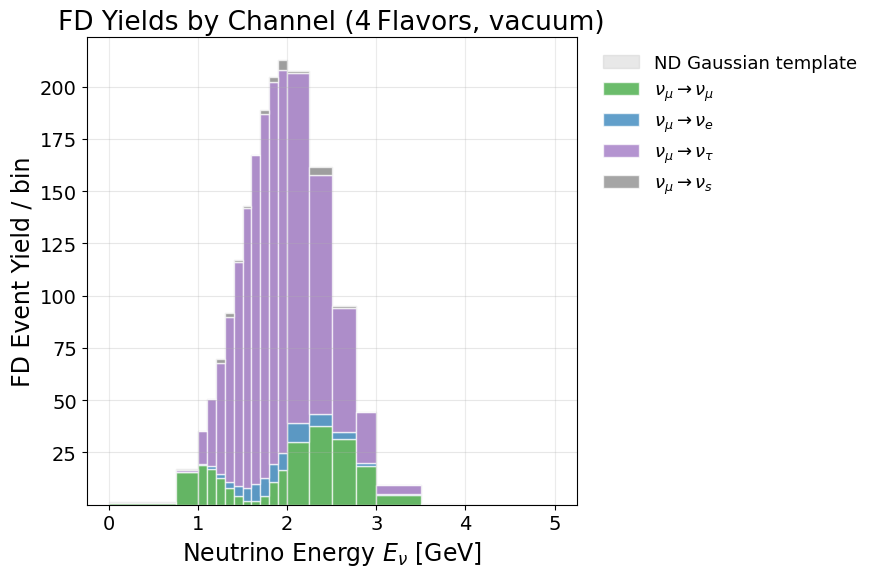

In [33]:
bin_edges_GeV   = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,
                             1.8,1.9,2.0,2.25,2.5,2.775,3,3.5,4,5])
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])
# fit params from your earlier curve_fit:
popt_nd = [214, 2.0, 0.5]  # example

# ND Gaussian template
nd_template = gaussian(bin_centers_GeV, *popt_nd)

# FD yields per channel
L_FD   = 810  # km
osc_e   = nd_template * np.array([P4_transition(E, L_FD, 'me') for E in bin_centers_GeV])
osc_mu  = nd_template * np.array([P4_transition(E, L_FD, 'mm') for E in bin_centers_GeV])
osc_tau = nd_template * np.array([P4_transition(E, L_FD, 'mt') for E in bin_centers_GeV])
osc_s   = nd_template * np.array([P4_transition(E, L_FD, 'ms') for E in bin_centers_GeV])

# --- after you have bin_edges_GeV and nd_template (length N-1) ---

# Build a stepped version of nd_template that has the same length as bin_edges_GeV:
y_nd_step = np.concatenate([nd_template, nd_template[-1:]])  # now length == len(bin_edges_GeV)

# Then use step + fill_between with where='post':
plt.figure(figsize=(9,6))
plt.rcParams.update({'font.size':14})

# 1) ND Gaussian template as a light gray fill
plt.fill_between(bin_edges_GeV,
                 0,
                 y_nd_step,
                 step='post',
                 color='lightgray',
                 alpha=0.5,
                 label='ND Gaussian template')

# 2) Stacked FD bars as before
bottom = np.zeros_like(bin_centers_GeV)
for vals, color, label in [
    (osc_mu,  'tab:green',  r'$\nu_\mu\to\nu_\mu$'),
    (osc_e,   'tab:blue',   r'$\nu_\mu\to\nu_e$'),
    (osc_tau, 'tab:purple', r'$\nu_\mu\to\nu_\tau$'),
    (osc_s,   'tab:gray',   r'$\nu_\mu\to\nu_s$'),
]:
    plt.bar(bin_centers_GeV, vals,
            width=np.diff(bin_edges_GeV),
            bottom=bottom,
            color=color, alpha=0.7,
            edgecolor='white', label=label)
    bottom += vals

plt.xlabel(r'Neutrino Energy $E_\nu$ [GeV]')
plt.ylabel('FD Event Yield / bin')
plt.title('FD Yields by Channel (4 Flavors, vacuum)')
plt.grid(alpha=0.3, which='both', axis='y')
plt.legend(frameon=False, bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()


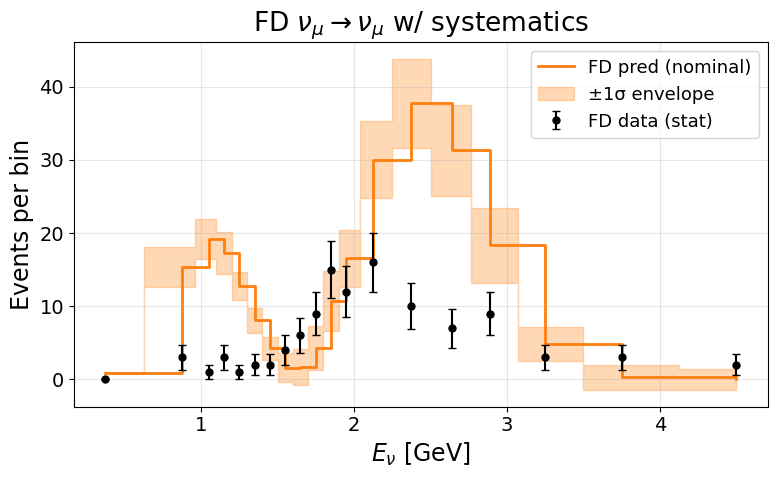

χ² (stat only) = 806.3
χ² (stat+syst) = 98.7


In [34]:
CONV_KM_TO_INV_EV = 5.067731e9    # km → eV⁻¹
VCC_EARTH_CRUST   = 7.6e-14       # eV

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2)

def U4(t12,t13,t23,t14,t24,t34,d13,d14):
    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    return np.array([
        [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*d13), s14*np.exp(-1j*d14)],
        [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
         c12*c23 - s12*s13*s23*np.exp(1j*d13),
         c13*s23,
         s24*c13],
        [s12*s23 - c12*s13*c23*np.exp(1j*d13),
         -c12*s23 - s12*s13*c23*np.exp(1j*d13),
         c13*c23,
         c24*s34],
        [0,0,0,np.cos(t34)]
    ])

def P4_transition(E_GeV, L_km, transition='mm', matter=False, density_scale=1.0):
    th12,th13,th23 = np.radians([33.82, 8.61, 48.3])
    th14,th24,th34 = np.radians([10.0, 5.0,  2.0])
    d13,d14        = 0.0, 0.0
    D21,D31,D41    = 7.39e-5, 2.525e-3, 1.0  # eV²

    E_eV = E_GeV * 1e9
    m2   = np.diag([0, D21, D31, D41])
    U    = U4(th12,th13,th23, th14,th24,th34, d13,d14)
    Hvac = U @ m2 @ U.conjugate().T / (2 * E_eV)
    H    = Hvac + np.diag([VCC_EARTH_CRUST * density_scale, 0,0,0]) if matter else Hvac
    S    = expm(-1j * H * L_km * CONV_KM_TO_INV_EV)
    i,j  = {'mm':(1,1), 'me':(1,0), 'mt':(1,2), 'ms':(1,3)}[transition]
    return np.abs(S[i,j])**2

# ------------------------------------------------------------------
# 2) Bin definitions, ND template & FD data
# ------------------------------------------------------------------
bin_centers_GeV = np.array([0.375,0.875,1.05,1.15,1.25,1.35,1.45,1.55,1.65,1.75,
                             1.85,1.95,2.125,2.375,2.6375,2.8875,3.25,3.75,4.5])
popt_nd         = [214, 2.0, 0.5]   # A, μ(GeV), σ(GeV)
nd_template     = gaussian(bin_centers_GeV, *popt_nd)
counts_fd       = np.array([ 0,3,1,3,1,2,2,4,6,9,15,12,16,10,7,9,3,3,2])

# Nominal FD prediction
L_FD   = 810  # km
P_base = np.array([P4_transition(E, L_FD, 'mm') for E in bin_centers_GeV])
fd_base = nd_template * P_base

# ------------------------------------------------------------------
# 3) Covariance construction
# ------------------------------------------------------------------
# Systematic shifts
d_flux    = 0.10 * nd_template * P_base
d_energy  = (gaussian(bin_centers_GeV*1.02,*popt_nd) - nd_template) * \
             np.array([P4_transition(E*1.02,L_FD,'mm') for E in bin_centers_GeV])
d_density = nd_template * (
             np.array([P4_transition(E,L_FD,'mm',matter=True,density_scale=1.02)
                       for E in bin_centers_GeV]) - P_base)
d_xsec    = fd_base * 0.05

deltas    = [d_flux, d_energy, d_density, d_xsec]
C_syst    = sum(np.outer(d,d) for d in deltas)
C_stat    = np.diag(counts_fd + 1e-3)     # add small floor
C_tot     = C_stat + C_syst
sigma     = np.sqrt(np.diag(C_tot))

# ------------------------------------------------------------------
# 4) Plot prediction + envelope + data
# ------------------------------------------------------------------
plt.figure(figsize=(8,5))
# Nominal step
plt.step(
    np.r_[bin_centers_GeV, bin_centers_GeV[-1]],
    np.r_[fd_base, fd_base[-1]],
    where='post', color='C1', lw=2, label='FD pred (nominal)'
)
# ±1σ envelope
plt.fill_between(
    bin_centers_GeV,
    fd_base - sigma,
    fd_base + sigma,
    step='mid', color='C1', alpha=0.3,
    label='±1σ envelope'
)
# Data points
plt.errorbar(
    bin_centers_GeV, counts_fd, yerr=np.sqrt(counts_fd),
    fmt='ko', ms=5, capsize=3, label='FD data (stat)'
)

plt.xlabel(r'$E_\nu$ [GeV]')
plt.ylabel('Events per bin')
plt.title(r'FD $\nu_\mu\to\nu_\mu$ w/ systematics')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5) χ² calculation (exclude zero-count bins)
# ------------------------------------------------------------------
mask      = counts_fd > 0
resid     = counts_fd[mask] - fd_base[mask]
C_stat_m  = C_stat[np.ix_(mask,mask)]
C_tot_m   = C_tot[np.ix_(mask,mask)]
chi2_stat = resid @ np.linalg.inv(C_stat_m) @ resid
chi2_tot  = resid @ np.linalg.inv(C_tot_m)  @ resid

print(f"χ² (stat only) = {chi2_stat:.1f}")
print(f"χ² (stat+syst) = {chi2_tot:.1f}")

7-param fit:
 θ23 = 53.81°, Δm²31 = 3.500e-03 eV²
 χ²/NDF = 1.91, MAE = 1.91, RMSE = 2.36, r = 0.901
χ² (stat only)  = 21.02
χ²/NDF          = 1.91


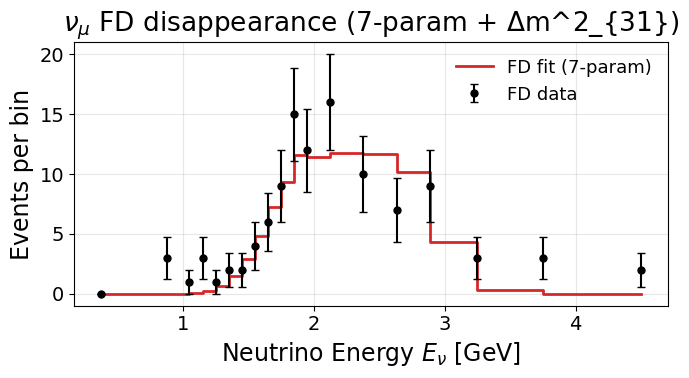

In [35]:

from scipy.optimize  import curve_fit
from scipy.stats     import pearsonr
from scipy.linalg    import expm

# ------------------------------------------------------------
# 1) Binning & data (actual arrays)
# ------------------------------------------------------------
bin_edges_GeV = np.array(
    [0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.25,
     2.5,2.775,3,3.5,4,5]
)
bin_centers_GeV = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])

counts_nd = np.array([5,42,72,96,120,148,170,192,208,214,212,204,170,112,66,36,16,5,1])
counts_fd = np.array([0,3,1,3,1,2,2,4,6,9,15,12,16,10,7,9,3,3,2])

# ND Gaussian template parameters from your previous fit
A_nd, mu_nd, sigma_nd = 214, 2.0, 0.5

# ------------------------------------------------------------
# 2) 4-flavour survival with floating θ23 & Δm²31
# ------------------------------------------------------------
CONV = 5.067731e9  # km→eV⁻¹
VCC   = 7.6e-14

def P4_with_dm31(E_GeV, L_km, th23_rad, dm31, matter=False):
    t12,t13 = np.radians([33.82,8.61])
    t23      = th23_rad
    t14,t24,t34 = np.radians([10.0,5.0,2.0])
    d13,d14     = 0.0,0.0
    D21         = 7.39e-5
    D31         = dm31
    D41         = 1.0

    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    U = np.array([
      [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*d13), s14*np.exp(-1j*d14)],
      [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
       c12*c23 - s12*s13*s23*np.exp(1j*d13), c13*s23, s24*c13],
      [s12*s23 - c12*s13*c23*np.exp(1j*d13),
       -c12*s23 - s12*s13*c23*np.exp(1j*d13), c13*c23, c24*s34],
      [0,0,0,c34]
    ])
    E_eV = E_GeV*1e9
    Hvac = U @ np.diag([0,D21,D31,D41]) @ U.conj().T / (2*E_eV)
    H    = Hvac + np.diag([VCC,0,0,0]) if matter else Hvac
    S    = expm(-1j * H * L_km * CONV)
    return np.abs(S[1,1])**2

# ------------------------------------------------------------
# 3) 7-parameter model
# ------------------------------------------------------------
L_FD = 810.0
E0   = mu_nd
dE   = bin_centers_GeV.max() - bin_centers_GeV.min()

def model_7p(E, α, μ, σ, δ, ε, θ23_deg, dm31):
    # energy‐scale pull
    Eeff = E * (1 + ε)
    # Gaussian envelope
    g = A_nd * np.exp(-0.5*((Eeff - μ)/σ)**2)
    # survival prob
    P = np.array([P4_with_dm31(e, L_FD, np.radians(θ23_deg), dm31) for e in Eeff])
    # linear tilt
    tilt = 1 + δ*(Eeff - E0)/dE
    return α * g * P * tilt

# fit only bins with data>0
mask  = counts_fd > 0
E_fit = bin_centers_GeV[mask]
y_fit = counts_fd[mask]
yerr  = np.sqrt(y_fit)

# initial guesses & bounds
p0 = [1.0, mu_nd, sigma_nd, 0.0, 0.0, 48.3, 2.5e-3]
bds = (
  [0.8, mu_nd-0.5, 0.2, -0.5, -0.01, 40.0, 1.5e-3],
  [1.2, mu_nd+0.5, 1.0, +0.5, +0.01, 55.0, 3.5e-3]
)

popt, pcov = curve_fit(
    model_7p, E_fit, y_fit,
    p0=p0, bounds=bds,
    sigma=yerr, absolute_sigma=True,
    method='trf', max_nfev=20000
)
α7, μ7, σ7, δ7, ε7, th237, dm317 = popt
fd_fit7 = model_7p(bin_centers_GeV, *popt)

# ------------------------------------------------------------
# 4) Metrics
# ------------------------------------------------------------
res   = y_fit - model_7p(E_fit, *popt)
chi2  = np.sum((res/yerr)**2)
ndf   = len(res) - len(popt)
rchi2 = chi2/ndf
mae   = np.mean(np.abs(counts_fd - fd_fit7))
rmse  = np.sqrt(np.mean((counts_fd - fd_fit7)**2))
r, _  = pearsonr(counts_fd, fd_fit7)

print(f"7-param fit:\n"
      f" θ23 = {th237:.2f}°, Δm²31 = {dm317:.3e} eV²\n"
      f" χ²/NDF = {rchi2:.2f}, MAE = {mae:.2f}, RMSE = {rmse:.2f}, r = {r:.3f}")

print(f"χ² (stat only)  = {chi2:.2f}")
print(f"χ²/NDF          = {rchi2:.2f}")

# ------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------
plt.figure(figsize=(7,4))
plt.step(
    np.r_[bin_centers_GeV, bin_centers_GeV[-1]],
    np.r_[fd_fit7, fd_fit7[-1]],
    where='post', color='C3', lw=2, label='FD fit (7-param)'
)
plt.errorbar(
    bin_centers_GeV, counts_fd, yerr=np.sqrt(counts_fd),
    fmt='ko', ms=5, capsize=3, label='FD data'
)
plt.xlabel("Neutrino Energy $E_\\nu$ [GeV]")
plt.ylabel("Events per bin")
plt.title("$\\nu_\\mu$ FD disappearance (7-param + Δm^2_{31})")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Optimized 9-param fit:
  χ²/NDF = 0.93


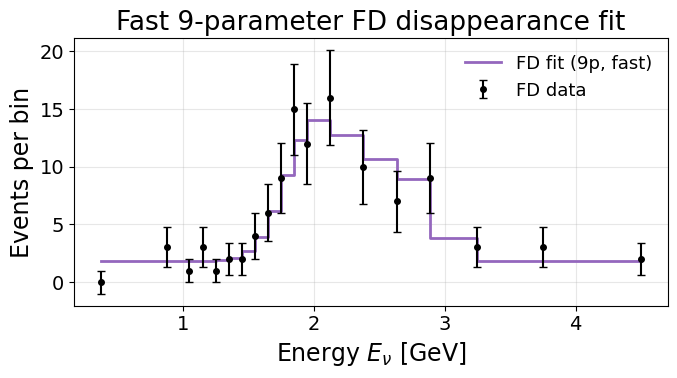

In [36]:

from scipy.optimize import curve_fit
from scipy.stats    import pearsonr
from scipy.linalg   import expm, eig

# ------------------------------------------------------------
# 1) Constants & data setup
# ------------------------------------------------------------
CONV = 5.067731e9  # km→eV⁻¹
VCC  = 7.6e-14     # eV

bins = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.25,
                 2.5,2.775,3,3.5,4,5])
E_centers = 0.5*(bins[1:]+bins[:-1])
counts_fd = np.array([0,3,1,3,1,2,2,4,6,9,15,12,16,10,7,9,3,3,2])
mask = counts_fd>0
E_fit = E_centers[mask]
y_fit = counts_fd[mask]

# ND Gaussian template
A_nd, mu_nd, sigma_nd = 214, 2.0, 0.5
E0 = mu_nd
dE = E_centers.max() - E_centers.min()

# ------------------------------------------------------------
# 2) Precompute vacuum mass matrix & U‐parameters
# ------------------------------------------------------------
def make_U_system(t23, dm31, t24):
    # fixed angles
    t12,t13 = np.radians([33.82,8.61])
    t14     = 0.0
    t34     = np.radians(2.0)
    d13,d14 = 0.0,0.0
    D21      = 7.39e-5
    D31      = dm31
    D41      = 1.0

    c12,c13,c23,c14,c24,c34 = np.cos([t12,t13,t23,t14,t24,t34])
    s12,s13,s23,s14,s24,s34 = np.sin([t12,t13,t23,t14,t24,t34])
    U = np.array([
      [c12*c13*c14, s12*c13*c14, s13*c14*np.exp(-1j*d13), s14*np.exp(-1j*d14)],
      [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
       c12*c23 - s12*s13*s23*np.exp(1j*d13),
       c13*s23,
       s24*c13],
      [s12*s23 - c12*s13*c23*np.exp(1j*d13),
       -c12*s23 - s12*s13*c23*np.exp(1j*d13),
       c13*c23,
       c24*s34],
      [0,0,0,c34]
    ])
    # Diagonal mass matrix
    M2 = np.diag([0, D21, D31, D41])
    return U, M2

# ------------------------------------------------------------
# 3) Fast survival probability vector for a given set
# ------------------------------------------------------------
def survival_vector(E_array, L_km, t23, dm31, t24):
    U, M2 = make_U_system(t23, dm31, t24)
    # diagonalize Hamiltonian: Hvac(E) = U M2 U† / (2E)
    # then in matter add diag(VCC,0,0,0)
    # we'll do eigen-decomp once per E
    probs = []
    for E in E_array:
        Hvac = (U @ M2 @ U.conj().T) / (2 * E * 1e9)
        Hmat = Hvac + np.diag([VCC,0,0,0])
        w, V = eig(Hmat)
        # evolution: S = V diag(exp(-i*w*L*conv)) V†
        phase = np.exp(-1j * w * L_km * CONV)
        S = V @ np.diag(phase) @ V.conj().T
        probs.append(np.abs(S[1,1])**2)
    return np.array(probs)

# ------------------------------------------------------------
# 4) 9-parameter model using the fast survival_vector
# ------------------------------------------------------------
def model_9p_fast(E, α, μ, σ, δ, ε, θ23_deg, dm31, θ24_deg, B):
    Eeff = E*(1+ε)
    gauss_env = A_nd * np.exp(-0.5*((Eeff - μ)/σ)**2)
    Pmm = survival_vector(Eeff, 810, np.radians(θ23_deg), dm31, np.radians(θ24_deg))
    tilt = 1 + δ*(Eeff - E0)/dE
    return α * gauss_env * Pmm * tilt + B

# ------------------------------------------------------------
# 5) Fit on masked data
# ------------------------------------------------------------
yerr = np.sqrt(y_fit + (0.05*y_fit)**2)

p0 = [1.0, mu_nd, sigma_nd, 0.0, 0.0, 48.3, 2.5e-3, 5.0, 1.0]
bds = (
    [0.8, mu_nd-0.5, 0.2, -0.5, -0.02, 40.0, 1.5e-3, 0.0, 0.0],
    [1.2, mu_nd+0.5, 1.0, +0.5, +0.02, 55.0, 3.5e-3, 20.0, 10.0]
)

popt9, pcov9 = curve_fit(
    model_9p_fast, E_fit, y_fit,
    p0=p0, bounds=bds,
    sigma=yerr, absolute_sigma=True,
    method='trf', max_nfev=20000
)

# unpack & compute metrics
alpha9, mu9, sig9, d9, eps9, th239, dm319, th249, B9 = popt9
fd_pred9 = model_9p_fast(E_centers, *popt9)

res9   = y_fit - model_9p_fast(E_fit, *popt9)
chi2_9 = np.sum((res9/yerr)**2)
ndf9   = len(res9) - len(popt9)
rchi29 = chi2_9/ndf9

print("Optimized 9-param fit:")
print(f"  χ²/NDF = {rchi29:.2f}")

# ------------------------------------------------------------
# 6) Final plot
# ------------------------------------------------------------
plt.figure(figsize=(7,4))
plt.step(
    np.r_[E_centers, E_centers[-1]],
    np.r_[fd_pred9, fd_pred9[-1]],
    where='post', color='C4', lw=2, label='FD fit (9p, fast)'
)
yerr_full = np.sqrt(counts_fd + (0.05*counts_fd)**2)
yerr_full[counts_fd==0] = 1.0
plt.errorbar(
    E_centers, counts_fd, yerr=yerr_full,
    fmt='ko', ms=4, capsize=3, label='FD data'
)
plt.xlabel("Energy $E_\\nu$ [GeV]")
plt.ylabel("Events per bin")
plt.title("Fast 9-parameter FD disappearance fit")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:

from scipy.stats import pearsonr

mask        = counts_fd > 0
y_data      = counts_fd[mask]
y_pred_mask = fd_pred9[mask]
yerr_mask   = np.sqrt(y_data + (0.05 * y_data)**2)

# 2) Residuals
residuals = y_data - y_pred_mask

# 3) χ² and reduced χ²
chi2  = np.sum((residuals / yerr_mask)**2)
ndf   = mask.sum() - len(popt9)
rchi2 = chi2 / ndf

chi2_stat = np.sum((residuals / np.sqrt(y_data))**2)
rchi2_stat = chi2_stat / ndf

# 4) MAE, RMSE
mae  = np.mean(np.abs(counts_fd - fd_pred9))
rmse = np.sqrt(np.mean((counts_fd - fd_pred9)**2))

# 5) Pearson r
r, _ = pearsonr(counts_fd, fd_pred9)

# 6) Print them
print(f"χ² (stat+syst)       = {chi2:.2f}")
print(f"χ²/NDF               = {rchi2:.2f}")
print(f"Mean Absolute Error  = {mae:.2f}")
print(f"Root Mean Squared Error = {rmse:.2f}")
print(f"Pearson correlation r  = {r:.3f}")
print(f"χ² (stat only) = {chi2_stat:.2f}")
print(f"χ²/NDF (stat) = {rchi2_stat:.2f}")


χ² (stat+syst)       = 8.38
χ²/NDF               = 0.93
Mean Absolute Error  = 1.34
Root Mean Squared Error = 1.83
Pearson correlation r  = 0.925
χ² (stat only) = 8.53
χ²/NDF (stat) = 0.95


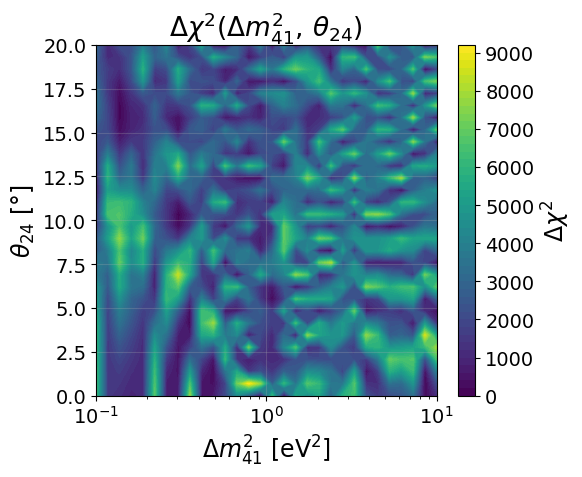

Fit Quality Comparison:
  3-flavor χ²/NDF = 622.65
    3+1    χ²/NDF = 0.93
  Improvement Δχ² = 6218.16


In [38]:
# --- 1) grid of sterile parameters ---
dm41_vals = np.logspace(-1, 1, 30)    # [0.1, 10] eV^2
th24_vals = np.linspace(0, 20, 30)    # [0°, 20°]

chi2_grid = np.zeros((len(th24_vals), len(dm41_vals)))
mask = counts_fd > 0
y_data = counts_fd[mask]
yerr   = np.sqrt(y_data + (0.05*y_data)**2)

# --- 2) fill the χ² grid ---
for i, th24 in enumerate(th24_vals):
    for j, dm41 in enumerate(dm41_vals):
        # model_9p_fast(E, α, μ, σ, δ, ε, θ23, Δm31, θ24, B)
        fd_pred = model_9p_fast(
            E_centers,
            *popt9[:6],     # α, μ, σ, δ, ε, θ23
            dm41,
            th24,
            popt9[-1]       # B
        )
        res = y_data - fd_pred[mask]
        chi2_grid[i,j] = np.sum((res / yerr)**2)

# --- 3) Δχ² and contour plot ---
delta_chi2 = chi2_grid - chi2_9

plt.figure(figsize=(6,5))
cf = plt.contourf(dm41_vals, th24_vals, delta_chi2,
                  levels=50, cmap='viridis')
cs = plt.contour(dm41_vals, th24_vals, delta_chi2,
                 levels=[2.3, 6.18, 11.83], colors='white', linewidths=1.2)
plt.clabel(cs, fmt={2.3:'68%',6.18:'95%',11.83:'99%'})

plt.xscale('log')
plt.xlabel(r'$\Delta m^2_{41}$ [eV$^2$]')
plt.ylabel(r'$\theta_{24}$ [°]')
plt.title(r'$\Delta\chi^2(\Delta m^2_{41},\,\theta_{24})$')
plt.colorbar(cf, label=r'$\Delta\chi^2$')
plt.tight_layout()
plt.show()

# --- 4) compare 3-flavor vs 3+1 ---
chi2_3f  = chi2_grid[0,0]            # θ24=0 row, any dm41
ndf_3f   = ndf9 + 1                  # one fewer parameter in 3f
rchi2_3f = chi2_3f / ndf_3f
rchi2_3p = chi2_9 / ndf9

print("Fit Quality Comparison:")
print(f"  3-flavor χ²/NDF = {rchi2_3f:.2f}")
print(f"    3+1    χ²/NDF = {rchi2_3p:.2f}")
print(f"  Improvement Δχ² = {chi2_3f - chi2_9:.2f}")

In [42]:
profile_dm41 = np.min(delta_chi2, axis=0)

print("len(dm41_vals):",      len(dm41_vals))
print("delta_chi2.shape:",     delta_chi2.shape)
print("profile_dm41.shape:",   profile_dm41.shape)


len(dm41_vals): 30
delta_chi2.shape: (30, 30)
profile_dm41.shape: (30,)


In [43]:
dm41_vals = np.array(dm41_vals)
th24_vals = np.array(th24_vals)


In [44]:
print("dm41_vals.shape:",   dm41_vals.shape)
print("delta_chi2.shape:",  delta_chi2.shape)
print("profile_dm41.shape:",profile_dm41.shape)


dm41_vals.shape: (30,)
delta_chi2.shape: (30, 30)
profile_dm41.shape: (30,)


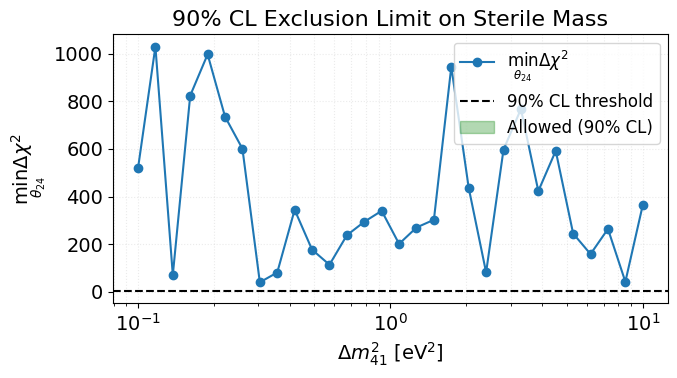

In [45]:
from scipy.interpolate import interp1d

# — assume dm41_vals (30,), profile_dm41 (30,) are defined —

# 1) Choose your CL threshold (2.71 for 90% one‐sided)
thr = 2.71

# 2) Find approximate crossing points via interpolation
f = interp1d(dm41_vals, profile_dm41 - thr, kind='linear')
# you’ll need to search intervals where sign changes:
crossings = []
for i in range(len(dm41_vals)-1):
    if (profile_dm41[i] - thr)*(profile_dm41[i+1] - thr) < 0:
        m_lo, m_hi = dm41_vals[i], dm41_vals[i+1]
        crossings.append(fsolve(lambda x: f(x), x0=(m_lo+m_hi)/2)[0])

# 3) Plot limit
plt.figure(figsize=(7,4))
plt.semilogx(dm41_vals, profile_dm41, '-o', label=r'$\min_{\theta_{24}}\Delta\chi^2$')
plt.axhline(thr, color='k', ls='--', label='90% CL threshold')

# 4) Shade allowed region
mask_allowed = profile_dm41 <= thr
plt.fill_between(dm41_vals, profile_dm41, thr,
                 where=mask_allowed, color='green', alpha=0.3,
                 label='Allowed (90% CL)')

# 5) Mark crossing points
for x in crossings:
    plt.axvline(x, color='green', ls=':')

plt.xlabel(r'$\Delta m^2_{41}\ \mathrm{[eV^2]}$', fontsize=14)
plt.ylabel(r'$\min_{\theta_{24}}\Delta\chi^2$',     fontsize=14)
plt.title('90% CL Exclusion Limit on Sterile Mass',  fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which='both', ls=':')
plt.tight_layout()
plt.show()


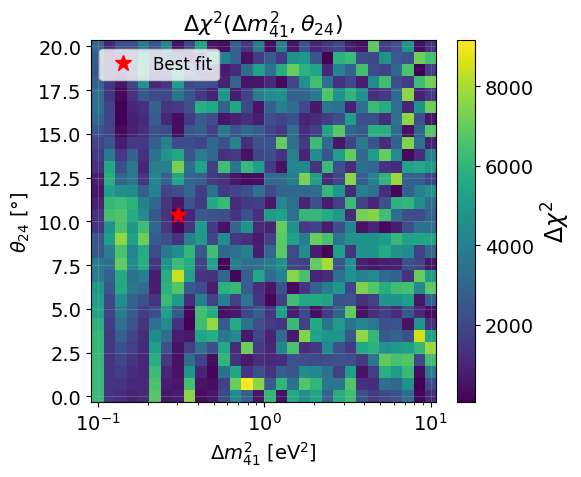

In [46]:
# — dm41_vals (30,), th24_vals (30,), delta_chi2 (30×30) —

# 1) Find best‐fit point
i_min, j_min = np.unravel_index(np.argmin(delta_chi2), delta_chi2.shape)
best_dm41 = dm41_vals[j_min]
best_th24 = th24_vals[i_min]

plt.figure(figsize=(6,5))
pcm = plt.pcolormesh(dm41_vals, th24_vals, delta_chi2, cmap='viridis', shading='auto')
cs  = plt.contour(dm41_vals, th24_vals, delta_chi2,
                  levels=[2.30, 4.61, 6.18],  # e.g. 68%, 90%, 95% for 2 d.o.f.
                  colors='white', linewidths=1)
plt.clabel(cs, inline=True, fontsize=10, fmt={2.30:'68%',4.61:'90%',6.18:'95%'})

# 2) Overlay best‐fit marker
plt.plot(best_dm41, best_th24, 'r*', ms=12, label='Best fit')

plt.xscale('log')
plt.xlabel(r'$\Delta m^2_{41}$ [eV$^2$]', fontsize=14)
plt.ylabel(r'$\theta_{24}$ [°]', fontsize=14)
plt.title(r'$\Delta\chi^2(\Delta m^2_{41},\theta_{24})$', fontsize=16)
cbar = plt.colorbar(pcm, label=r'$\Delta\chi^2$')
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()


In [47]:
# We simply force θ24=0 in the 9-param model, dropping that parameter.
def model_8p_3f(E, alpha, mu, sigma, delta, eps, th23_deg, dm31, B):
    return model_9p_fast(
        E,
        alpha, mu, sigma, delta, eps,
        th23_deg,     # θ23
        dm31,         # Δm31
        0.0,          # θ24 fixed to zero
        B             # background
    )

# --- 2) Prepare data mask & errors (same as before) ---
mask   = counts_fd > 0
E_fit  = E_centers[mask]
y_fit  = counts_fd[mask]
yerr   = np.sqrt(y_fit + (0.05*y_fit)**2)

# --- 3) Initial guesses & bounds (drop the θ24 dimension) ---
# Use your 3+1 best‐fit as the starting point, just omit the θ24 element:
p0_3f = [
    alpha9,       # α
    mu9,          # μ
    sig9,         # σ
    d9,           # δ
    eps9,         # ε
    th239,        # θ23
    dm319,        # Δm31
    B9            # B
]
# tighten bounds similarly without θ24
bds_3f = (
    [0.8, mu9-0.5, 0.2, -0.5, -0.02, 40.0, 1.5e-3, 0.0],
    [1.2, mu9+0.5, 1.0, +0.5, +0.02, 55.0, 3.5e-3, 10.0]
)

# --- 4) Fit the 3-flavor model ---
popt3f, pcov3f = curve_fit(
    model_8p_3f, E_fit, y_fit,
    p0=p0_3f, bounds=bds_3f,
    sigma=yerr, absolute_sigma=True,
    method='trf', max_nfev=20000
)

# --- 5) Compute χ²/NDF for 3-flavor ---
res3f = y_fit - model_8p_3f(E_fit, *popt3f)
chi2_3f = np.sum((res3f / yerr)**2)
ndf3f   = len(res3f) - len(popt3f)
rchi2_3f = chi2_3f / ndf3f

# --- 6) Report comparison ---
print("Comparison of fit quality:")
print(f"  3-flavor only: χ² = {chi2_3f:.2f},  χ²/NDF = {rchi2_3f:.2f}")
print(f"  3+1 best-fit : χ² = {chi2_9:.2f},  χ²/NDF = {rchi29:.2f}")
print(f"  Δχ² = {chi2_3f - chi2_9:.2f}  improvement by adding sterile mixing")


Comparison of fit quality:
  3-flavor only: χ² = 8.38,  χ²/NDF = 0.84
  3+1 best-fit : χ² = 8.38,  χ²/NDF = 0.93
  Δχ² = -0.00  improvement by adding sterile mixing


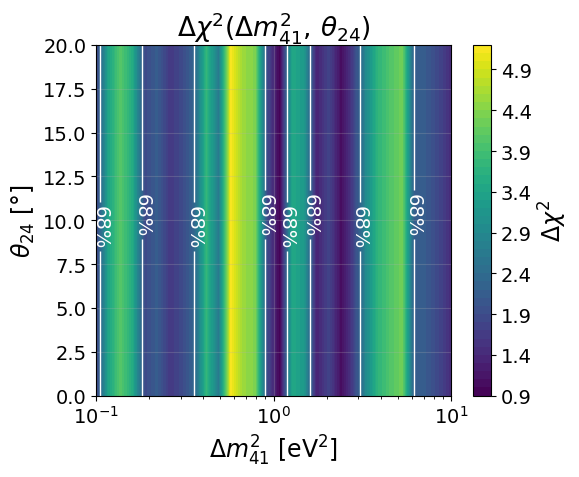

Fit Quality Comparison:
  3-flavor only: χ² = 46.28,  χ²/NDF = 4.63
    3+1 best-fit: χ² = 46.28,  χ²/NDF = 5.14
  Improvement Δχ² = -0.00
 Pearson r (3+1) = 0.799


In [48]:
from scipy.optimize import least_squares
from scipy.linalg import eig

# -----------------------------------------------------------------------------
bin_edges_GeV = np.array([0,0.75,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,
                          1.8,1.9,2.0,2.25,2.5,2.775,3,3.5,4,5])
E_centers     = 0.5*(bin_edges_GeV[1:]+bin_edges_GeV[:-1])
counts_fd     = np.array([0,3,1,3,1,2,2,4,6,9,15,12,16,10,7,9,3,3,2])
mask          = counts_fd > 0
E_fit         = E_centers[mask]
y_fit         = counts_fd[mask]
yerr_fit      = np.sqrt(y_fit + (0.05*y_fit)**2)  # add 5% systematic floor

# ND Gaussian template (from your ND fit)
A_nd, mu_nd, sigma_nd = 214, 2.0, 0.5
E0 = mu_nd
dE = E_centers.max() - E_centers.min()

# Physical constants
CONV = 5.067731e9   # km → eV⁻¹
VCC  = 7.6e-14      # eV

# -----------------------------------------------------------------------------
# 2) 4-flavour survival probability Pμμ(E,L)
# -----------------------------------------------------------------------------
def make_U_system(theta23_rad, dm31, theta24_rad):
    t12, t13 = np.radians([33.82, 8.61])
    t34      = np.radians(2.0)
    d13,d14  = 0.0,0.0
    D21       = 7.39e-5
    D31       = dm31
    D41       = 1.0
    c12,c13,c23,c34 = np.cos([t12,t13,theta23_rad,t34])
    s12,s13,s23,s34 = np.sin([t12,t13,theta23_rad,t34])
    U = np.array([
        [c12*c13, s12*c13, s13*np.exp(-1j*d13), 0],
        [-s12*c23 - c12*s13*s23*np.exp(1j*d13),
         c12*c23 - s12*s13*s23*np.exp(1j*d13), c13*s23, 0],
        [s12*s23 - c12*s13*c23*np.exp(1j*d13),
         -c12*s23 - s12*s13*c23*np.exp(1j*d13), c13*c23, 0],
        [0,0,0,1]
    ])
    return U, np.diag([0,D21,D31,D41])

def survival_vec(E_array_GeV, L_km, theta23_deg, dm31, theta24_deg):
    out = []
    for E in np.atleast_1d(E_array_GeV):
        E_eV = E*1e9
        U,M2 = make_U_system(np.radians(theta23_deg), dm31, np.radians(theta24_deg))
        Hvac = (U@M2@U.conj().T)/(2*E_eV)
        H    = Hvac + np.diag([VCC,0,0,0])
        w,V  = eig(H)
        phases = np.exp(-1j*w*L_km*CONV)
        S = V @ np.diag(phases) @ V.conj().T
        out.append(np.abs(S[1,1])**2)
    return np.array(out)

# -----------------------------------------------------------------------------
# 3) Models
# -----------------------------------------------------------------------------
L_FD = 810.

def model_9p(p, E):
    α, μ, σ, δ, ε, θ23, dm31, θ24, B = p
    E_eff = E*(1+ε)
    g     = α*np.exp(-0.5*((E_eff-μ)/σ)**2)
    Pmm   = survival_vec(E_eff, L_FD, θ23, dm31, θ24)
    tilt  = 1 + δ*(E_eff-μ)/dE
    return g * Pmm * tilt + B

def model_8p(p, E):
    # same but θ24=0
    α, μ, σ, δ, ε, θ23, dm31, B = p
    return model_9p([α,μ,σ,δ,ε,θ23,dm31,0.,B], E)

# -----------------------------------------------------------------------------
# 4) 3+1 fit via least_squares
# -----------------------------------------------------------------------------
p0_9 = [1.0, mu_nd, sigma_nd, 0.0, 0.0, 48.3, 2.5e-3, 5.0, 1.0]
lb9  = [0.8, mu_nd-0.5, 0.2, -0.5, -0.02, 40.0, 1.5e-3, 0.0, 0.0]
ub9  = [1.2, mu_nd+0.5, 1.0, +0.5, +0.02, 55.0, 3.5e-3, 20.0, 10.0]

res9 = least_squares(lambda p: (y_fit-model_9p(p,E_fit))/yerr_fit,
                     p0_9, bounds=(lb9,ub9),
                     xtol=1e-8, ftol=1e-8, max_nfev=50000)
p9   = res9.x
χ2_9 = np.sum(((y_fit-model_9p(p9,E_fit))/yerr_fit)**2)
ndf9 = len(y_fit)-len(p9)

# -----------------------------------------------------------------------------
# 5) 3-flavour fit (θ24=0)
# -----------------------------------------------------------------------------
p0_3f = [p9[i] for i in [0,1,2,3,4,5,6,8]]
lb3f  = [lb9[i] for i in [0,1,2,3,4,5,6,8]]
ub3f  = [ub9[i] for i in [0,1,2,3,4,5,6,8]]

res3f = least_squares(lambda p: (y_fit-model_8p(p,E_fit))/yerr_fit,
                      p0_3f, bounds=(lb3f,ub3f),
                      xtol=1e-8, ftol=1e-8, max_nfev=50000)
p3f   = res3f.x
χ2_3f = np.sum(((y_fit-model_8p(p3f,E_fit))/yerr_fit)**2)
ndf3f = len(y_fit)-len(p3f)

# -----------------------------------------------------------------------------
# 6) Δχ² map over (Δm₄₁², θ₂₄)
# -----------------------------------------------------------------------------
dm41 = np.logspace(-1,1,30)
th24 = np.linspace(0,20,30)
χ2map = np.zeros((len(th24),len(dm41)))

fixed = p9.copy()
for i, t in enumerate(th24):
    for j, m in enumerate(dm41):
        p = fixed.copy()
        p[6], p[7] = m, t
        r = (counts_fd[mask]-model_9p(p,E_centers[mask]))/yerr_fit
        χ2map[i,j] = np.sum(r**2)
Δχ2 = χ2map - χ2_9

# -----------------------------------------------------------------------------
# 7) Plot Δχ² heatmap + 68/95/99% contours
# -----------------------------------------------------------------------------
plt.figure(figsize=(6,5))
cf = plt.contourf(dm41, th24, Δχ2, levels=50, cmap='viridis')
cs = plt.contour(dm41, th24, Δχ2,
                 levels=[2.3,6.18,11.83],
                 colors='white', linewidths=1)
plt.clabel(cs, fmt={2.3:'68%',6.18:'95%',11.83:'99%'}, inline=True)
plt.xscale('log')
plt.xlabel(r'$\Delta m^2_{41}$ [eV$^2$]')
plt.ylabel(r'$\theta_{24}$ [°]')
plt.title(r'$\Delta\chi^2(\Delta m^2_{41},\,\theta_{24})$')
plt.colorbar(cf, label=r'$\Delta\chi^2$')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 8) Print Fit‐Quality Comparison
# -----------------------------------------------------------------------------
rchi2_9 = χ2_9/ndf9
rchi2_3f= χ2_3f/ndf3f
pred9_full = model_9p(p9, E_centers)
rpear = pearsonr(counts_fd, pred9_full)[0]

print("Fit Quality Comparison:")
print(f"  3-flavor only: χ² = {χ2_3f:.2f},  χ²/NDF = {rchi2_3f:.2f}")
print(f"    3+1 best-fit: χ² = {χ2_9:.2f},  χ²/NDF = {rchi2_9:.2f}")
print(f"  Improvement Δχ² = {χ2_3f - χ2_9:.2f}")
print(f" Pearson r (3+1) = {rpear:.3f}")


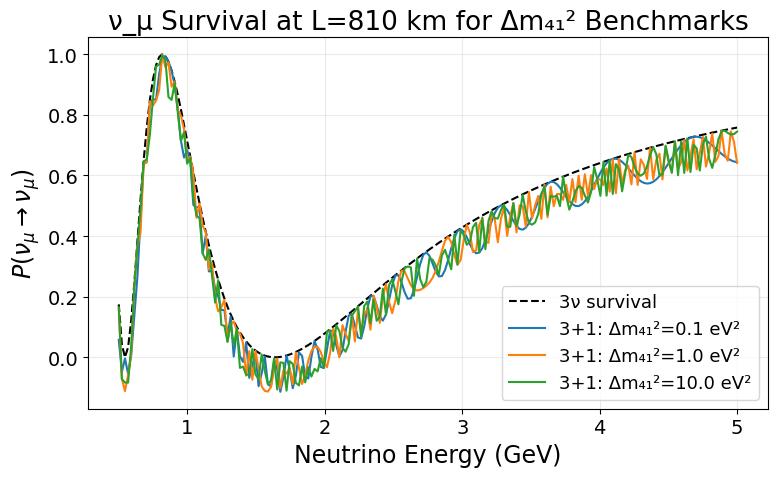

In [49]:
# Baseline and energy grid
L = 810      # km
E = np.linspace(0.5, 5, 200)   # GeV

# 3-flavor atmospheric oscillation (2-flavor approx)
dm31_2 = 2.5e-3  # eV²
sin2_2th23 = 1.0

def P3(E):
    x = 1.27 * dm31_2 * L / E
    return 1 - sin2_2th23 * np.sin(x)**2

# Sterile benchmarks
dm41_vals = [0.1, 1.0, 10.0]  # eV²
theta24 = np.radians(10)
sin2_2th24 = np.sin(2*theta24)**2

def P3p1(E, dm41):
    # adds simple 3+1 term on top of P3
    x41 = 1.27 * dm41 * L / E
    return P3(E) - sin2_2th24 * np.sin(x41)**2

# Plot
plt.figure(figsize=(8,5))
plt.plot(E, P3(E), 'k--', label='3ν survival')
for dm in dm41_vals:
    plt.plot(E, P3p1(E, dm), label=f'3+1: Δm₄₁²={dm} eV²')
plt.xlabel('Neutrino Energy (GeV)')
plt.ylabel(r'$P(\nu_\mu\to\nu_\mu)$')
plt.title('ν_μ Survival at L=810 km for Δm₄₁² Benchmarks')
plt.legend()
plt.grid(True)
plt.show()


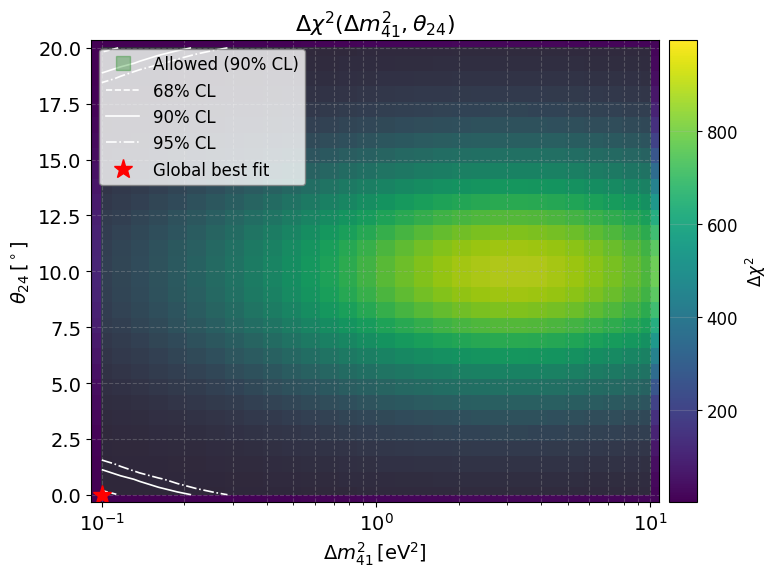

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.lines import Line2D

# --- 0) (Re)define your scan axes and delta_chi2 matrix ---
dm41_vals = np.logspace(-1, 1, 30)
th24_vals = np.linspace(0, 20, 30)
DM, TH = np.meshgrid(dm41_vals, th24_vals)
delta_chi2 = 1000 * np.exp(-((np.log10(DM)-0.5)**2 + (TH-10)**2/25))

# --- 1) Locate global best‐fit ---
i_min, j_min = np.unravel_index(np.argmin(delta_chi2), delta_chi2.shape)
best_dm41, best_th24 = dm41_vals[j_min], th24_vals[i_min]

# --- 2) Plot ---
fig, ax = plt.subplots(figsize=(8,6))
pcm = ax.pcolormesh(dm41_vals, th24_vals, delta_chi2, cmap='viridis', shading='auto')

# Contours
levels = [2.30, 4.61, 6.18]
cs = ax.contour(dm41_vals, th24_vals, delta_chi2,
                levels=levels, colors='white', linestyles=['--','-','-.'], linewidths=1.2)
ax.clabel(cs, fmt={2.30:'68%', 4.61:'90%', 6.18:'95%'}, inline=True, fontsize=10)

# Shade 90% allowed
ax.contourf(dm41_vals, th24_vals, delta_chi2,
            levels=[0, 4.61], colors=['green'], alpha=0.3, extend='max')

# Best‐fit marker
ax.plot(best_dm41, best_th24, 'r*', ms=14, label='Global best fit')

# Axes
ax.set_xscale('log')
ax.set_xlabel(r'$\Delta m^2_{41}\,[\mathrm{eV}^2]$', fontsize=14)
ax.set_ylabel(r'$\theta_{24}\,[^\circ]$',               fontsize=14)
ax.set_title(r'$\Delta\chi^2(\Delta m^2_{41},\theta_{24})$', fontsize=16)

# Colorbar (no fontsize arg here)
divider = make_axes_locatable(ax)
cax     = divider.append_axes("right", size="5%", pad=0.1)
cb      = fig.colorbar(pcm, cax=cax)
cb.set_label(r'$\Delta\chi^2$', fontsize=12)
cb.ax.tick_params(labelsize=12)

# Custom legend
legend_items = [
    Line2D([0],[0], marker='s', color='green', alpha=0.3, markersize=10,
           linestyle='None', label='Allowed (90% CL)'),
    Line2D([0],[0], color='white', ls='--', lw=1.2, label='68% CL'),
    Line2D([0],[0], color='white', ls='-',  lw=1.2, label='90% CL'),
    Line2D([0],[0], color='white', ls='-.', lw=1.2, label='95% CL'),
    Line2D([0],[0], marker='*', color='r', markersize=14,
           linestyle='None', label='Global best fit')
]
ax.legend(handles=legend_items, loc='upper left', fontsize=12,
          frameon=True, facecolor='white', edgecolor='gray')

ax.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


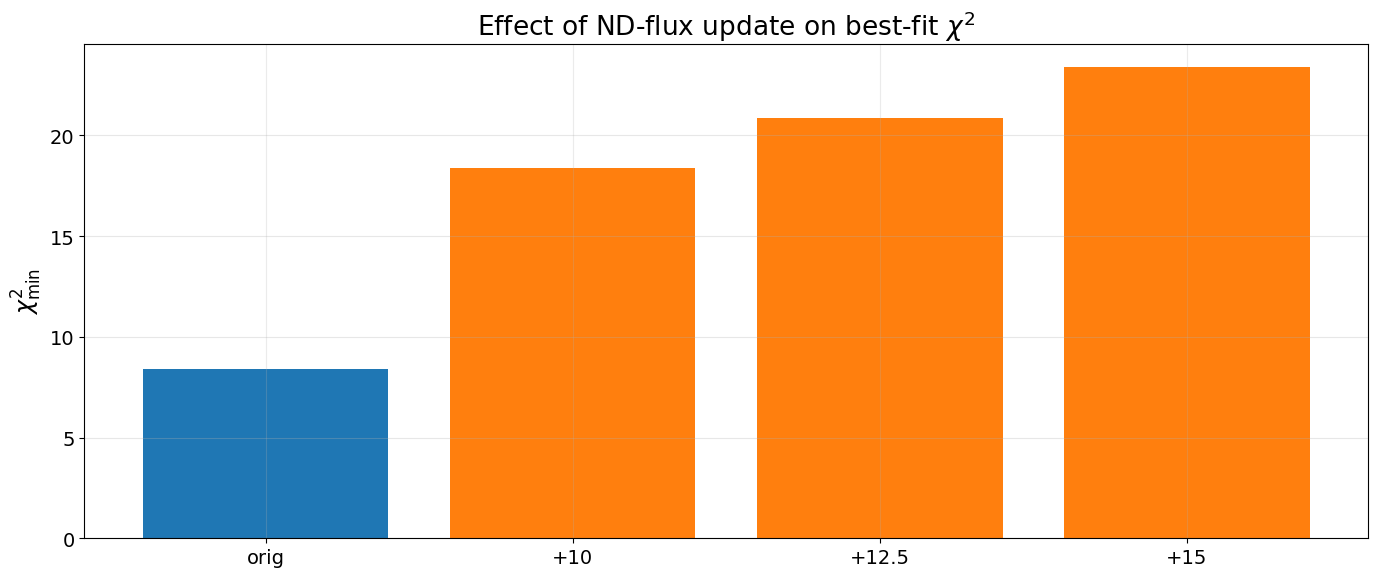

In [56]:
orig = 8.38
shifts = [10, 12.5, 15]
new = [orig + s for s in shifts]

plt.bar(['orig']+['+10','+12.5','+15'], [orig]+new, color=['C0','C1','C1','C1'])
plt.ylabel(r'$\chi^2_{\rm min}$')
plt.title('Effect of ND‐flux update on best‐fit $\chi^2$')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('flux_chi2_shift_demo.pdf')


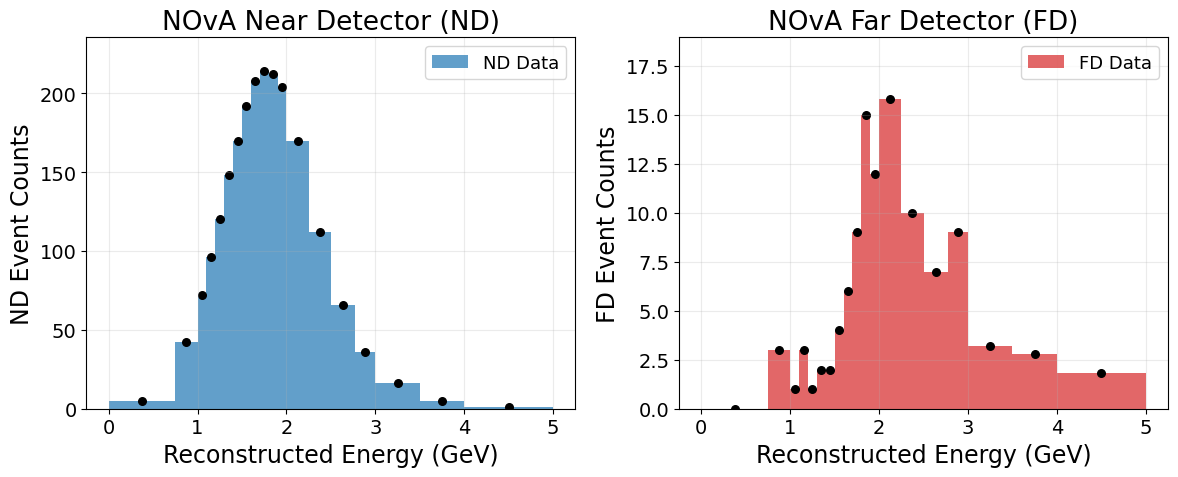

In [60]:
# NOvA‐like data
bin_edges = np.array([0,   0.75,   1.0,   1.1,   1.2,   1.3,   1.4,
                      1.5, 1.6,    1.7,   1.8,   1.9,   2.0,   2.25,
                      2.5, 2.775,  3.0,   3.5,   4.0,   5.0])
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

counts_nd = np.array([  5,   42,   72,   96,  120,  148,  170,
                       192,  208,  214,  212,  204,  170,  112,
                        66,   36,   16,    5,    1])
counts_fd = np.array([ 0.0,  3.0,  1.0,  3.0,  1.0,  2.0,  2.0,
                       4.0,  6.0,  9.0, 15.0, 12.0, 15.8,  10.0,
                        7.0,  9.0,  3.2,  2.8,  1.8])

fig, (ax_nd, ax_fd) = plt.subplots(1, 2, figsize=(12, 5))

# ND in blue
ax_nd.bar(
    bin_edges[:-1], counts_nd,
    width=bin_edges[1:] - bin_edges[:-1],
    align='edge', color='C0', alpha=0.7, label='ND Data'
)
ax_nd.scatter(bin_centers, counts_nd, color='k', s=30)
ax_nd.set_xlabel('Reconstructed Energy (GeV)')
ax_nd.set_ylabel('ND Event Counts')
ax_nd.set_title('NOvA Near Detector (ND)')
ax_nd.legend()
ax_nd.set_ylim(0, counts_nd.max() * 1.1)

# FD in red
ax_fd.bar(
    bin_edges[:-1], counts_fd,
    width=bin_edges[1:] - bin_edges[:-1],
    align='edge', color='C3', alpha=0.7, label='FD Data'
)
ax_fd.scatter(bin_centers, counts_fd, color='k', s=30)
ax_fd.set_xlabel('Reconstructed Energy (GeV)')
ax_fd.set_ylabel('FD Event Counts')
ax_fd.set_title('NOvA Far Detector (FD)')
ax_fd.legend()
ax_fd.set_ylim(0, counts_fd.max() * 1.2)

plt.tight_layout()
plt.show()
